# Memory and Forecasting Analysis (Pilot Data)

#### Importing Necessary Packages

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

### Defining global variables

In [2]:
AR_MEAN = 500
REQUIRE_COMPLETE_FORECASTS = True
FORECAST_START_INDEX = 20
EXPECTED_FORECAST_TRIALS = 60

POST_SWITCH_POSITIONS = [0, 1] # Regression (1) requires within-train positions 0 and 1
INCLUDE_PT_MAIN_EFFECT = False # Inclusion/exclusion of participant main effect in regression (2)
DISTRACTOR_ACCURACY_MIN = 0.60  # Primary analysis: exclude participants below this distractor-task accuracy
MODAL_FORECAST_SHARE_MAX = 0.80  # Primary analysis: exclude participants whose single most common forecast exceeds this share

OUTLIER_MODIFIED_Z_THRESHOLD = 3.5  # Robustness check: a forecast is a *candidate* outlier if its error's per-participant modified z-score (MAD-based) exceeds this in absolute value
REASONABLE_GUESS_TOLERANCE = 40  # ...but only actually flagged if the forecast itself also strayed this far from x_t (2x the AR(1) innovation SD) -- a candidate whose forecast stayed close to x_t just had bad luck when the series moved, not an unreasonable guess
MEAN_ABS_ERROR_MAX = 30  # Robustness check: exclude participants whose mean absolute error (on non-outlier trains) exceeds this


### Defining pilot data importation and plot exportation paths

In [3]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "Pilot_Data" / "pilot.csv"
ASSIGNMENTS_PATH = ROOT / "static" / "data" / "assignments_pilot.json"

df = pd.read_csv(DATA_PATH, low_memory=False)

with open(ASSIGNMENTS_PATH, "r", encoding="utf-8") as f:
    assignments = json.load(f)

if isinstance(assignments, dict) and "assignments" in assignments:
    assignments = assignments["assignments"]
    
print("Rows in exported data:", len(df))
print("Assignments:", len(assignments))

OUT_DIR = ROOT / "analysis_outputs" / "pilot_participant_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = OUT_DIR / "pilot_n40_results_tables.pdf"

Rows in exported data: 15350
Assignments: 40


### Formatting table for regression results

In [4]:
def add_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def format_result_table(df, round_digits=4):
    out = df.copy()

    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].round(round_digits)
    return out

### Extract assignments and unique ids

In [5]:
# Participant/session column
if "db_uniqueid" in df.columns:
    participant_col = "db_uniqueid"
elif "uniqueId" in df.columns:
    participant_col = "uniqueId"
else:
    raise ValueError("Could not find participant id column.")

# Assignment column
if "assignment_slot" in df.columns:
    assignment_col = "assignment_slot"
elif "counterbalance" in df.columns:
    assignment_col = "counterbalance"
else:
    raise ValueError("Could not find assignment_slot or counterbalance column.")

participant_col, assignment_col

('db_uniqueid', 'assignment_slot')

### Extract strictly necessary data from assignments with complete data

In [6]:
def get_assignment_rho(assignment):
    if "rho" in assignment:
        return assignment["rho"]
    if "ar1" in assignment and "rho" in assignment["ar1"]:
        return assignment["ar1"]["rho"]
    raise ValueError("Could not find rho in assignment.")


def ols_slope(y_values, x_values):
    """Slope of an OLS regression of y on x with an intercept."""
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)

    x_centered = x - x.mean()
    denominator = (x_centered ** 2).sum()

    if denominator == 0:
        return np.nan

    return float((x_centered * (y - y.mean())).sum() / denominator)


def get_realized_rho(assignment, forecast_start_index=FORECAST_START_INDEX):
    """Sample AR(1) coefficient of the series this participant actually saw.

    The nominal rho is not the persistence a participant was exposed to. A
    single 80-point draw has a sample rho that scatters (SD ~0.10) and sits
    below nominal by roughly (1 + 3*rho)/T, which is ~0.06 here. Benchmarking
    forecasts against the nominal value therefore charges participants for a
    gap that is a property of the stimulus, not of their behaviour.

    Stimuli from experiment_code_version 3.0.0 onward are conditioned to remove
    this and store the value. Older files (assignments_v1.json, the psiTurk
    pilot) predate the field, so it is recomputed here instead -- which means
    this works against either stimulus file.

    Measured over the forecast rounds, matching the regression below:
    forecasting on round i, the participant has just seen values[i - 1].
    """
    stored = assignment.get("ar1", {}).get("realized_rho_forecast_window")
    if stored is not None:
        return float(stored)

    values = assignment["ar1"]["values"]
    x_values = values[forecast_start_index - 1:len(values) - 1]
    y_values = values[forecast_start_index:]

    return ols_slope(y_values, x_values)


def build_assignment_design(assignments):
    rows = []

    for assignment_index, assignment in enumerate(assignments):
        assignment_slot = assignment.get("slot", assignment.get("assignment_slot", assignment_index))

        values = assignment["ar1"]["values"]
        tasks = assignment["distraction"]["tasks"]
        assigned_rho = get_assignment_rho(assignment)
        realized_rho = get_realized_rho(assignment)

        train_id = -1
        last_task_type = None

        for round_index, task in enumerate(tasks):
            task_type = task["task_type"]

            if task_type != last_task_type:
                train_id += 1
                last_task_type = task_type

            rows.append({
                "assignment_slot": int(assignment_slot),
                "round_index": int(round_index),
                "task_type": task_type,
                "train_id": int(train_id),
                "assigned_rho": float(assigned_rho),

                # Persistence of this particular series, which is what the
                # participant could actually have learned from.
                "realized_rho": float(realized_rho),

                # The AR value revealed on this round.
                "x_next_true": values[round_index],

                # For a forecast on round i, the participant has just seen values[i - 1].
                "x_t": values[round_index - 1] if round_index >= 1 else np.nan,
                "x_t_minus_1": values[round_index - 2] if round_index >= 2 else np.nan,
                "x_t_minus_2": values[round_index - 3] if round_index >= 3 else np.nan,
            })

    design = pd.DataFrame(rows)

    # Train boundaries and train means.
    train_info = (
        design
        .groupby(["assignment_slot", "train_id", "task_type"], as_index=False)
        .agg(
            x_train_mean=("x_next_true", "mean"),
            train_start_round=("round_index", "min"),
            train_end_round=("round_index", "max"),
            train_length=("round_index", "count"),
        )
    )

    # Previous same-task train mean.
    train_info = train_info.sort_values(
        ["assignment_slot", "task_type", "train_start_round"]
    )

    train_info["x_match"] = (
        train_info
        .groupby(["assignment_slot", "task_type"])["x_train_mean"]
        .shift(1)
    )

    train_info["matched_train_id"] = (
        train_info
        .groupby(["assignment_slot", "task_type"])["train_id"]
        .shift(1)
    )

    design = design.merge(
        train_info[
            [
                "assignment_slot",
                "train_id",
                "x_train_mean",
                "x_match",
                "matched_train_id",
                "train_start_round",
                "train_end_round",
                "train_length",
            ]
        ],
        on=["assignment_slot", "train_id"],
        how="left"
    )

    # p_t: within-train position, 0 at the switch.
    design["p_t"] = design["round_index"] - design["train_start_round"]

    return design


assignment_design = build_assignment_design(assignments)

# How far the stimuli actually sit from their nominal persistence. Near zero
# for conditioned stimuli; ~-0.06 with wide scatter for the older files.
_rho_check = (
    assignment_design
    .groupby("assigned_rho")["realized_rho"]
    .agg(["mean", "std", "min", "max"])
)
print("Realized rho by nominal rho:")
print(_rho_check.round(4))

assignment_design.head()

Realized rho by nominal rho:
                mean     std     min     max
assigned_rho                                
0.6           0.6004  0.0056  0.5908  0.6078
0.7           0.7001  0.0056  0.6910  0.7100


,assignment_slot,round_index,task_type,train_id,assigned_rho,realized_rho,x_next_true,x_t,x_t_minus_1,x_t_minus_2,x_train_mean,x_match,matched_train_id,train_start_round,train_end_round,train_length,p_t
0,0,0,animacy,0,0.7,0.693657,500,NaN,NaN,NaN,485.75,NaN,NaN,0,3,4,0
1,0,1,animacy,0,0.7,0.693657,479,500.0,NaN,NaN,485.75,NaN,NaN,0,3,4,1
2,0,2,animacy,0,0.7,0.693657,468,479.0,500.0,NaN,485.75,NaN,NaN,0,3,4,2
3,0,3,animacy,0,0.7,0.693657,496,468.0,479.0,500.0,485.75,NaN,NaN,0,3,4,3
4,0,4,size,1,0.7,0.693657,486,496.0,468.0,479.0,490.50,NaN,NaN,4,9,6,0


### Clean up data and create dataframe for analysis

In [7]:
forecast_rows = df[df["phase"] == "forecast"].copy()

forecast_rows["round_index"] = pd.to_numeric(
    forecast_rows["round_index"], errors="coerce"
)

forecast_rows["forecast_value"] = pd.to_numeric(
    forecast_rows["forecast_value"], errors="coerce"
)

forecast_rows[assignment_col] = pd.to_numeric(
    forecast_rows[assignment_col], errors="coerce"
)

forecast_rows = forecast_rows.dropna(
    subset=[participant_col, assignment_col, "round_index", "forecast_value"]
).copy()

forecast_rows["assignment_slot"] = forecast_rows[assignment_col].astype(int)
forecast_rows["round_index"] = forecast_rows["round_index"].astype(int)

forecast_small = forecast_rows[
    [
        participant_col,
        "assignment_slot",
        "round_index",
        "forecast_value",
    ]
].copy()

# Avoid duplicate forecast rows if repeated debug runs created duplicates.
forecast_small = (
    forecast_small
    .sort_values([participant_col, "assignment_slot", "round_index"])
    .drop_duplicates(
        subset=[participant_col, "assignment_slot", "round_index"],
        keep="last"
    )
)

analysis_df = forecast_small.merge(
    assignment_design,
    on=["assignment_slot", "round_index"],
    how="left"
)

analysis_df["rho_group"] = analysis_df["assigned_rho"].round(1)

analysis_df[
    [
        participant_col,
        "assignment_slot",
        "round_index",
        "rho_group",
        "task_type",
        "train_id",
        "p_t",
        "forecast_value",
        "x_t",
        "x_t_minus_1",
        "x_t_minus_2",
        "x_match",
    ]
].head(5)

,db_uniqueid,assignment_slot,round_index,rho_group,task_type,train_id,p_t,forecast_value,x_t,x_t_minus_1,x_t_minus_2,x_match
0,5ced49fa,13,20,0.7,animacy,4,4,485.0,434.0,445.0,499.0,518.0
1,5ced49fa,13,21,0.7,size,5,0,455.0,470.0,434.0,445.0,514.0
2,5ced49fa,13,22,0.7,size,5,1,496.0,489.0,470.0,434.0,514.0
3,5ced49fa,13,23,0.7,size,5,2,528.0,515.0,489.0,470.0,514.0
4,5ced49fa,13,24,0.7,animacy,6,0,476.0,463.0,515.0,489.0,472.0


### Participant-level quality checks (primary-analysis exclusions)

In [8]:
def get_distractor_accuracy(df, participant_col, root=None):
    """
    Proportion of distractor (animacy/size) judgments matching the wordpool's
    ground truth, excluding words marked "ambiguous" (no definitive answer).
    """
    if root is None:
        root = ROOT

    wordpool_path = root / "static" / "data" / "wordpool_categories.csv"

    required_cols = {"phase", "word", "task_type", "distractor_response"}
    if not wordpool_path.exists() or not required_cols.issubset(df.columns):
        return pd.DataFrame({participant_col: [], "distractor_accuracy": []})

    wordpool = pd.read_csv(wordpool_path)

    distractor_rows = df[df["phase"] == "distractor_question"].copy()

    if "distractor_answered" in distractor_rows.columns:
        distractor_rows = distractor_rows[distractor_rows["distractor_answered"] == True]

    distractor_rows = distractor_rows.merge(wordpool, on="word", how="left")

    distractor_rows["ground_truth"] = np.where(
        distractor_rows["task_type"] == "animacy",
        distractor_rows["is_living"],
        distractor_rows["fits_shoebox"],
    )

    # Exclude words without a definitive right answer.
    distractor_rows = distractor_rows[distractor_rows["ground_truth"] != "ambiguous"]

    distractor_rows = distractor_rows.dropna(
        subset=[participant_col, "ground_truth", "distractor_response"]
    )

    distractor_rows["is_correct"] = (
        distractor_rows["distractor_response"] == distractor_rows["ground_truth"]
    )

    accuracy = (
        distractor_rows
        .groupby(participant_col, as_index=False)
        .agg(distractor_accuracy=("is_correct", "mean"))
    )

    return accuracy


def get_modal_forecast_share(analysis_df, participant_col):
    """
    Share of a participant's forecasts equal to their single most common value.
    A high share suggests the participant was not engaging with the task
    (e.g. entering the same number every round) rather than forecasting.
    """
    def _share(s):
        counts = s.value_counts()
        return counts.iloc[0] / len(s) if len(s) else np.nan

    return (
        analysis_df
        .dropna(subset=[participant_col, "forecast_value"])
        .groupby(participant_col)["forecast_value"]
        .apply(_share)
        .reset_index(name="modal_forecast_share")
    )


participant_trial_counts = (
    analysis_df
    .dropna(subset=[participant_col])
    .groupby(participant_col)
    .size()
    .reset_index(name="n_forecast_trials")
)

participant_quality = (
    participant_trial_counts
    .merge(get_distractor_accuracy(df, participant_col), on=participant_col, how="left")
    .merge(get_modal_forecast_share(analysis_df, participant_col), on=participant_col, how="left")
)

participant_quality["has_complete_data"] = (
    participant_quality["n_forecast_trials"] == EXPECTED_FORECAST_TRIALS
)

participant_quality["low_distractor_accuracy"] = (
    participant_quality["distractor_accuracy"] < DISTRACTOR_ACCURACY_MIN
)

participant_quality["high_modal_forecast_share"] = (
    participant_quality["modal_forecast_share"] > MODAL_FORECAST_SHARE_MAX
)

participant_quality["excluded_primary"] = (
    (~participant_quality["has_complete_data"])
    | participant_quality["low_distractor_accuracy"].fillna(False)
    | participant_quality["high_modal_forecast_share"].fillna(False)
)

excluded_primary_participants = set(
    participant_quality.loc[participant_quality["excluded_primary"], participant_col]
)

print(f"Participants with any forecast data: {len(participant_quality)}")
print(f"  incomplete data (!= {EXPECTED_FORECAST_TRIALS} forecast trials): {(~participant_quality['has_complete_data']).sum()}")
print(f"  distractor accuracy < {DISTRACTOR_ACCURACY_MIN:.0%}: {int(participant_quality['low_distractor_accuracy'].sum())}")
print(f"  modal forecast share > {MODAL_FORECAST_SHARE_MAX:.0%}: {int(participant_quality['high_modal_forecast_share'].sum())}")
print(f"  excluded overall: {len(excluded_primary_participants)}")
print(f"  remaining for primary analysis: {participant_quality[participant_col].nunique() - len(excluded_primary_participants)}")

analysis_df_primary = analysis_df[
    ~analysis_df[participant_col].isin(excluded_primary_participants)
].copy()

participant_quality.head()

Participants with any forecast data: 40
  incomplete data (!= 60 forecast trials): 2
  distractor accuracy < 60%: 1
  modal forecast share > 80%: 0
  excluded overall: 3
  remaining for primary analysis: 37


,db_uniqueid,n_forecast_trials,distractor_accuracy,modal_forecast_share,has_complete_data,low_distractor_accuracy,high_modal_forecast_share,excluded_primary
0,5ced49fa,60,0.966805,0.066667,True,False,False,False
1,e0e9a877,3,0.950820,0.666667,False,False,False,True
2,404f499c,60,0.901961,0.166667,True,False,False,False
3,bac610f2,60,0.857143,0.183333,True,False,False,False
4,b80c5bf6,60,0.809302,0.133333,True,False,False,False


#### QC case study: longest-duration participant

One participant's session lasted 76 minutes -- by far the longest in the pilot (mean is ~21 minutes, next-longest is ~28). That duration alone made them worth checking individually: was this a distracted/afk session that happened to finish before the 90-minute abandonment cutoff, or a genuine (if slow) completion? Their per-participant quality metrics, computed the same way as everyone else's, answer that directly below.

In [9]:
# Prolific PID <redacted>, slot 21, flagged for having the
# longest session (76.1 min) of any participant in the pilot.
qc_case_study_uid = "<redacted>8e358084"

_case_row = participant_quality[participant_quality[participant_col] == qc_case_study_uid].iloc[0]

_case_time = df.loc[
    df[participant_col] == qc_case_study_uid, ["db_begin_time", "db_end_time"]
].drop_duplicates().iloc[0]

_case_duration_min = (
    pd.to_datetime(_case_time["db_end_time"]) - pd.to_datetime(_case_time["db_begin_time"])
).total_seconds() / 60

_case_forecasts = analysis_df_primary[analysis_df_primary[participant_col] == qc_case_study_uid]
_case_mae = (_case_forecasts["forecast_value"] - _case_forecasts["x_next_true"]).abs().mean()

print(f"Participant {qc_case_study_uid} (Prolific PID <redacted>, slot 21)")
print(f"  completion time: {_case_duration_min:.1f} min (pilot mean ~21 min; longest session in the pilot)")
print(f"  forecast trials: {int(_case_row['n_forecast_trials'])} / {EXPECTED_FORECAST_TRIALS}")
print(f"  distractor accuracy: {_case_row['distractor_accuracy']:.0%} (primary-analysis floor: {DISTRACTOR_ACCURACY_MIN:.0%})")
print(f"  modal forecast share: {_case_row['modal_forecast_share']:.0%} (primary-analysis ceiling: {MODAL_FORECAST_SHARE_MAX:.0%})")
print(f"  mean abs forecast error: {_case_mae:.1f} (robustness-check ceiling: {MEAN_ABS_ERROR_MAX})")
print(f"  excluded from primary analysis: {bool(_case_row['excluded_primary'])}")
print()
print("Despite the unusually long session, this participant's data clears every")
print("quality threshold and is retained in both the primary analysis and the")
print("robustness check.")

Participant <redacted>8e358084 (Prolific PID <redacted>, slot 21)
  completion time: 76.1 min (pilot mean ~21 min; longest session in the pilot)
  forecast trials: 60 / 60
  distractor accuracy: 91% (primary-analysis floor: 60%)
  modal forecast share: 10% (primary-analysis ceiling: 80%)
  mean abs forecast error: 19.5 (robustness-check ceiling: 30)
  excluded from primary analysis: False

Despite the unusually long session, this participant's data clears every
quality threshold and is retained in both the primary analysis and the
robustness check.


### Calculate persistence implied by participant forecasts

In [10]:
def compute_participant_persistence(base_df, participant_col, require_exact_trial_count=True):
    """
    Participant-level implied persistence (OLS slope of forecast on x_t).

    require_exact_trial_count=True matches the primary analysis: a participant
    must have exactly EXPECTED_FORECAST_TRIALS forecast rows in `base_df`.
    Set to False for the robustness check, where whole trains have already
    been removed from `base_df` and an exact count is no longer meaningful.
    """
    persistence_df = base_df.dropna(
        subset=[
            participant_col,
            "rho_group",
            "forecast_value",
            "x_t",
        ]
    ).copy()

    persistence_df["forecast_c"] = persistence_df["forecast_value"] - AR_MEAN
    persistence_df["x_t_c"] = persistence_df["x_t"] - AR_MEAN

    rows = []

    for participant_id, g in persistence_df.groupby(participant_col):
        g = g.copy()

        if require_exact_trial_count and REQUIRE_COMPLETE_FORECASTS and len(g) != EXPECTED_FORECAST_TRIALS:
            continue

        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue

        rho_value = rho_values[0]

        realized_rho_values = g["realized_rho"].dropna().unique()
        if len(realized_rho_values) != 1:
            continue

        realized_rho = realized_rho_values[0]

        if len(g) < 5:
            continue

        if g["x_t_c"].nunique() < 2:
            continue

        try:
            res = smf.ols(
                "forecast_c ~ x_t_c",
                data=g
            ).fit()

            implied_rho = res.params.get("x_t_c", np.nan)

            rows.append({
                "participant": participant_id,
                "assigned_rho": rho_value,
                "realized_rho": realized_rho,
                "implied_rho": implied_rho,

                # Overreaction is implied persistence in excess of the persistence
                # actually present in the series the participant saw. Benchmarking
                # against the nominal rho instead would score a participant who
                # learned their own series perfectly as under-reacting, purely
                # because of small-sample bias in the stimulus.
                "rho_excess": implied_rho - realized_rho,

                # The previous nominal-rho benchmark, kept so the two can be
                # compared and reported side by side.
                "rho_excess_vs_nominal": implied_rho - rho_value,

                "n_obs": int(res.nobs),
                "r_squared": res.rsquared,
            })

        except Exception as e:
            print(f"Could not estimate persistence for participant {participant_id}: {e}")

    return pd.DataFrame(rows)


participant_persistence = compute_participant_persistence(analysis_df_primary, participant_col)

participant_persistence.head()

,participant,assigned_rho,realized_rho,implied_rho,rho_excess,rho_excess_vs_nominal,n_obs,r_squared
0,5ced49fa,0.7,0.709796,0.690532,-0.019264,-0.009468,60,0.595267
1,404f499c,0.7,0.690975,0.676207,-0.014768,-0.023793,60,0.719038
2,bac610f2,0.6,0.597849,0.731533,0.133684,0.131533,60,0.493865
3,b80c5bf6,0.6,0.597849,0.244320,-0.353529,-0.355680,60,0.005094
4,6bc8310e,0.6,0.603302,1.073803,0.470501,0.473803,60,0.956831


### Test for baseline overreaction

In [11]:
def test_baseline_overreaction(participant_persistence_df):
    rows = []

    for rho_value, g in participant_persistence_df.groupby("assigned_rho"):
        excess = g["rho_excess"].dropna()
        excess_vs_nominal = g["rho_excess_vs_nominal"].dropna()

        test = stats.ttest_1samp(
            excess,
            popmean=0,
            alternative="greater"
        )

        # Same test against the nominal rho, so the effect of the benchmark is
        # visible rather than buried in a choice made upstream.
        test_vs_nominal = stats.ttest_1samp(
            excess_vs_nominal,
            popmean=0,
            alternative="greater"
        )

        rows.append({
            "assigned_rho": rho_value,
            "n_participants": len(excess),
            "mean_realized_rho": g["realized_rho"].mean(),
            "mean_implied_rho": g["implied_rho"].mean(),
            "median_implied_rho": g["implied_rho"].median(),
            "mean_rho_excess": excess.mean(),
            "median_rho_excess": excess.median(),
            "sd_rho_excess": excess.std(ddof=1),
            "t_stat": test.statistic,
            "p_value_implied_rho_greater_than_true_rho": test.pvalue,

            "mean_rho_excess_vs_nominal": excess_vs_nominal.mean(),
            "t_stat_vs_nominal": test_vs_nominal.statistic,
            "p_value_vs_nominal": test_vs_nominal.pvalue,
        })

    return pd.DataFrame(rows)


persistence_tests = test_baseline_overreaction(participant_persistence)

persistence_tests

,assigned_rho,n_participants,mean_realized_rho,mean_implied_rho,median_implied_rho,mean_rho_excess,median_rho_excess,sd_rho_excess,t_stat,p_value_implied_rho_greater_than_true_rho,mean_rho_excess_vs_nominal,t_stat_vs_nominal,p_value_vs_nominal
0,0.6,20,0.599515,0.715168,0.752198,0.115653,0.148671,0.435247,1.188325,0.124674,0.115168,1.180002,0.126281
1,0.7,17,0.699348,0.682987,0.667747,-0.016361,-0.023228,0.523857,-0.128774,0.550429,-0.017013,-0.134376,0.552609


### Prep data for regressions

In [12]:
def prepare_regression_df(analysis_df):
    out = analysis_df.dropna(
        subset=[
            participant_col,
            "rho_group",
            "forecast_value",
            "x_t",
            "x_t_minus_1",
            "x_match",
            "p_t",
        ]
    ).copy()

    out["forecast_c"] = out["forecast_value"] - AR_MEAN
    out["x_t_c"] = out["x_t"] - AR_MEAN
    out["x_t_minus_1_c"] = out["x_t_minus_1"] - AR_MEAN
    out["x_t_minus_2_c"] = out["x_t_minus_2"] - AR_MEAN
    out["x_match_c"] = out["x_match"] - AR_MEAN

    out["p_t"] = pd.to_numeric(out["p_t"], errors="coerce")
    out["p_t_x_match_c"] = out["p_t"] * out["x_match_c"]

    return out


reg_df = prepare_regression_df(analysis_df_primary)

reg_df[
    [
        participant_col,
        "rho_group",
        "round_index",
        "task_type",
        "train_id",
        "p_t",
        "forecast_c",
        "x_t_c",
        "x_t_minus_1_c",
        "x_t_minus_2_c",
        "x_match_c",
        "p_t_x_match_c",
    ]
].head()

,db_uniqueid,rho_group,round_index,task_type,train_id,p_t,forecast_c,x_t_c,x_t_minus_1_c,x_t_minus_2_c,x_match_c,p_t_x_match_c
0,5ced49fa,0.7,20,animacy,4,4,-15.0,-66.0,-55.0,-1.0,18.0,72.0
1,5ced49fa,0.7,21,size,5,0,-45.0,-30.0,-66.0,-55.0,14.0,0.0
2,5ced49fa,0.7,22,size,5,1,-4.0,-11.0,-30.0,-66.0,14.0,14.0
3,5ced49fa,0.7,23,size,5,2,28.0,15.0,-11.0,-30.0,14.0,28.0
4,5ced49fa,0.7,24,animacy,6,0,-24.0,-37.0,15.0,-11.0,-28.0,-0.0


### Post-switch forecast bias regression

In [13]:
def participant_level_simple_gamma_postswitch(reg_df, lag_spec, post_switch_positions=[0, 1]):
    """
    Estimate participant-level gamma using only post-switch trials.

    post_switch_positions = [0, 1] means:
        p_t = 0: first trial after the task switch
        p_t = 1: second trial after the task switch

    lag_spec = 2:
        forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c

    lag_spec = 3:
        forecast_c ~ x_t_c + x_t_minus_1_c + x_t_minus_2_c + x_match_c
    """

    if lag_spec == 2:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_match_c",
            "p_t",
        ]

        formula = "forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c"

    elif lag_spec == 3:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
            "x_match_c",
            "p_t",
        ]

        formula = "forecast_c ~ x_t_c + x_t_minus_1_c + x_t_minus_2_c + x_match_c"

    else:
        raise ValueError("lag_spec must be 2 or 3.")

    rows = []

    # Keep only post-switch positions
    temp = reg_df.copy()
    temp = temp[temp["p_t"].isin(post_switch_positions)].copy()
    temp = temp.dropna(subset=needed).copy()

    for participant_id, g in temp.groupby(participant_col):
        g = g.copy()

        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue

        rho_value = rho_values[0]

        # Fewer observations now because we only use p_t = 0 and p_t = 1
        if len(g) < 8:
            continue

        if g["x_match_c"].nunique() < 2:
            continue

        try:
            res = smf.ols(formula, data=g).fit()

            rows.append({
                "participant": participant_id,
                "assigned_rho": rho_value,
                "lag_spec": lag_spec,
                "post_switch_positions": str(post_switch_positions),
                "gamma": res.params.get("x_match_c", np.nan),
                "gamma_se": res.bse.get("x_match_c", np.nan),
                "n_obs": int(res.nobs),
                "r_squared": res.rsquared,
                "formula": formula,
            })

        except Exception as e:
            print(
                f"Could not estimate post-switch gamma for participant "
                f"{participant_id}, lag_spec={lag_spec}: {e}"
            )

    return pd.DataFrame(rows)

In [14]:
simple_gamma_postswitch_2 = participant_level_simple_gamma_postswitch(
    reg_df,
    lag_spec=2,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gamma_postswitch_3 = participant_level_simple_gamma_postswitch(
    reg_df,
    lag_spec=3,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gammas_postswitch = pd.concat(
    [simple_gamma_postswitch_2, simple_gamma_postswitch_3],
    ignore_index=True
)

simple_gammas_postswitch.head()


def test_postswitch_gamma_greater_than_zero(simple_gammas_postswitch):
    rows = []

    for (rho_value, lag_spec), g in simple_gammas_postswitch.groupby(["assigned_rho", "lag_spec"]):
        gamma_values = g["gamma"].dropna()

        test = stats.ttest_1samp(
            gamma_values,
            popmean=0,
            alternative="greater"
        )

        rows.append({
            "assigned_rho": rho_value,
            "lag_spec": lag_spec,
            "post_switch_positions": str(POST_SWITCH_POSITIONS),
            "n_participants": len(gamma_values),
            "mean_gamma": gamma_values.mean(),
            "median_gamma": gamma_values.median(),
            "sd_gamma": gamma_values.std(ddof=1),
            "t_stat": test.statistic,
            "p_value_gamma_greater_than_0": test.pvalue,
        })

    return pd.DataFrame(rows)


simple_gamma_postswitch_tests = test_postswitch_gamma_greater_than_zero(simple_gammas_postswitch)

In [15]:
def test_gamma_condition_comparison(simple_gammas_postswitch):
    rows = []

    for lag_spec, g in simple_gammas_postswitch.groupby("lag_spec"):
        gamma_06 = g[g["assigned_rho"].round(1) == 0.6]["gamma"].dropna()
        gamma_07 = g[g["assigned_rho"].round(1) == 0.7]["gamma"].dropna()

        test = stats.ttest_ind(
            gamma_07,
            gamma_06,
            equal_var=False,
            alternative="greater"
        )

        rows.append({
            "lag_spec": lag_spec,
            "post_switch_positions": str(POST_SWITCH_POSITIONS),
            "n_rho_06": len(gamma_06),
            "n_rho_07": len(gamma_07),
            "mean_gamma_rho_06": gamma_06.mean(),
            "mean_gamma_rho_07": gamma_07.mean(),
            "difference_07_minus_06": gamma_07.mean() - gamma_06.mean(),
            "sd_gamma_rho_06": gamma_06.std(ddof=1),
            "sd_gamma_rho_07": gamma_07.std(ddof=1),
            "welch_t_stat": test.statistic,
            "p_value_rho_07_greater_than_rho_06": test.pvalue,
        })

    return pd.DataFrame(rows)


gamma_condition_postswitch_tests = test_gamma_condition_comparison(simple_gammas_postswitch)

In [16]:
print("Post-switch x_match gamma > 0 tests, using only p_t = 0 and p_t = 1")
display(simple_gamma_postswitch_tests)

print("Post-switch gamma comparison: rho 0.7 > rho 0.6")
display(gamma_condition_postswitch_tests)

Post-switch x_match gamma > 0 tests, using only p_t = 0 and p_t = 1


,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,sd_gamma,t_stat,p_value_gamma_greater_than_0
0,0.6,2,"[0, 1]",20,0.152901,0.074276,0.470380,1.453706,0.081173
1,0.6,3,"[0, 1]",20,0.180490,0.126811,0.497571,1.622229,0.060615
2,0.7,2,"[0, 1]",17,0.691350,0.131207,2.783561,1.024051,0.160523
3,0.7,3,"[0, 1]",17,0.706683,0.029069,2.814946,1.035093,0.158009


Post-switch gamma comparison: rho 0.7 > rho 0.6


,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,sd_gamma_rho_06,sd_gamma_rho_07,welch_t_stat,p_value_rho_07_greater_than_rho_06
0,2,"[0, 1]",20,17,0.152901,0.691350,0.538449,0.470380,2.783561,0.788062,0.220827
1,3,"[0, 1]",20,17,0.180490,0.706683,0.526194,0.497571,2.814946,0.760691,0.228677


### Reinstatement decay across train position regression

In [17]:
def participant_level_interaction_gammas(reg_df, lag_spec, include_pt_main_effect=False):
    """
    lag_spec = 2:
        controls x_t and x_t_minus_1

    lag_spec = 3:
        controls x_t, x_t_minus_1, and x_t_minus_2

    include_pt_main_effect=False matches written equation.
    include_pt_main_effect=True controls for average within-train drift (just in case).
    """
    if lag_spec == 2:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_match_c",
            "p_t",
            "p_t_x_match_c",
        ]

        predictors = [
            "x_t_c",
            "x_t_minus_1_c",
        ]

    elif lag_spec == 3:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
            "x_match_c",
            "p_t",
            "p_t_x_match_c",
        ]

        predictors = [
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
        ]

    else:
        raise ValueError("lag_spec must be 2 or 3.")

    if include_pt_main_effect:
        predictors = predictors + ["p_t"]

    predictors = predictors + ["x_match_c", "p_t_x_match_c"]

    formula = "forecast_c ~ " + " + ".join(predictors)

    rows = []

    for participant_id, g in reg_df.dropna(subset=needed).groupby(participant_col):
        g = g.copy()

        if REQUIRE_COMPLETE_FORECASTS and len(g) < 40:
            continue

        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue

        rho_value = rho_values[0]

        if len(g) < len(predictors) + 3:
            continue

        if g["x_match_c"].nunique() < 2:
            continue

        if g["p_t_x_match_c"].nunique() < 2:
            continue

        try:
            res = smf.ols(formula, data=g).fit()

            rows.append({
                "participant": participant_id,
                "assigned_rho": rho_value,
                "lag_spec": lag_spec,
                "include_pt_main_effect": include_pt_main_effect,
                "gamma_0": res.params.get("x_match_c", np.nan),
                "gamma_1": res.params.get("p_t_x_match_c", np.nan),
                "gamma_0_se": res.bse.get("x_match_c", np.nan),
                "gamma_1_se": res.bse.get("p_t_x_match_c", np.nan),
                "n_obs": int(res.nobs),
                "r_squared": res.rsquared,
                "formula": formula,
            })

        except Exception as e:
            print(
                f"Could not estimate interaction gammas for participant "
                f"{participant_id}, lag_spec={lag_spec}: {e}"
            )

    return pd.DataFrame(rows)

In [18]:
interaction_gamma_2 = participant_level_interaction_gammas(
    reg_df,
    lag_spec=2,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gamma_3 = participant_level_interaction_gammas(
    reg_df,
    lag_spec=3,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gammas = pd.concat(
    [interaction_gamma_2, interaction_gamma_3],
    ignore_index=True
)

interaction_gammas.head()

,participant,assigned_rho,lag_spec,include_pt_main_effect,gamma_0,gamma_1,gamma_0_se,gamma_1_se,n_obs,r_squared,formula
0,5ced49fa,0.7,2,False,0.094098,0.060376,0.127622,0.049545,60,0.685532,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
1,404f499c,0.7,2,False,0.190926,-0.056412,0.131676,0.055397,60,0.730020,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
2,bac610f2,0.6,2,False,0.487407,0.017362,0.217283,0.093758,60,0.589942,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
3,b80c5bf6,0.6,2,False,-1.897295,0.208096,1.055855,0.455604,60,0.104647,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
4,6bc8310e,0.6,2,False,0.020281,0.008978,0.066136,0.025004,60,0.958099,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...


In [19]:
def test_interaction_gammas(interaction_gammas):
    rows = []

    for (rho_value, lag_spec), g in interaction_gammas.groupby(["assigned_rho", "lag_spec"]):
        gamma_0_values = g["gamma_0"].dropna()
        gamma_1_values = g["gamma_1"].dropna()

        gamma_0_test = stats.ttest_1samp(
            gamma_0_values,
            popmean=0,
            alternative="greater"
        )

        gamma_1_test = stats.ttest_1samp(
            gamma_1_values,
            popmean=0,
            alternative="less"
        )

        rows.append({
            "assigned_rho": rho_value,
            "lag_spec": lag_spec,

            "n_participants_gamma_0": len(gamma_0_values),
            "mean_gamma_0": gamma_0_values.mean(),
            "median_gamma_0": gamma_0_values.median(),
            "sd_gamma_0": gamma_0_values.std(ddof=1),
            "t_gamma_0": gamma_0_test.statistic,
            "p_value_gamma_0_greater_than_0": gamma_0_test.pvalue,

            "n_participants_gamma_1": len(gamma_1_values),
            "mean_gamma_1": gamma_1_values.mean(),
            "median_gamma_1": gamma_1_values.median(),
            "sd_gamma_1": gamma_1_values.std(ddof=1),
            "t_gamma_1": gamma_1_test.statistic,
            "p_value_gamma_1_less_than_0": gamma_1_test.pvalue,
        })

    return pd.DataFrame(rows)


interaction_gamma_tests = test_interaction_gammas(interaction_gammas)

interaction_gamma_tests

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,median_gamma_0,sd_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,n_participants_gamma_1,mean_gamma_1,median_gamma_1,sd_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0
0,0.6,2,20,0.131984,0.014310,0.608033,0.970756,0.171933,20,0.329667,0.011451,1.023492,1.440476,0.916995
1,0.6,3,20,0.150891,0.026709,0.618691,1.090698,0.144523,20,0.325247,0.009312,1.021472,1.423971,0.914664
2,0.7,2,17,0.569287,0.094098,2.287962,1.025905,0.160099,17,-0.048938,0.004316,0.288017,-0.700569,0.246817
3,0.7,3,17,0.630931,0.092211,2.548407,1.020792,0.161270,17,-0.081607,0.011604,0.419675,-0.801745,0.217223


### Build plots for N most recent participants

In [20]:
# Plot every participant with complete forecast data (not just the most recent N).
NUMBER_OF_PLOTS = None

In [21]:
def estimate_slope_from_centered_ols(g, y_col, x_col="x_t", mean_value=500):
    """
    Estimate slope from:
        y - mean = alpha + slope * (x - mean) + error
    """
    temp = g[[x_col, y_col]].copy()
    temp[x_col] = pd.to_numeric(temp[x_col], errors="coerce")
    temp[y_col] = pd.to_numeric(temp[y_col], errors="coerce")
    temp = temp.dropna()

    if len(temp) < 5:
        return np.nan

    temp["x_c"] = temp[x_col] - mean_value
    temp["y_c"] = temp[y_col] - mean_value

    if temp["x_c"].nunique() < 2:
        return np.nan

    try:
        res = smf.ols("y_c ~ x_c", data=temp).fit()
        return res.params["x_c"]
    except Exception:
        return np.nan


def get_final_scores(df, participant_col):
    """
    Pull final cumulative score from forecast feedback rows.
    """
    score_rows = df[df["phase"] == "forecast_feedback_recitation"].copy()

    if "cumulative_score" not in score_rows.columns:
        return pd.DataFrame({
            participant_col: [],
            "final_score": []
        })

    score_rows["cumulative_score"] = pd.to_numeric(
        score_rows["cumulative_score"], errors="coerce"
    )

    final_scores = (
        score_rows
        .dropna(subset=[participant_col, "cumulative_score"])
        .groupby(participant_col, as_index=False)
        .agg(final_score=("cumulative_score", "max"))
    )

    return final_scores


def get_completion_times(df, participant_col):
    """
    Wall-clock completion time in minutes, from db_begin_time/db_end_time.
    """
    if "db_begin_time" not in df.columns or "db_end_time" not in df.columns:
        return pd.DataFrame({participant_col: [], "completion_time_min": []})

    time_rows = (
        df[[participant_col, "db_begin_time", "db_end_time"]]
        .dropna(subset=[participant_col])
        .drop_duplicates(subset=[participant_col])
        .copy()
    )

    time_rows["db_begin_time"] = pd.to_datetime(time_rows["db_begin_time"], errors="coerce")
    time_rows["db_end_time"] = pd.to_datetime(time_rows["db_end_time"], errors="coerce")

    time_rows["completion_time_min"] = (
        (time_rows["db_end_time"] - time_rows["db_begin_time"]).dt.total_seconds() / 60
    )

    return time_rows[[participant_col, "completion_time_min"]].dropna(subset=["completion_time_min"])


def get_recent_participants(df, participant_col, n=5):
    """
    Uses row order in the exported CSV as the notion of recency.
    The participants whose rows appear latest in df are treated as most recent.
    """
    temp = df.reset_index().rename(columns={"index": "_row_order"})

    recent = (
        temp
        .dropna(subset=[participant_col])
        .groupby(participant_col, as_index=False)
        .agg(last_row=("_row_order", "max"))
        .sort_values("last_row", ascending=False)
        .head(n)
    )

    return recent[participant_col].tolist()


def build_recent_plot_df_with_passive_values(analysis_df, assignment_design, df, participant_col):
    """
    Build plotting dataframe with:
      - all true AR(1) values, including passive observation phase
      - participant forecasts merged only where forecasts exist
    """

    # Participant -> assignment mapping, from observed forecast rows
    participant_assignments = (
        analysis_df
        .dropna(subset=[participant_col, "assignment_slot"])
        [[participant_col, "assignment_slot"]]
        .drop_duplicates()
        .copy()
    )

    participant_assignments["assignment_slot"] = pd.to_numeric(
        participant_assignments["assignment_slot"], errors="coerce"
    ).astype(int)

    # Full true-value sequence for each assignment
    true_values = assignment_design[
        [
            "assignment_slot",
            "round_index",
            "x_next_true",
            "x_t",
            "assigned_rho",
            "task_type",
            "train_id",
            "p_t",
        ]
    ].copy()

    for col in ["assignment_slot", "round_index", "x_next_true", "x_t", "assigned_rho", "p_t"]:
        true_values[col] = pd.to_numeric(true_values[col], errors="coerce")

    true_values["assignment_slot"] = true_values["assignment_slot"].astype(int)
    true_values["round_index"] = true_values["round_index"].astype(int)

    # Expand full true-value sequence to each participant's assignment
    full_plot_df = participant_assignments.merge(
        true_values,
        on="assignment_slot",
        how="left"
    )

    # Forecasts exist only for forecast trials
    forecasts = analysis_df[
        [
            participant_col,
            "assignment_slot",
            "round_index",
            "forecast_value",
        ]
    ].copy()

    for col in ["assignment_slot", "round_index", "forecast_value"]:
        forecasts[col] = pd.to_numeric(forecasts[col], errors="coerce")

    forecasts = forecasts.dropna(
        subset=[participant_col, "assignment_slot", "round_index", "forecast_value"]
    ).copy()

    forecasts["assignment_slot"] = forecasts["assignment_slot"].astype(int)
    forecasts["round_index"] = forecasts["round_index"].astype(int)

    forecasts = (
        forecasts
        .sort_values([participant_col, "assignment_slot", "round_index"])
        .drop_duplicates(
            subset=[participant_col, "assignment_slot", "round_index"],
            keep="last"
        )
    )

    # Merge forecasts onto the full true-value sequence
    full_plot_df = full_plot_df.merge(
        forecasts,
        on=[participant_col, "assignment_slot", "round_index"],
        how="left"
    )

    # Add final scores
    final_scores = get_final_scores(df, participant_col)

    full_plot_df = full_plot_df.merge(
        final_scores,
        on=participant_col,
        how="left"
    )

    # Add completion times
    completion_times = get_completion_times(df, participant_col)

    full_plot_df = full_plot_df.merge(
        completion_times,
        on=participant_col,
        how="left"
    )

    # Add distractor task accuracy and modal-forecast share (already computed
    # once, above, for the primary-analysis quality filters).
    full_plot_df = full_plot_df.merge(
        participant_quality[[participant_col, "distractor_accuracy", "modal_forecast_share"]],
        on=participant_col,
        how="left"
    )

    return full_plot_df

recent_plot_df = build_recent_plot_df_with_passive_values(
    analysis_df=analysis_df,
    assignment_design=assignment_design,
    df=df,
    participant_col=participant_col
)

recent_participants = get_recent_participants(
    df=df,
    participant_col=participant_col,
    n=df[participant_col].dropna().nunique()
)

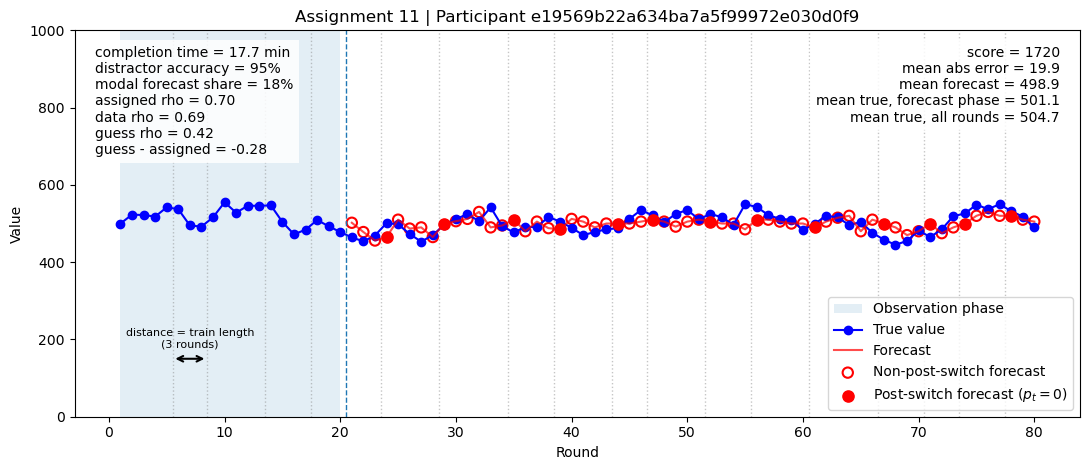

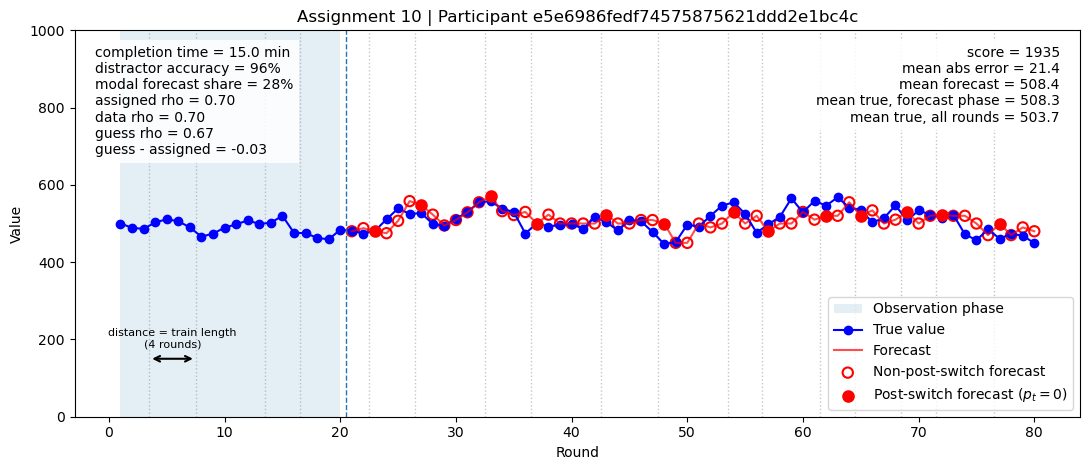

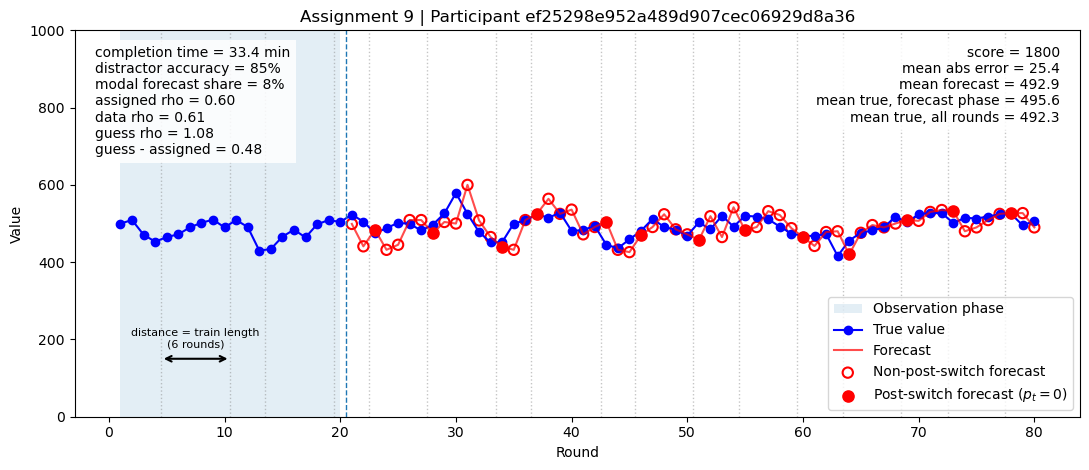

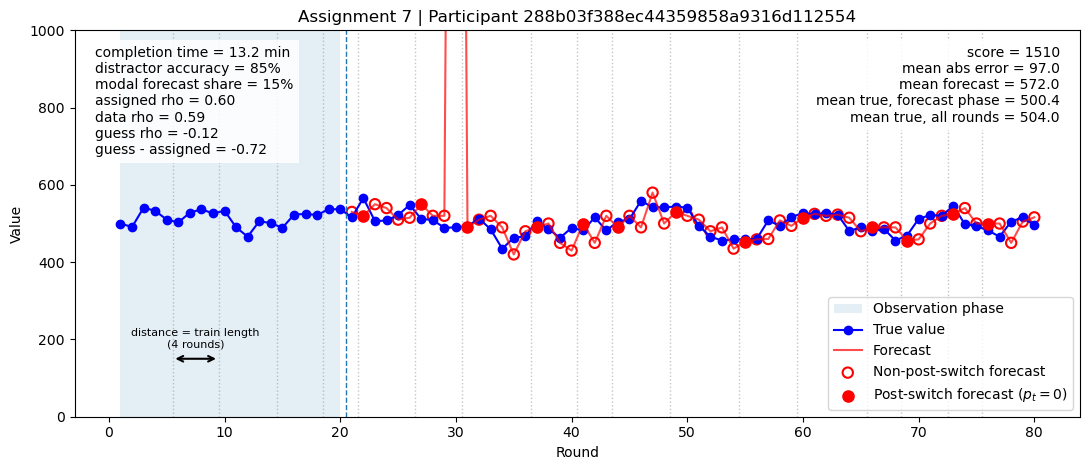

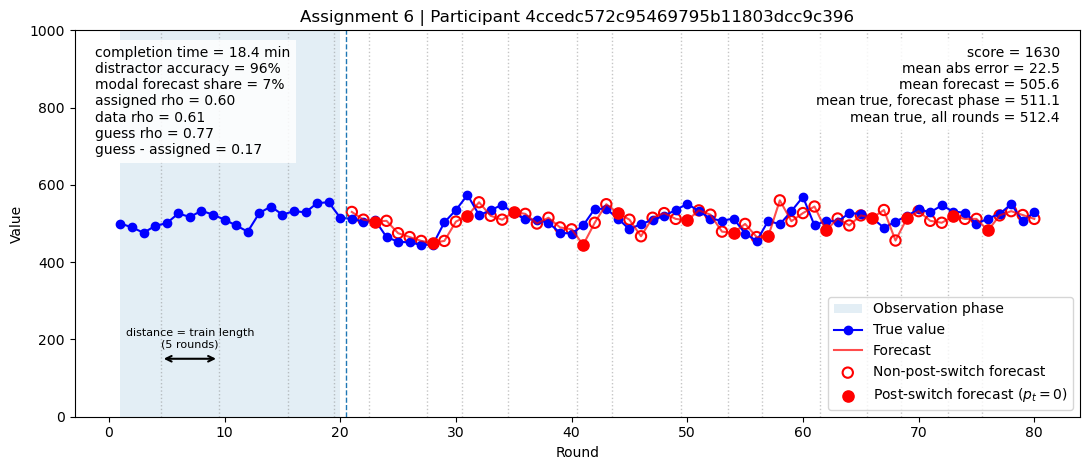

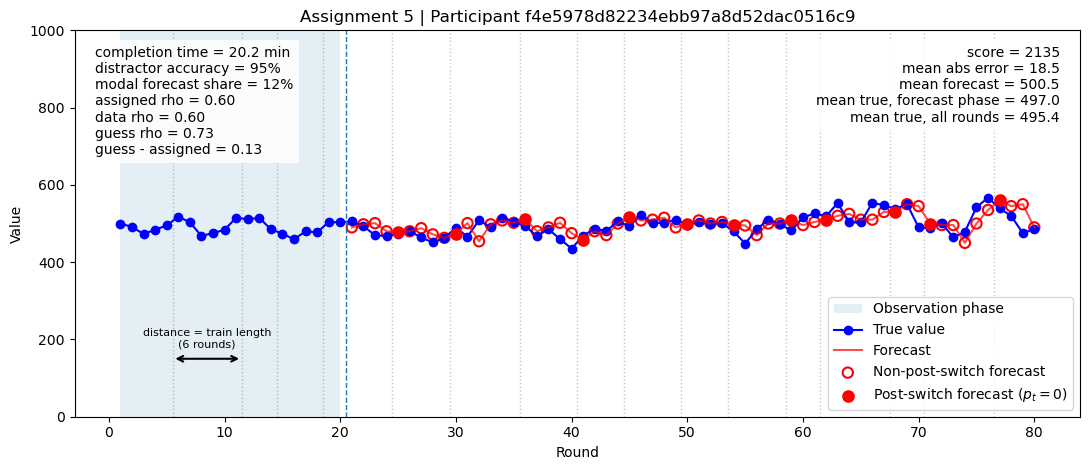

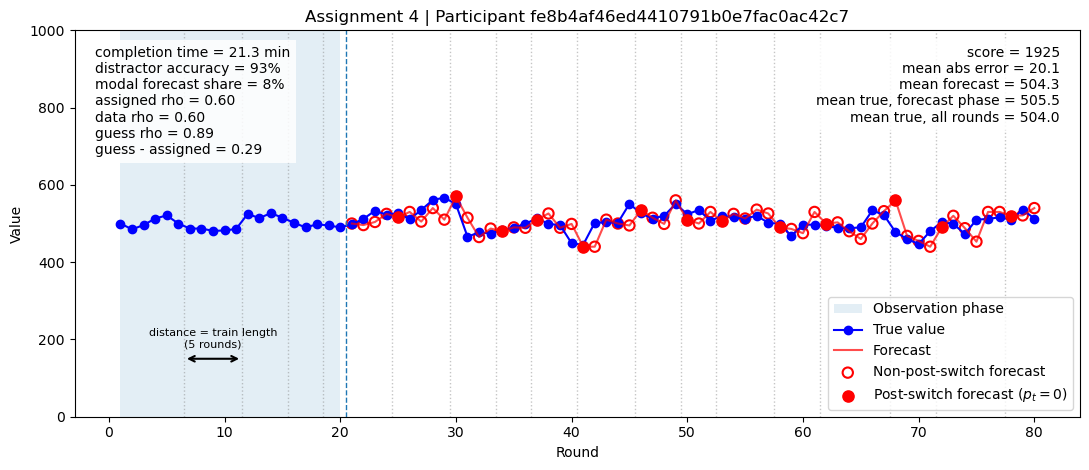

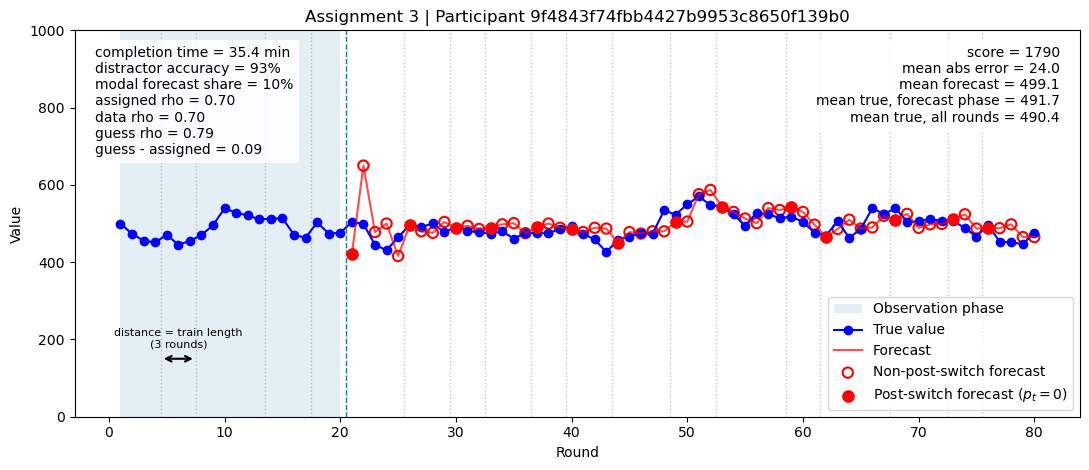

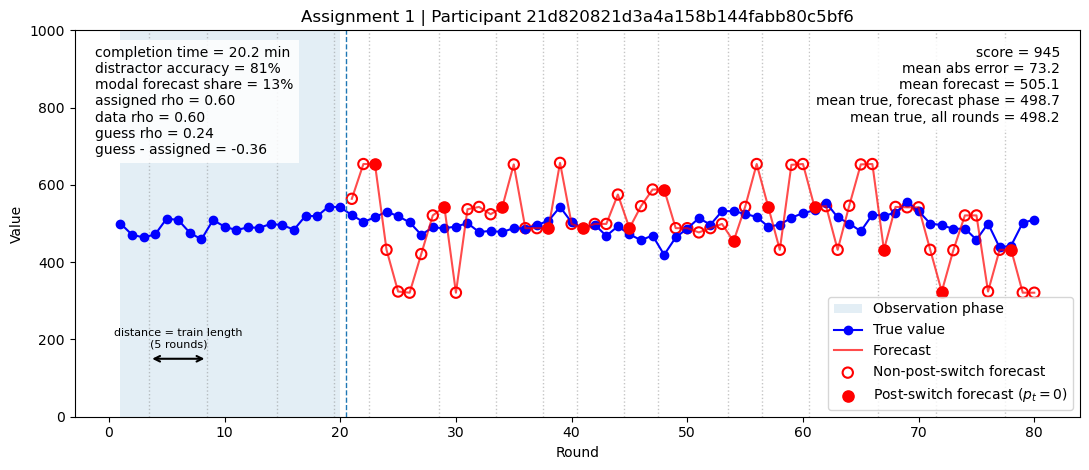

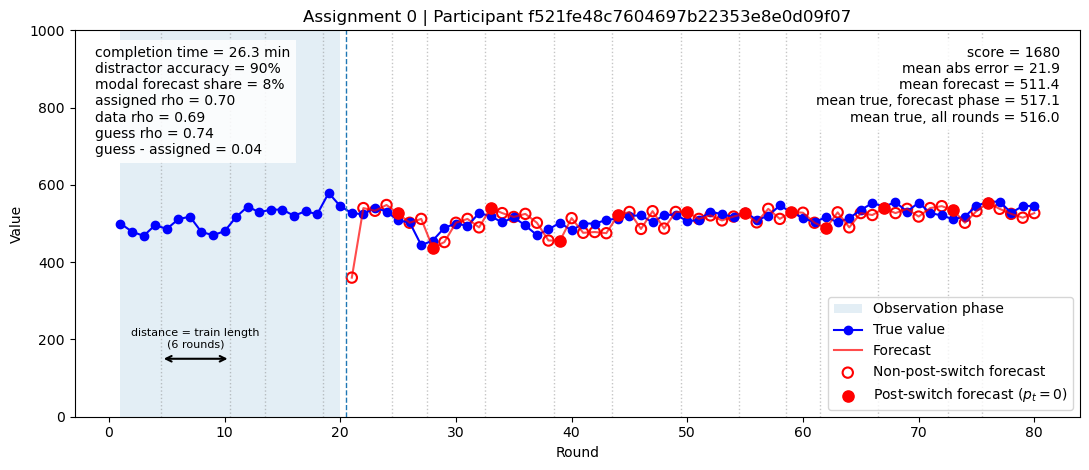

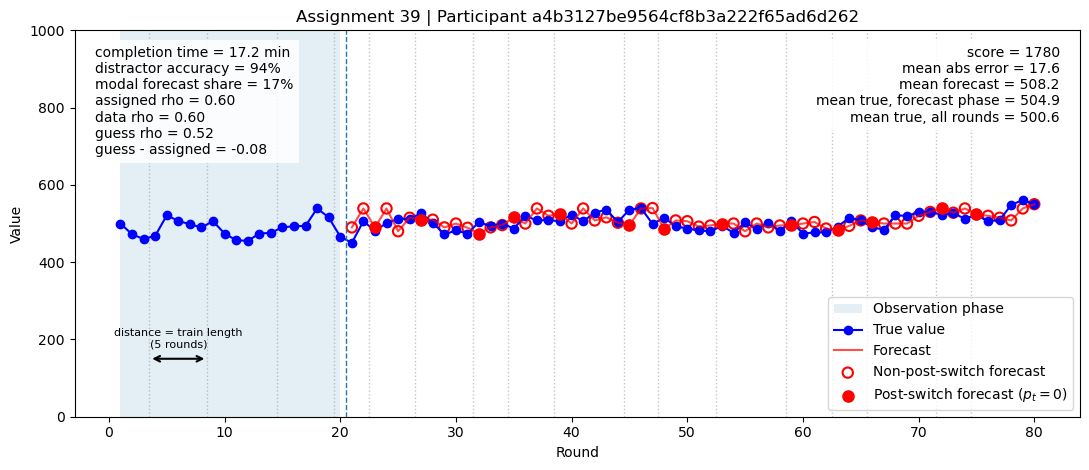

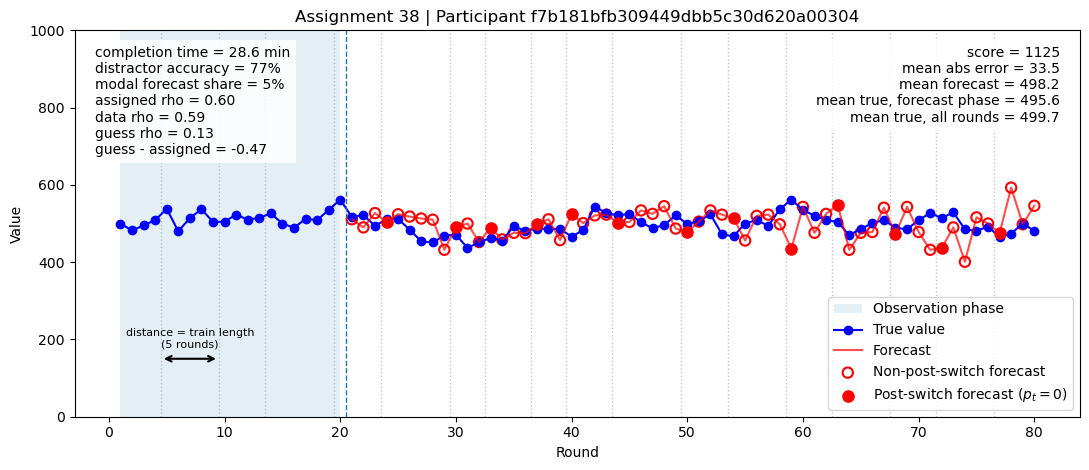

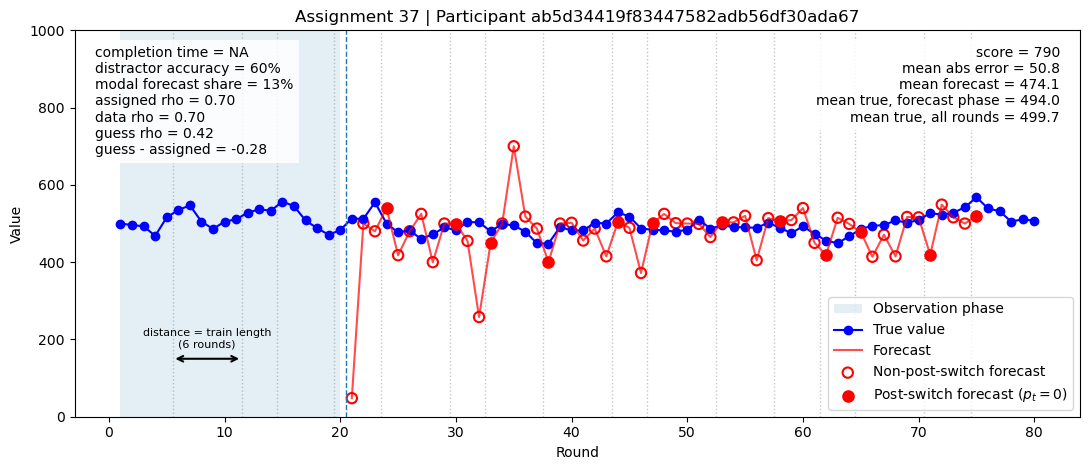

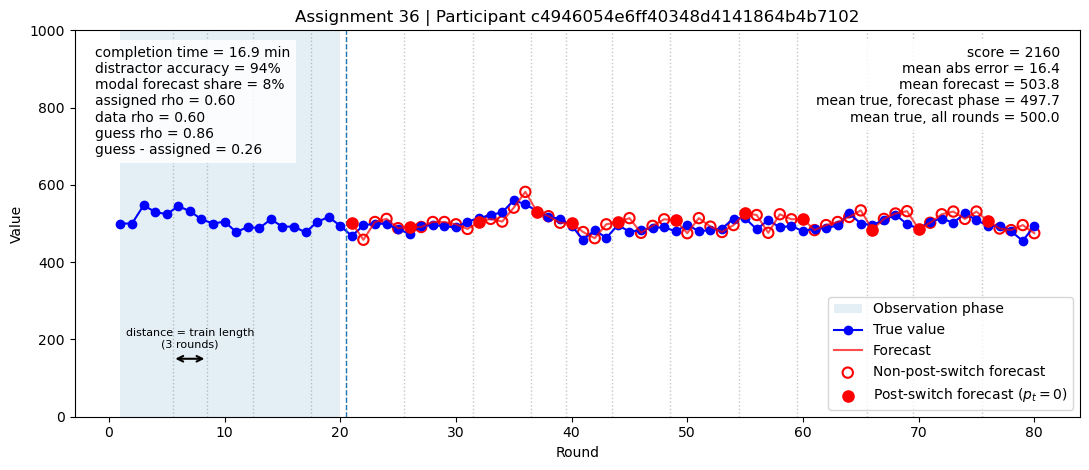

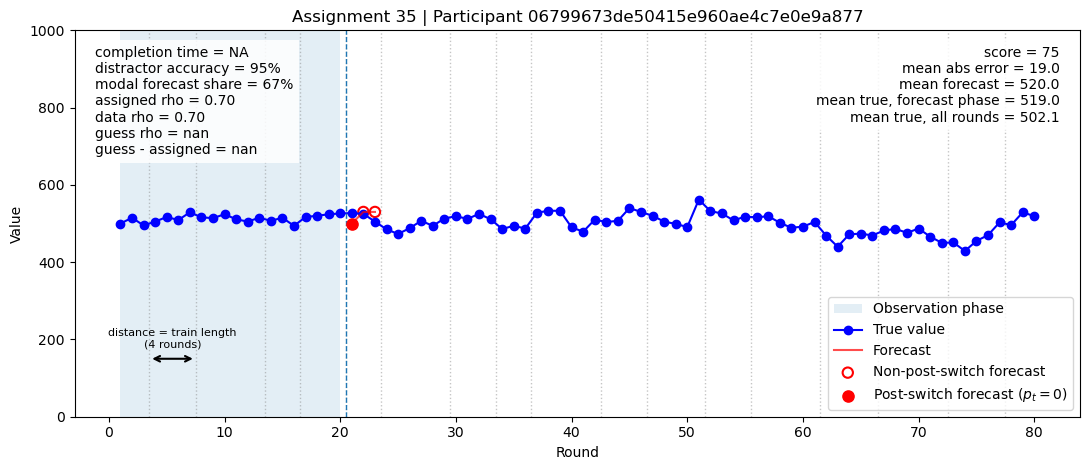

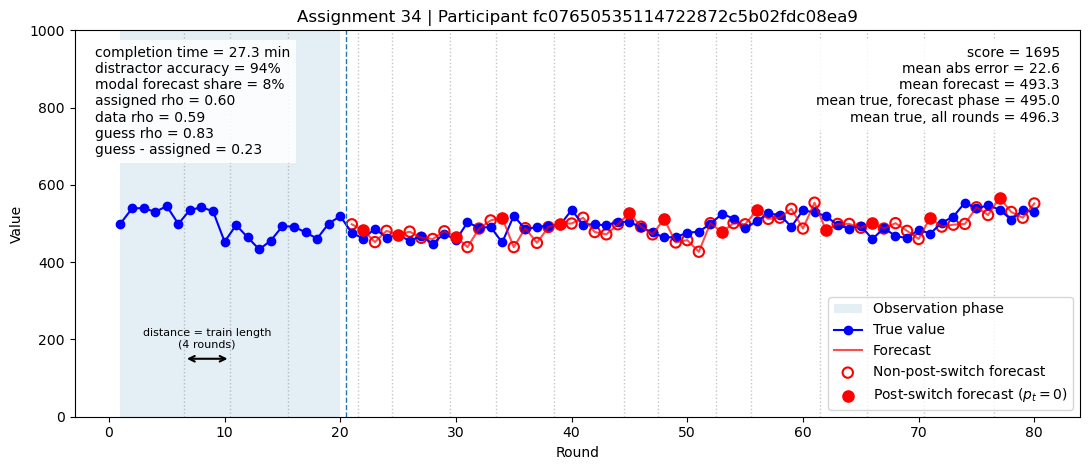

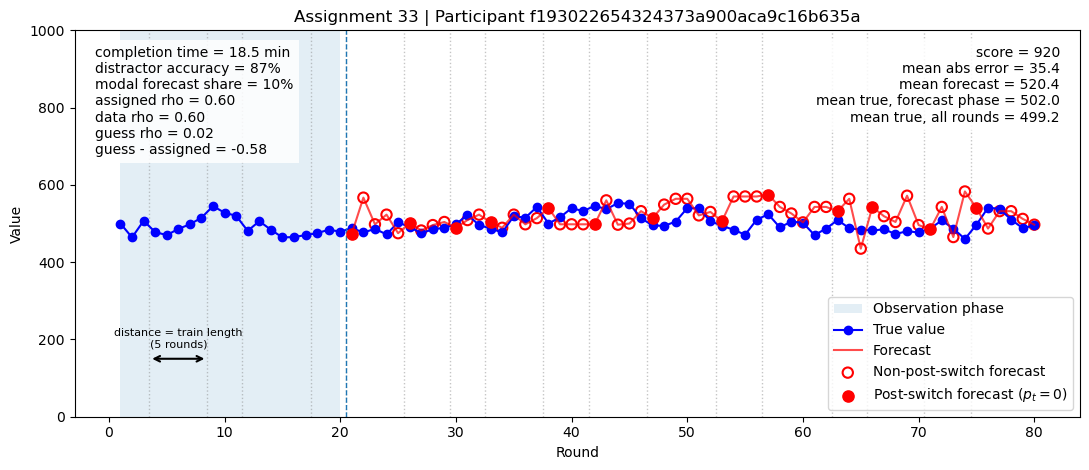

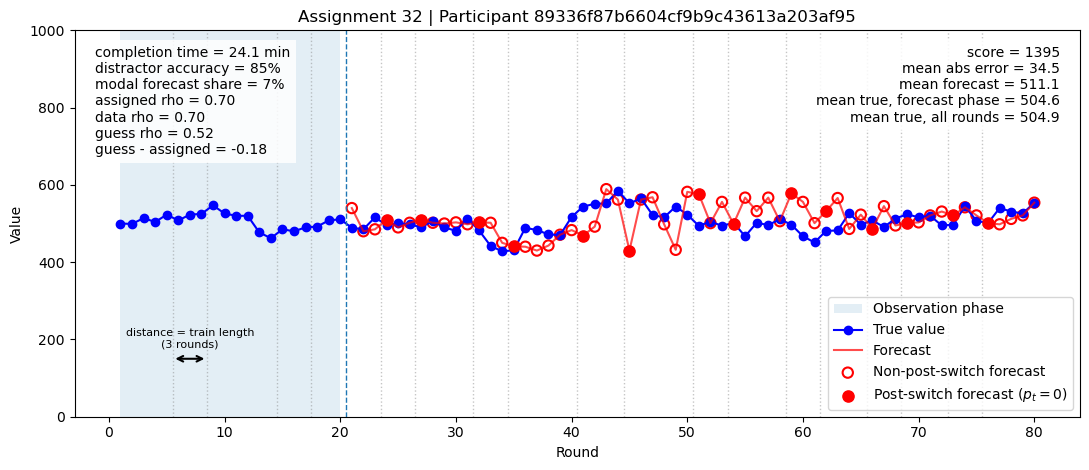

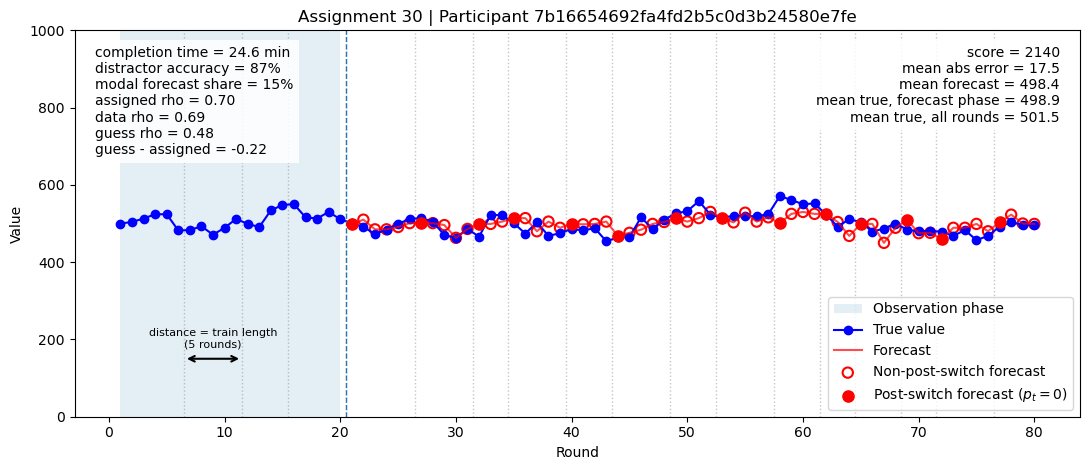

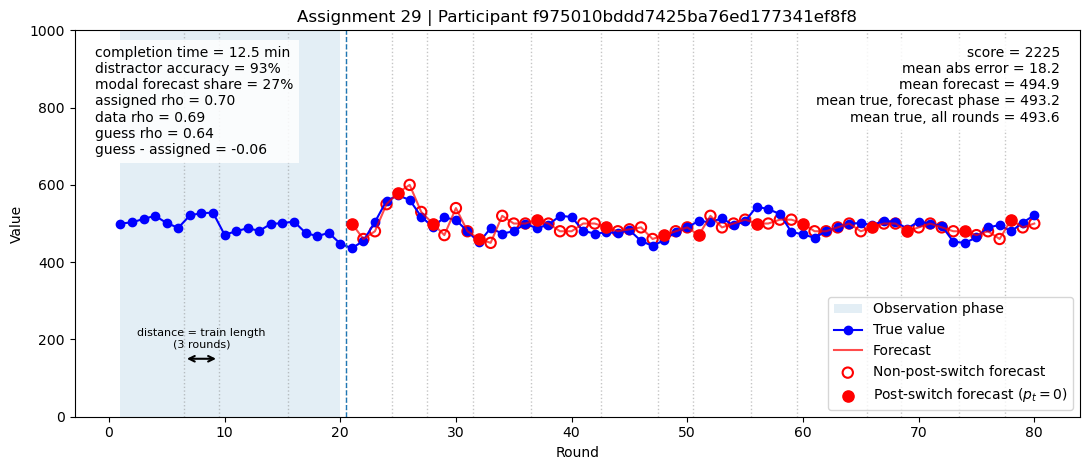

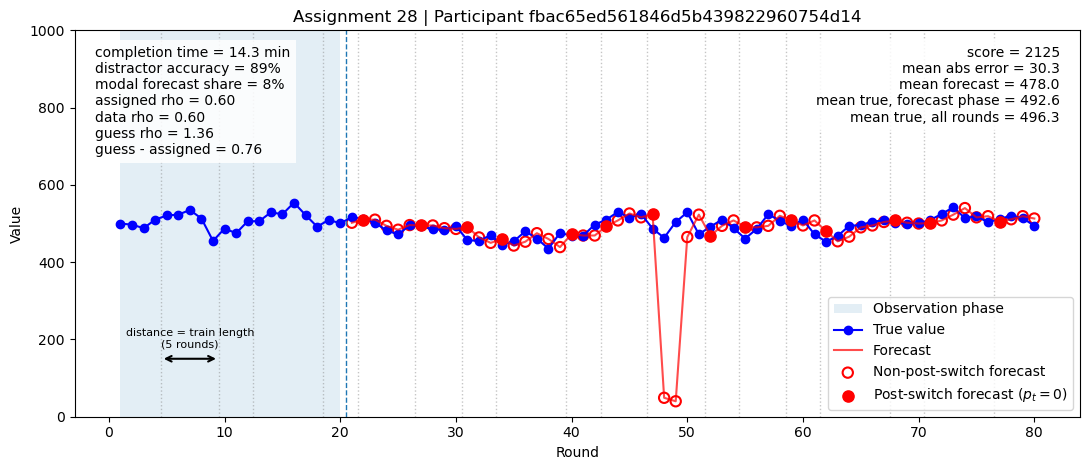

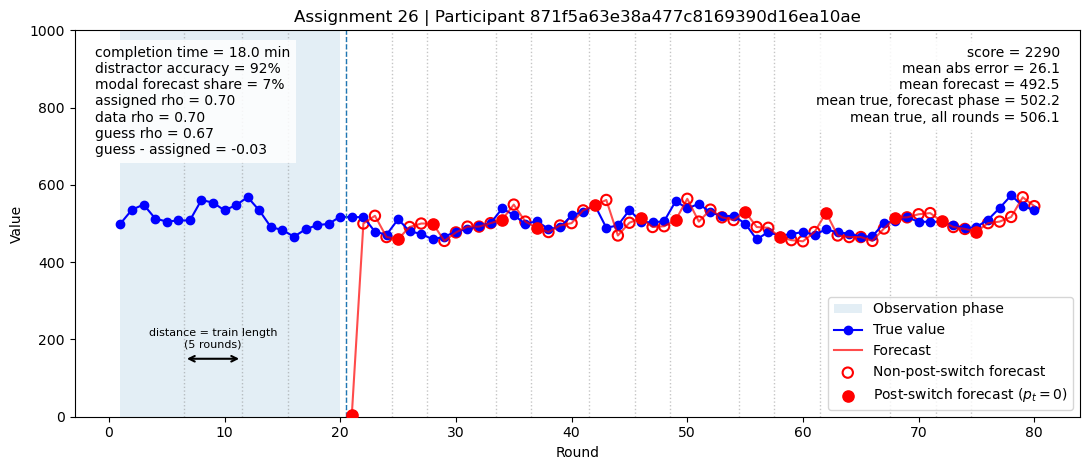

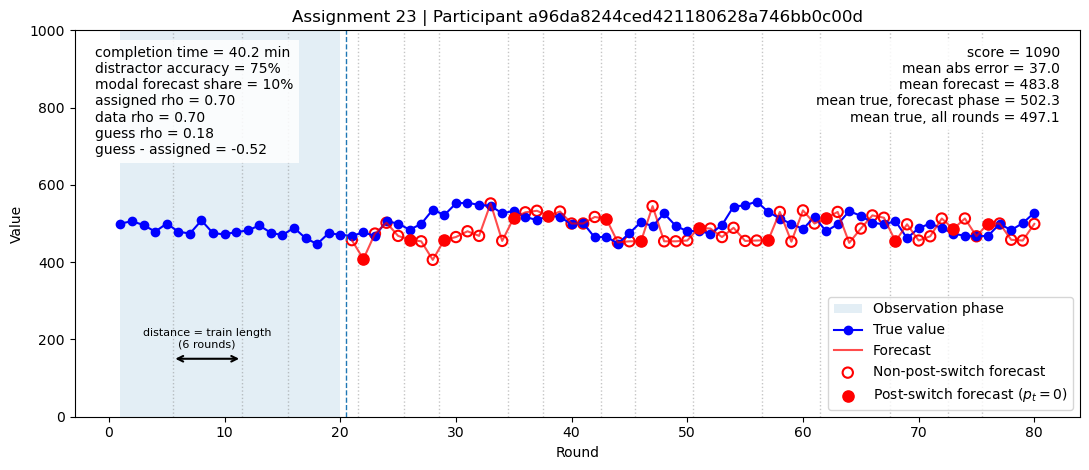

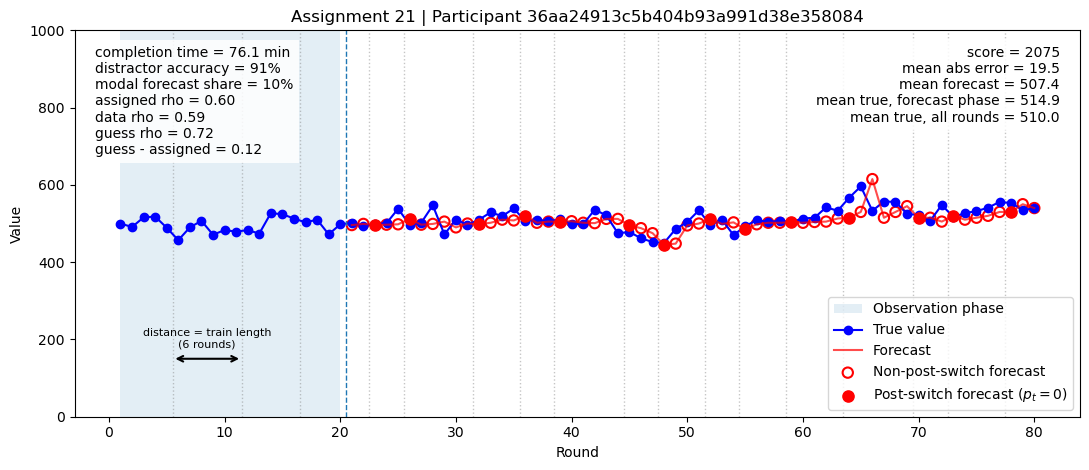

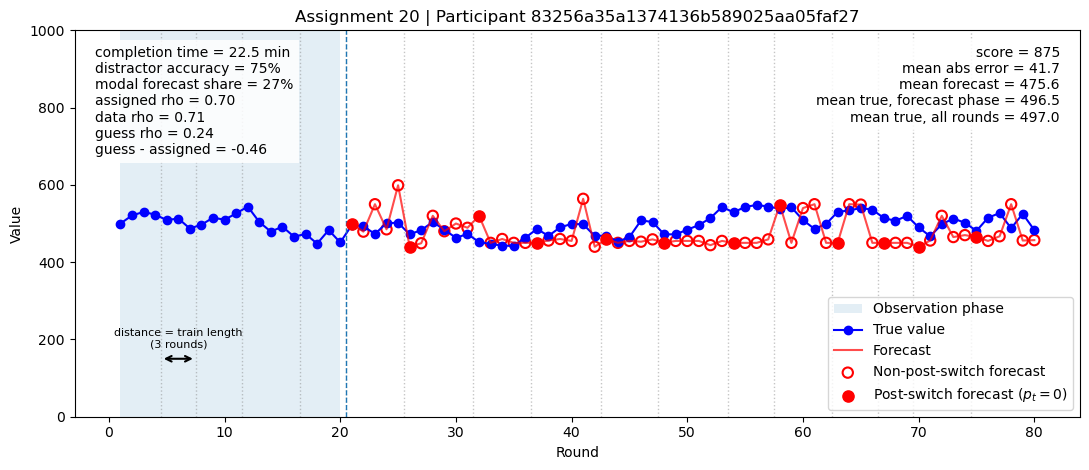

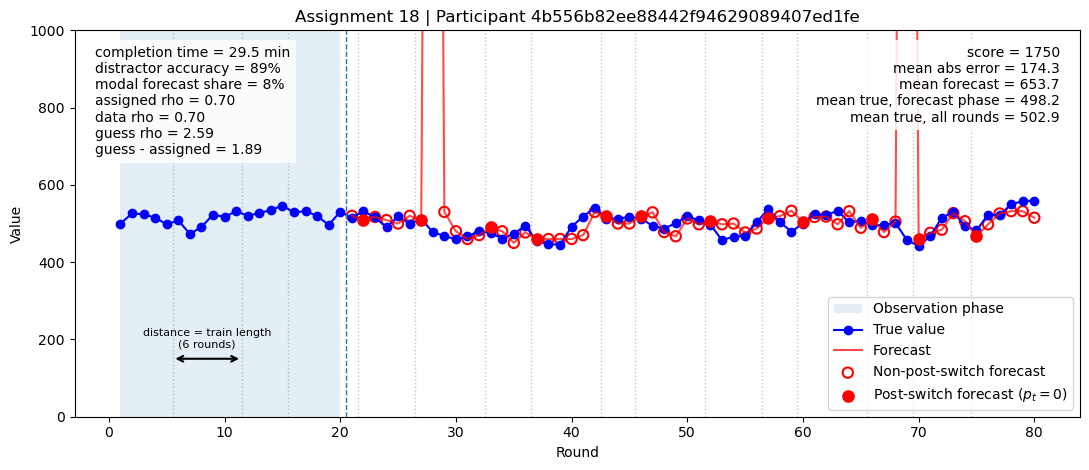

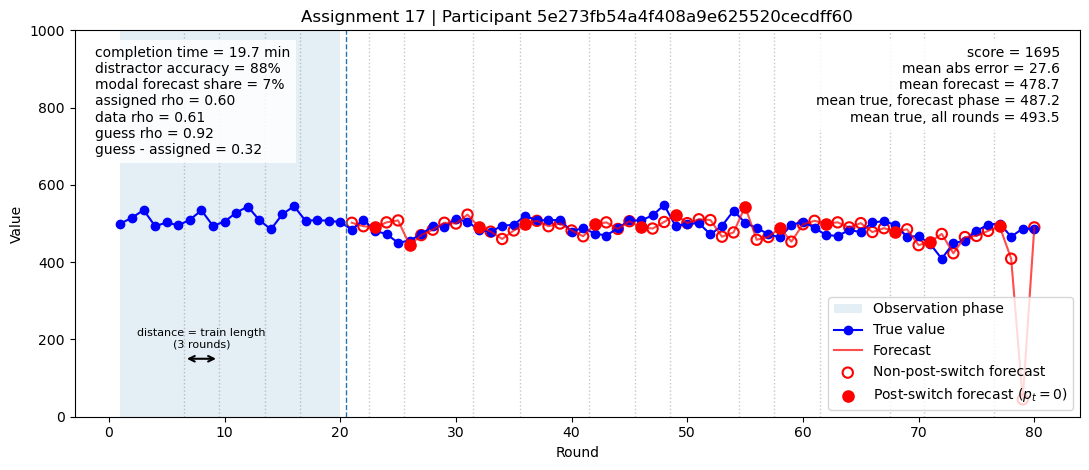

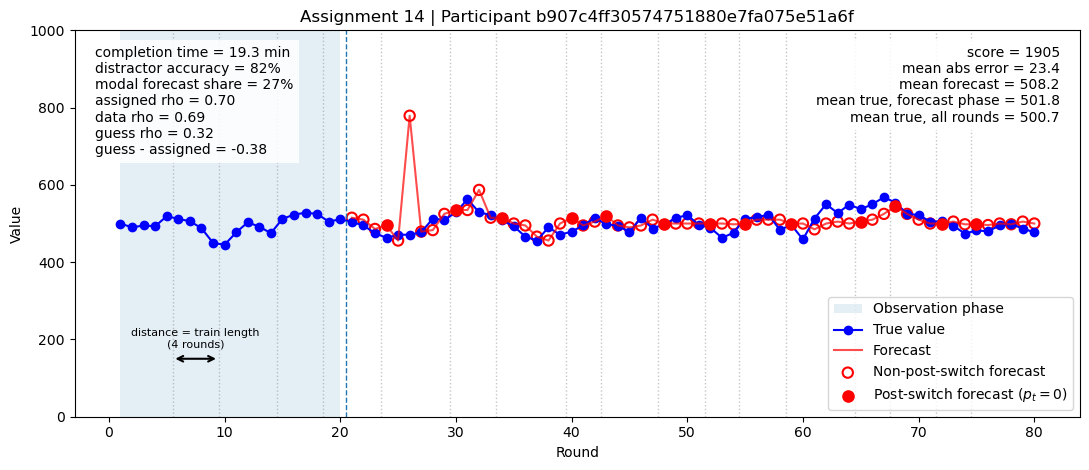

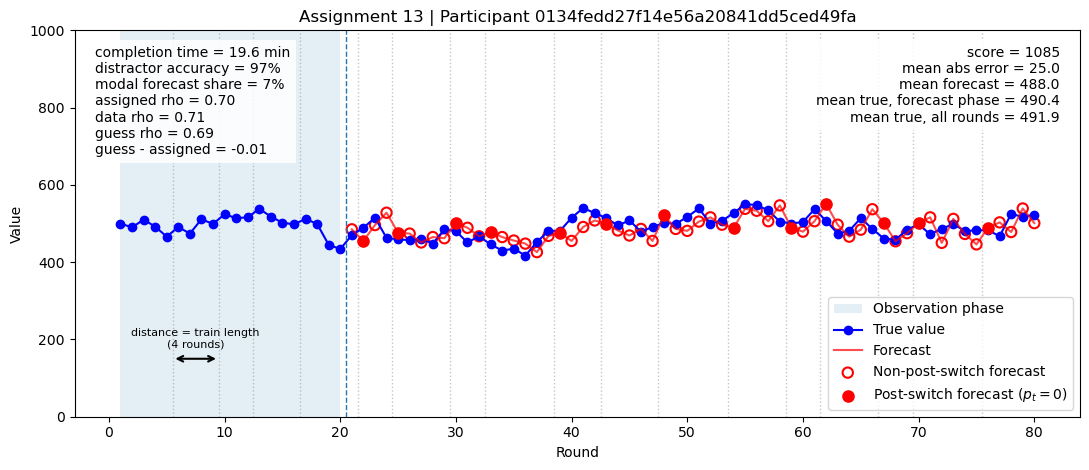

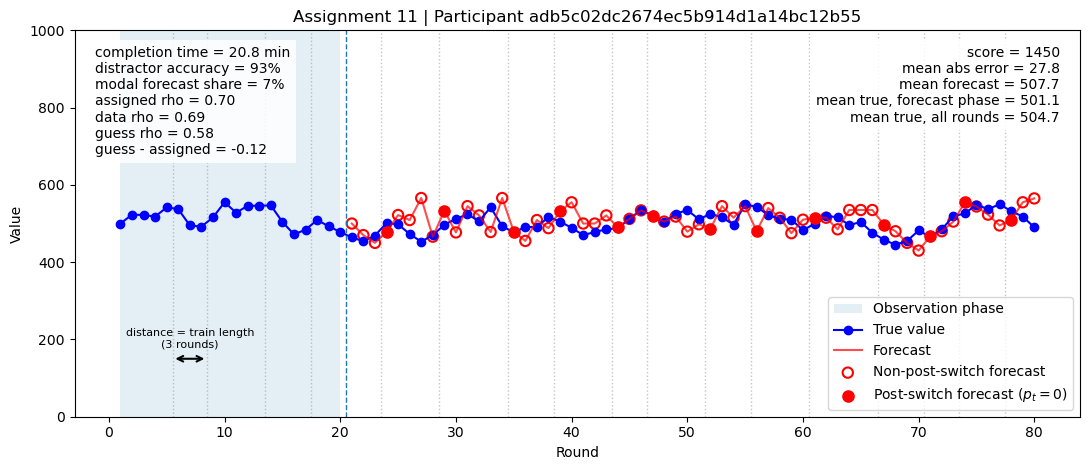

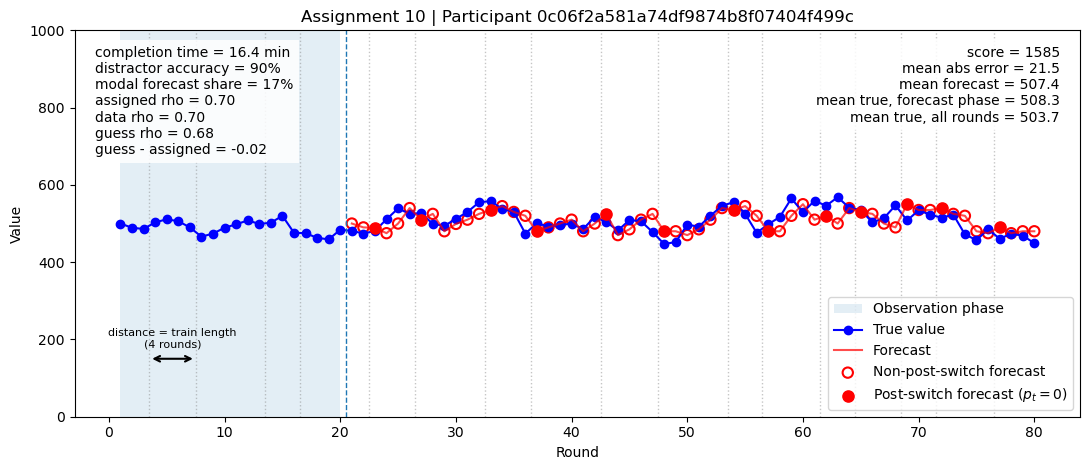

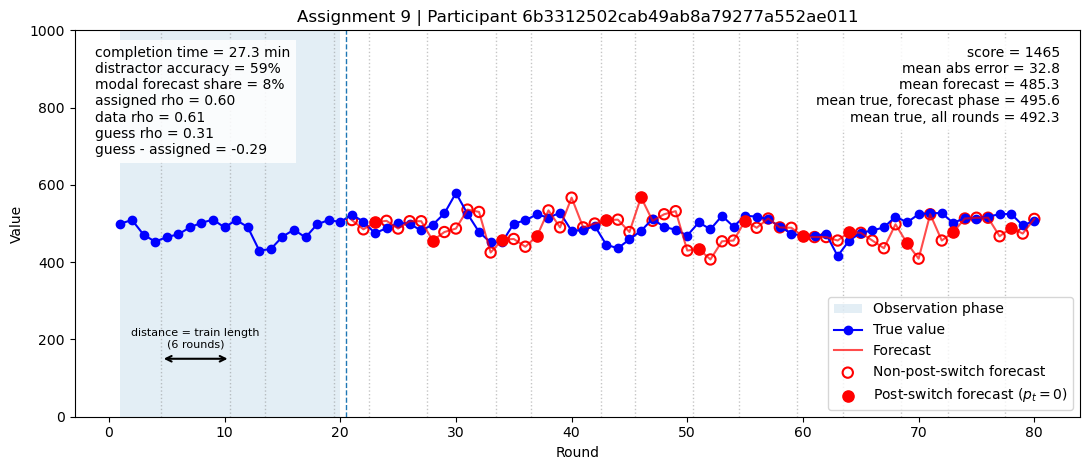

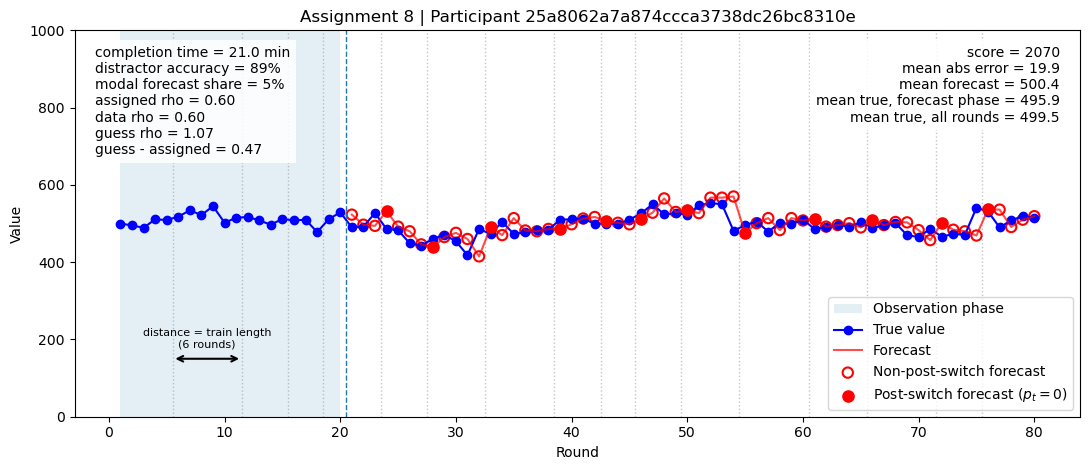

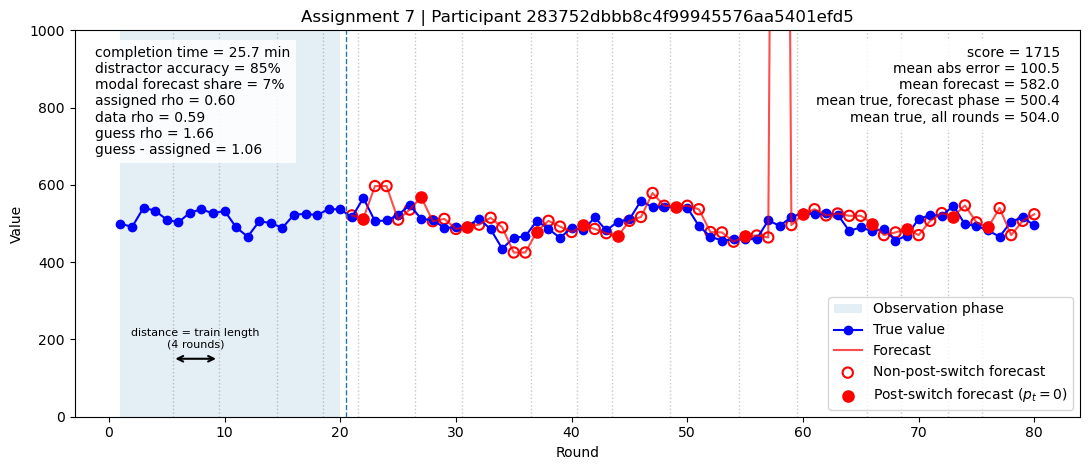

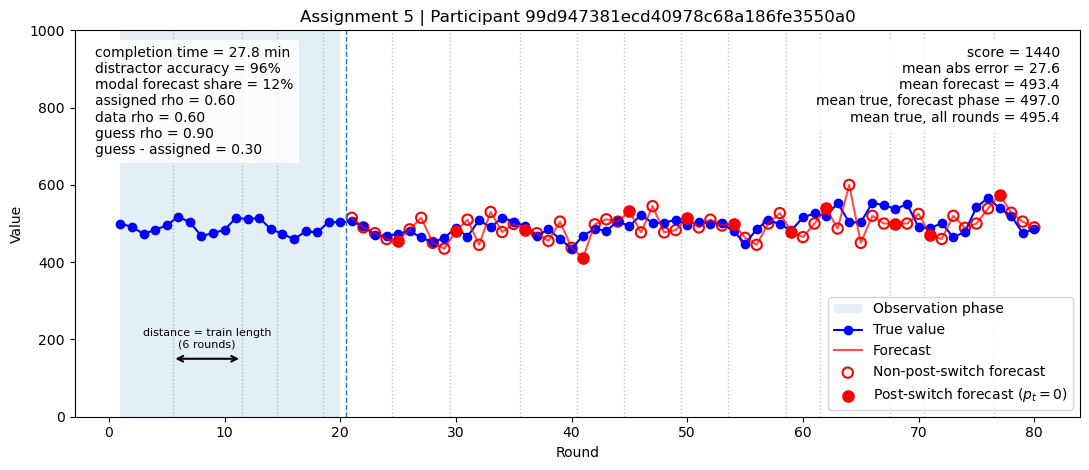

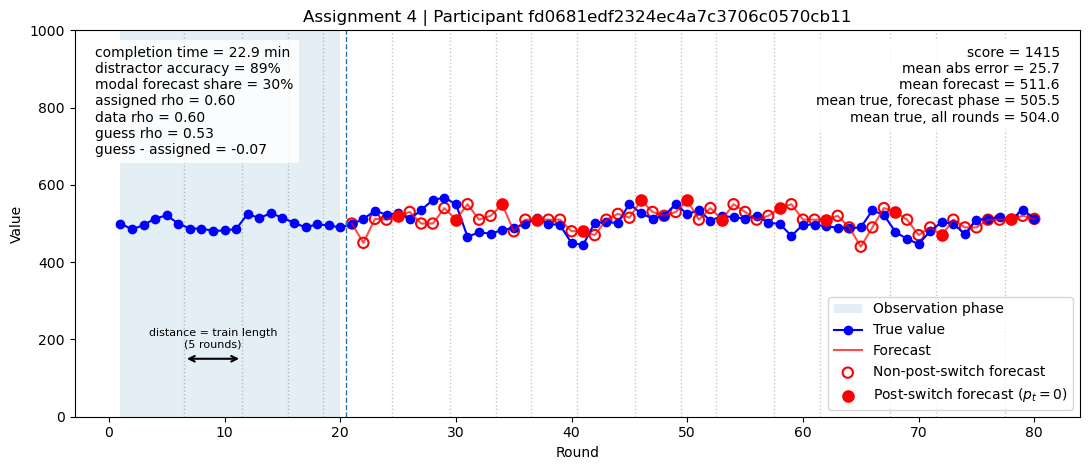

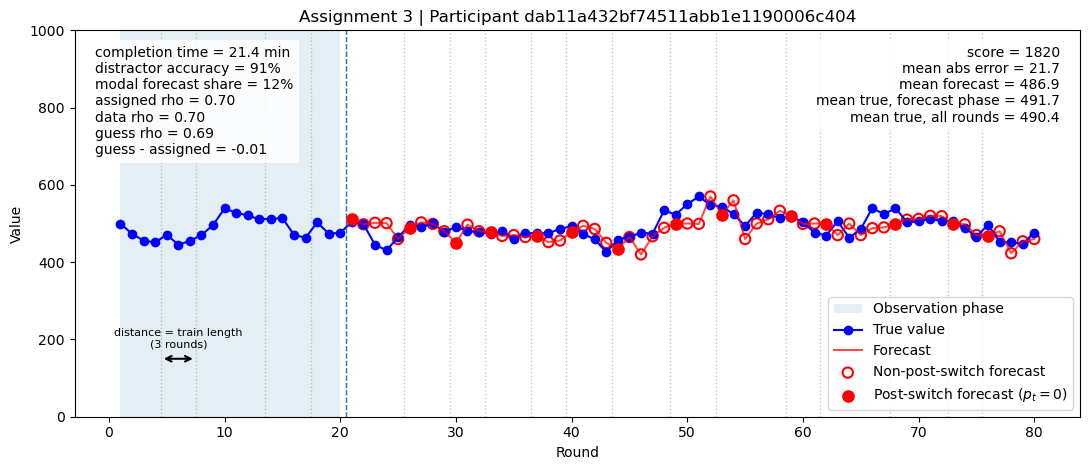

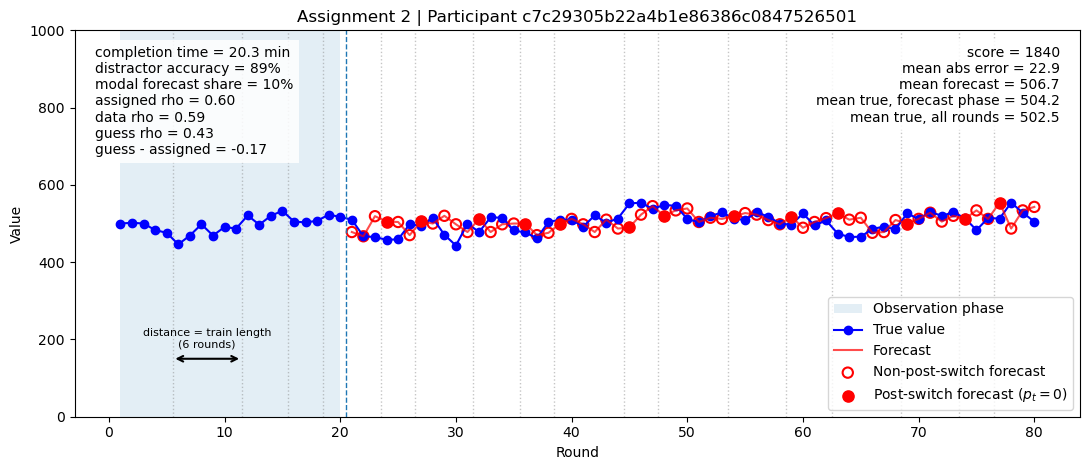

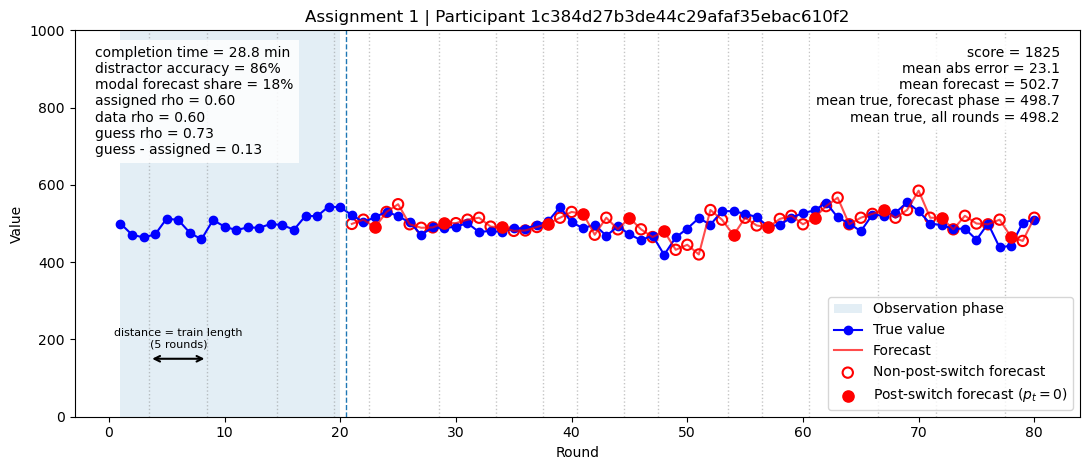

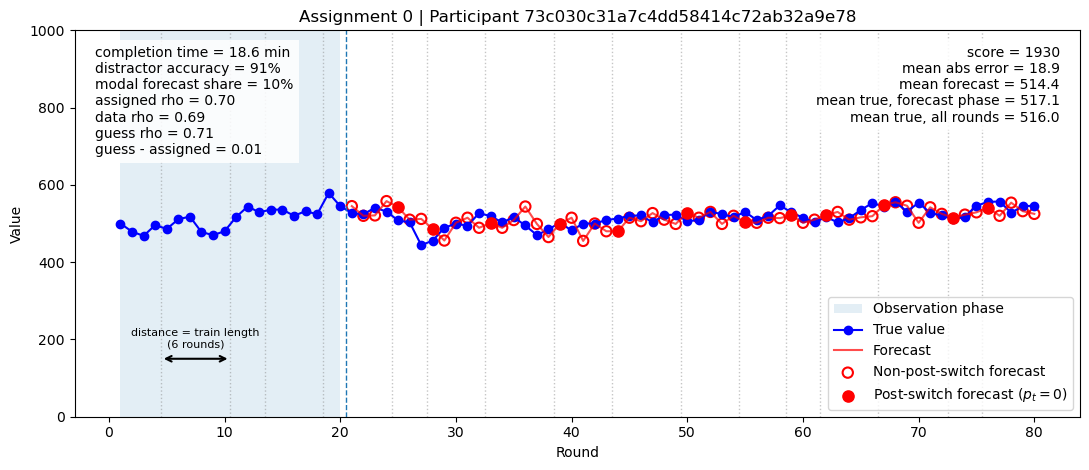

Saved plots for 47 participants to: /Users/oliversmirnov/Documents/GitHub/memory_forecasting_prolific/analysis_outputs/pilot_participant_plots


In [22]:
def add_third_train_distance_bracket(ax, g, y=930):
    """
    Add a bracket showing the distance between the first train and third train.

    Assumes:
      - g has display_round, train_id, task_type
      - train_id identifies contiguous task trains
      - the third train is the first return to the task type from train 1
    """

    train_summary = (
        g.dropna(subset=["train_id", "display_round"])
        .groupby("train_id", as_index=False)
        .agg(
            train_start=("display_round", "min"),
            train_end=("display_round", "max"),
            task_type=("task_type", "first"),
            train_length=("display_round", "count"),
        )
        .sort_values("train_start")
        .reset_index(drop=True)
    )

    if len(train_summary) < 3:
        return

    first_train = train_summary.iloc[0]
    second_train = train_summary.iloc[1]
    third_train = train_summary.iloc[2]

    # Optional safety check: third train should match first train's task type
    if third_train["task_type"] != first_train["task_type"]:
        return

    # Bracket spans the intervening train: after train 1, before train 3
    x_left = first_train["train_end"] + 0.5
    x_right = third_train["train_start"] - 0.5

    intervening_length = int(second_train["train_length"])

    ax.annotate(
        "",
        xy=(x_left, y),
        xytext=(x_right, y),
        arrowprops=dict(
            arrowstyle="<->",
            linewidth=1.5,
            color="black"
        )
    )

    ax.text(
        (x_left + x_right) / 2,
        y + 25,
        f"distance = train length\n({intervening_length} rounds)",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black"
    )

for participant_id in recent_participants:
    g = recent_plot_df[
        recent_plot_df[participant_col] == participant_id
    ].copy()

    if g.empty:
        continue

    g = g.sort_values("round_index").copy()

    # Display rounds as 1, 2, ..., 80 instead of 0, 1, ..., 79
    g["display_round"] = g["round_index"] + 1

    assigned_rho = g["assigned_rho"].dropna().iloc[0]
    assignment_slot = int(g["assignment_slot"].dropna().iloc[0])

    final_score = g["final_score"].dropna().max()
    if pd.isna(final_score):
        final_score_text = "NA"
    else:
        final_score_text = f"{final_score:.0f}"

    completion_time = g["completion_time_min"].dropna().max() if "completion_time_min" in g.columns else np.nan
    if pd.isna(completion_time):
        completion_time_text = "NA"
    else:
        completion_time_text = f"{completion_time:.1f} min"

    distractor_accuracy = (
        g["distractor_accuracy"].dropna().max() if "distractor_accuracy" in g.columns else np.nan
    )
    if pd.isna(distractor_accuracy):
        distractor_accuracy_text = "NA"
    else:
        distractor_accuracy_text = f"{distractor_accuracy:.0%}"

    # Data/sample rho using the full true sequence, including observation phase
    data_rho = estimate_slope_from_centered_ols(
        g.dropna(subset=["x_t", "x_next_true"]),
        y_col="x_next_true",
        x_col="x_t"
    )

    # Guess/implied rho using only rows with forecasts
    forecast_rows_for_stats = g.dropna(subset=["forecast_value", "x_t"]).copy()

    guess_rho = estimate_slope_from_centered_ols(
        forecast_rows_for_stats,
        y_col="forecast_value",
        x_col="x_t"
    )

    # Share of forecasts equal to this participant's single most common forecast
    # (computed once, above, alongside the primary-analysis quality filters).
    modal_forecast_share = (
        g["modal_forecast_share"].dropna().max() if "modal_forecast_share" in g.columns else np.nan
    )
    if pd.isna(modal_forecast_share):
        modal_forecast_share_text = "NA"
    else:
        modal_forecast_share_text = f"{modal_forecast_share:.0%}"

    mean_abs_error = np.mean(
        np.abs(
            forecast_rows_for_stats["forecast_value"]
            - forecast_rows_for_stats["x_next_true"]
        )
    )

    mean_forecast = forecast_rows_for_stats["forecast_value"].mean()
    mean_true_forecast_phase = forecast_rows_for_stats["x_next_true"].mean()
    mean_true_all = g["x_next_true"].mean()

    stats_text_left = (
        f"completion time = {completion_time_text}\n"
        f"distractor accuracy = {distractor_accuracy_text}\n"
        f"modal forecast share = {modal_forecast_share_text}\n"
        f"assigned rho = {assigned_rho:.2f}\n"
        f"data rho = {data_rho:.2f}\n"
        f"guess rho = {guess_rho:.2f}\n"
        f"guess - assigned = {guess_rho - assigned_rho:.2f}"
    )

    stats_text_right = (
        f"score = {final_score_text}\n"
        f"mean abs error = {mean_abs_error:.1f}\n"
        f"mean forecast = {mean_forecast:.1f}\n"
        f"mean true, forecast phase = {mean_true_forecast_phase:.1f}\n"
        f"mean true, all rounds = {mean_true_all:.1f}"
    )

    fig, ax = plt.subplots(figsize=(11, 4.8))

    train_boundaries = (
        g[["display_round", "train_id"]]
        .dropna()
        .drop_duplicates()
        .sort_values("display_round")
        .copy()
    )

    train_boundaries["previous_train_id"] = train_boundaries["train_id"].shift(1)

    switch_rounds = train_boundaries.loc[
        train_boundaries["train_id"] != train_boundaries["previous_train_id"],
        "display_round"
    ]

    # Skip the first round, because it is the beginning of the task, not a switch
    switch_rounds = switch_rounds[switch_rounds > 1]

    for switch_round in switch_rounds:
        ax.axvline(
            switch_round - 0.5,
            linestyle=":",
            linewidth=1,
            color="grey",
            alpha=0.45
        )

    # Observation region
    ax.axvspan(
        1,
        FORECAST_START_INDEX,
        alpha=0.12,
        label="Observation phase"
    )

    # True values for all rounds, including observation
    ax.plot(
        g["display_round"],
        g["x_next_true"],
        marker="o",
        color="blue",
        label="True value"
    )

    # Forecast rows
    forecast_rows_for_stats = g.dropna(subset=["forecast_value", "x_t"]).copy()

    post_switch_forecasts = forecast_rows_for_stats[
        forecast_rows_for_stats["p_t"] == 0
    ].copy()

    non_post_switch_forecasts = forecast_rows_for_stats[
        forecast_rows_for_stats["p_t"] != 0
    ].copy()

    # Forecast line across all forecast rounds
    ax.plot(
        forecast_rows_for_stats["display_round"],
        forecast_rows_for_stats["forecast_value"],
        color="red",
        linewidth=1.5,
        alpha=0.70,
        label="Forecast"
    )

    # Non-post-switch forecasts: hollow red circles
    ax.scatter(
        non_post_switch_forecasts["display_round"],
        non_post_switch_forecasts["forecast_value"],
        facecolors="none",
        edgecolors="red",
        s=55,
        marker='o',
        linewidths=1.5,
        label="Non-post-switch forecast"
    )

    # Post-switch forecasts: filled red circles
    ax.scatter(
        post_switch_forecasts["display_round"],
        post_switch_forecasts["forecast_value"],
        color="red",
        s=65,
        marker='o',
        zorder=5,
        label=r"Post-switch forecast $(p_t=0)$"
    )
    
    add_third_train_distance_bracket(ax, g, y=150)

    # Mark transition into forecast phase
    ax.axvline(
        FORECAST_START_INDEX + 0.5,
        linestyle="--",
        linewidth=1
    )


    ax.set_ylim(0, 1000)
    ax.set_xlabel("Round")
    ax.set_ylabel("Value")
    ax.set_title(
        f"Assignment {assignment_slot} | Participant {participant_id}"
    )

    ax.text(
        0.02,
        0.96,
        stats_text_left,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.text(
        0.98,
        0.96,
        stats_text_right,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.legend(loc="lower right")
    # ax.grid(True, alpha=0.3)

    plt.tight_layout()

    filename = f"assignment_{assignment_slot}_{participant_id}.png"
    safe_filename = (
        filename
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace(" ", "_")
    )

    plt.savefig(OUT_DIR / safe_filename, dpi=150)
    plt.show()

print(f"Saved plots for {len(recent_participants)} participants to: {OUT_DIR}")

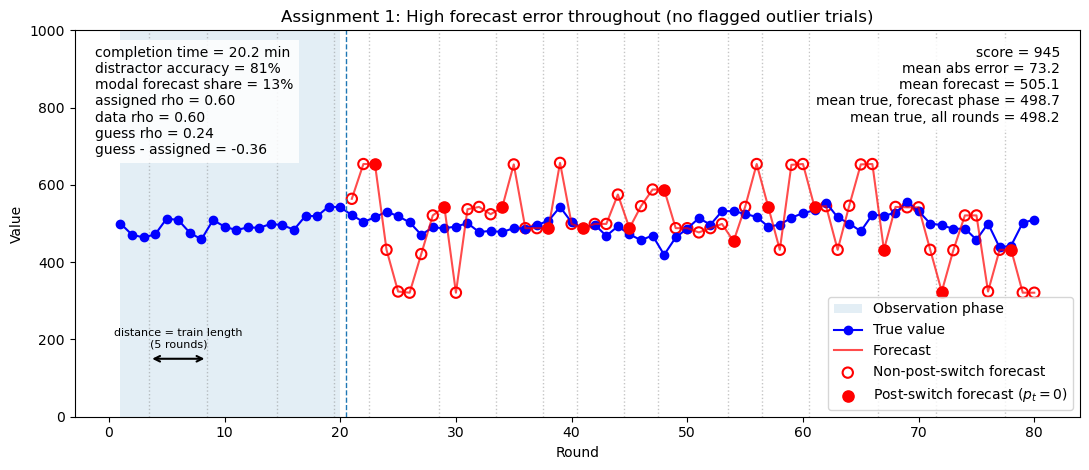

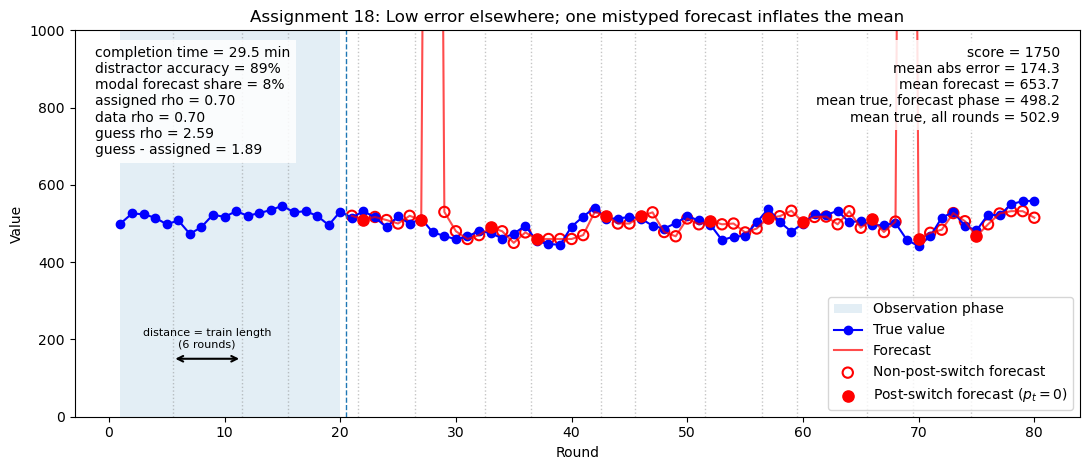

Saved redacted persona plots to: /Users/oliversmirnov/Documents/GitHub/memory_forecasting_prolific/analysis_outputs/pilot_participant_plots


In [23]:
_persona_ids = {
    "<redacted>b80c5bf6": ("appendix_personaA_highmae", "High forecast error throughout (no flagged outlier trials)"),
    "<redacted>407ed1fe": ("appendix_personaB_outlierremoved", "Low error elsewhere; one mistyped forecast inflates the mean"),
}

for participant_id, (out_stub, title_suffix) in _persona_ids.items():
    g = recent_plot_df[
        recent_plot_df[participant_col] == participant_id
    ].copy()

    if g.empty:
        continue

    g = g.sort_values("round_index").copy()
    g["display_round"] = g["round_index"] + 1

    assigned_rho = g["assigned_rho"].dropna().iloc[0]
    assignment_slot = int(g["assignment_slot"].dropna().iloc[0])

    final_score = g["final_score"].dropna().max()
    final_score_text = "NA" if pd.isna(final_score) else f"{final_score:.0f}"

    completion_time = g["completion_time_min"].dropna().max() if "completion_time_min" in g.columns else np.nan
    completion_time_text = "NA" if pd.isna(completion_time) else f"{completion_time:.1f} min"

    distractor_accuracy = g["distractor_accuracy"].dropna().max() if "distractor_accuracy" in g.columns else np.nan
    distractor_accuracy_text = "NA" if pd.isna(distractor_accuracy) else f"{distractor_accuracy:.0%}"

    data_rho = estimate_slope_from_centered_ols(
        g.dropna(subset=["x_t", "x_next_true"]), y_col="x_next_true", x_col="x_t"
    )

    forecast_rows_for_stats = g.dropna(subset=["forecast_value", "x_t"]).copy()
    guess_rho = estimate_slope_from_centered_ols(
        forecast_rows_for_stats, y_col="forecast_value", x_col="x_t"
    )

    modal_forecast_share = g["modal_forecast_share"].dropna().max() if "modal_forecast_share" in g.columns else np.nan
    modal_forecast_share_text = "NA" if pd.isna(modal_forecast_share) else f"{modal_forecast_share:.0%}"

    mean_abs_error = np.mean(np.abs(
        forecast_rows_for_stats["forecast_value"] - forecast_rows_for_stats["x_next_true"]
    ))
    mean_forecast = forecast_rows_for_stats["forecast_value"].mean()
    mean_true_forecast_phase = forecast_rows_for_stats["x_next_true"].mean()
    mean_true_all = g["x_next_true"].mean()

    stats_text_left = (
        f"completion time = {completion_time_text}\n"
        f"distractor accuracy = {distractor_accuracy_text}\n"
        f"modal forecast share = {modal_forecast_share_text}\n"
        f"assigned rho = {assigned_rho:.2f}\n"
        f"data rho = {data_rho:.2f}\n"
        f"guess rho = {guess_rho:.2f}\n"
        f"guess - assigned = {guess_rho - assigned_rho:.2f}"
    )
    stats_text_right = (
        f"score = {final_score_text}\n"
        f"mean abs error = {mean_abs_error:.1f}\n"
        f"mean forecast = {mean_forecast:.1f}\n"
        f"mean true, forecast phase = {mean_true_forecast_phase:.1f}\n"
        f"mean true, all rounds = {mean_true_all:.1f}"
    )

    fig, ax = plt.subplots(figsize=(11, 4.8))

    train_boundaries = (
        g[["display_round", "train_id"]].dropna().drop_duplicates()
        .sort_values("display_round").copy()
    )
    train_boundaries["previous_train_id"] = train_boundaries["train_id"].shift(1)
    switch_rounds = train_boundaries.loc[
        train_boundaries["train_id"] != train_boundaries["previous_train_id"], "display_round"
    ]
    switch_rounds = switch_rounds[switch_rounds > 1]
    for switch_round in switch_rounds:
        ax.axvline(switch_round - 0.5, linestyle=":", linewidth=1, color="grey", alpha=0.45)

    ax.axvspan(1, FORECAST_START_INDEX, alpha=0.12, label="Observation phase")

    ax.plot(g["display_round"], g["x_next_true"], marker="o", color="blue", label="True value")

    forecast_rows_for_stats = g.dropna(subset=["forecast_value", "x_t"]).copy()
    post_switch_forecasts = forecast_rows_for_stats[forecast_rows_for_stats["p_t"] == 0].copy()
    non_post_switch_forecasts = forecast_rows_for_stats[forecast_rows_for_stats["p_t"] != 0].copy()

    ax.plot(
        forecast_rows_for_stats["display_round"], forecast_rows_for_stats["forecast_value"],
        color="red", linewidth=1.5, alpha=0.70, label="Forecast"
    )
    ax.scatter(
        non_post_switch_forecasts["display_round"], non_post_switch_forecasts["forecast_value"],
        facecolors="none", edgecolors="red", s=55, marker='o', linewidths=1.5,
        label="Non-post-switch forecast"
    )
    ax.scatter(
        post_switch_forecasts["display_round"], post_switch_forecasts["forecast_value"],
        color="red", s=65, marker='o', zorder=5, label=r"Post-switch forecast $(p_t=0)$"
    )

    add_third_train_distance_bracket(ax, g, y=150)

    ax.axvline(FORECAST_START_INDEX + 0.5, linestyle="--", linewidth=1)

    ax.set_ylim(0, 1000)
    ax.set_xlabel("Round")
    ax.set_ylabel("Value")
    ax.set_title(f"Assignment {assignment_slot}: {title_suffix}")

    ax.text(0.02, 0.96, stats_text_left, transform=ax.transAxes, ha="left", va="top",
            fontsize=10, bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))
    ax.text(0.98, 0.96, stats_text_right, transform=ax.transAxes, ha="right", va="top",
            fontsize=10, bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

    ax.legend(loc="lower right")
    plt.tight_layout()

    plt.savefig(OUT_DIR / f"{out_stub}.png", dpi=150)
    plt.show()

print("Saved redacted persona plots to:", OUT_DIR)

In [24]:
baseline_overreaction_table = persistence_tests.copy()

baseline_overreaction_table["stars"] = baseline_overreaction_table[
    "p_value_implied_rho_greater_than_true_rho"
].apply(add_stars)

baseline_overreaction_table["stars_vs_nominal"] = baseline_overreaction_table[
    "p_value_vs_nominal"
].apply(add_stars)

baseline_overreaction_table = baseline_overreaction_table[
    [
        "assigned_rho",
        "n_participants",
        "mean_realized_rho",
        "mean_implied_rho",
        "mean_rho_excess",
        "t_stat",
        "p_value_implied_rho_greater_than_true_rho",
        "stars",
    ]
]

display(Markdown(
    "## 1. Baseline overreaction: implied persistence > realized persistence\n\n"
    "`mean_rho_excess` is implied persistence minus the persistence actually "
    "present in the series each participant saw (`mean_realized_rho`), not "
    "minus the nominal rho."
))

display(format_result_table(baseline_overreaction_table))

display(Markdown(
    "### Robustness: the same test benchmarked against the nominal rho"
))

display(format_result_table(
    persistence_tests[
        [
            "assigned_rho",
            "n_participants",
            "mean_rho_excess_vs_nominal",
            "t_stat_vs_nominal",
            "p_value_vs_nominal",
        ]
    ].assign(
        stars=persistence_tests["p_value_vs_nominal"].apply(add_stars)
    )
))

## 1. Baseline overreaction: implied persistence > realized persistence

`mean_rho_excess` is implied persistence minus the persistence actually present in the series each participant saw (`mean_realized_rho`), not minus the nominal rho.

,assigned_rho,n_participants,mean_realized_rho,mean_implied_rho,mean_rho_excess,t_stat,p_value_implied_rho_greater_than_true_rho,stars
0,0.6,20,0.5995,0.7152,0.1157,1.1883,0.1247,
1,0.7,17,0.6993,0.6830,-0.0164,-0.1288,0.5504,


### Robustness: the same test benchmarked against the nominal rho

,assigned_rho,n_participants,mean_rho_excess_vs_nominal,t_stat_vs_nominal,p_value_vs_nominal,stars
0,0.6,20,0.1152,1.1800,0.1263,
1,0.7,17,-0.0170,-0.1344,0.5526,


In [25]:
postswitch_gamma_table = simple_gamma_postswitch_tests.copy()

postswitch_gamma_table["stars"] = postswitch_gamma_table[
    "p_value_gamma_greater_than_0"
].apply(add_stars)

postswitch_gamma_table = postswitch_gamma_table[
    [
        "assigned_rho",
        "lag_spec",
        "post_switch_positions",
        "n_participants",
        "mean_gamma",
        "median_gamma",
        "t_stat",
        "p_value_gamma_greater_than_0",
        "stars",
    ]
]

display(Markdown("## 2. Post-switch forecast bias: x_match effect, p_t = 0 or 1"))

display(format_result_table(postswitch_gamma_table))

## 2. Post-switch forecast bias: x_match effect, p_t = 0 or 1

,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,t_stat,p_value_gamma_greater_than_0,stars
0,0.6,2,"[0, 1]",20,0.1529,0.0743,1.4537,0.0812,*
1,0.6,3,"[0, 1]",20,0.1805,0.1268,1.6222,0.0606,*
2,0.7,2,"[0, 1]",17,0.6913,0.1312,1.0241,0.1605,
3,0.7,3,"[0, 1]",17,0.7067,0.0291,1.0351,0.1580,


In [26]:
interaction_gamma_table = interaction_gamma_tests.copy()

interaction_gamma_table["gamma_0_stars"] = interaction_gamma_table[
    "p_value_gamma_0_greater_than_0"
].apply(add_stars)

interaction_gamma_table["gamma_1_stars"] = interaction_gamma_table[
    "p_value_gamma_1_less_than_0"
].apply(add_stars)

interaction_gamma_table = interaction_gamma_table[
    [
        "assigned_rho",
        "lag_spec",
        "n_participants_gamma_0",
        "mean_gamma_0",
        "t_gamma_0",
        "p_value_gamma_0_greater_than_0",
        "gamma_0_stars",
        "mean_gamma_1",
        "t_gamma_1",
        "p_value_gamma_1_less_than_0",
        "gamma_1_stars",
    ]
]

display(Markdown("## 3. Post-switch decay: gamma_0 > 0 and gamma_1 < 0"))

display(format_result_table(interaction_gamma_table))

## 3. Post-switch decay: gamma_0 > 0 and gamma_1 < 0

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,gamma_0_stars,mean_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0,gamma_1_stars
0,0.6,2,20,0.1320,0.9708,0.1719,,0.3297,1.4405,0.9170,
1,0.6,3,20,0.1509,1.0907,0.1445,,0.3252,1.4240,0.9147,
2,0.7,2,17,0.5693,1.0259,0.1601,,-0.0489,-0.7006,0.2468,
3,0.7,3,17,0.6309,1.0208,0.1613,,-0.0816,-0.8017,0.2172,


In [27]:
rho_comparison_table = gamma_condition_postswitch_tests.copy()

rho_comparison_table["stars"] = rho_comparison_table[
    "p_value_rho_07_greater_than_rho_06"
].apply(add_stars)

rho_comparison_table = rho_comparison_table[
    [
        "lag_spec",
        "post_switch_positions",
        "n_rho_06",
        "n_rho_07",
        "mean_gamma_rho_06",
        "mean_gamma_rho_07",
        "difference_07_minus_06",
        "welch_t_stat",
        "p_value_rho_07_greater_than_rho_06",
        "stars",
    ]
]

display(Markdown("## 4. Persistence comparison: post-switch gamma at rho = 0.7 > rho = 0.6"))

display(format_result_table(rho_comparison_table))

## 4. Persistence comparison: post-switch gamma at rho = 0.7 > rho = 0.6

,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,welch_t_stat,p_value_rho_07_greater_than_rho_06,stars
0,2,"[0, 1]",20,17,0.1529,0.6913,0.5384,0.7881,0.2208,
1,3,"[0, 1]",20,17,0.1805,0.7067,0.5262,0.7607,0.2287,


## Robustness check: outlier trains removed, then inaccurate participants excluded

Starting from the primary-analysis sample (`analysis_df_primary`), this check:

1. Flags a forecast as a candidate outlier if its error (`forecast_value - x_next_true`) has an absolute *modified z-score* -- `0.6745 * (error - participant's median error) / participant's MAD` -- greater than `OUTLIER_MODIFIED_Z_THRESHOLD`. This is computed per participant (not pooled across the sample): a pooled mean/SD z-score lets a few genuinely inaccurate participants inflate the SD enough to mask real per-trial errors (e.g. a two-digit typo) in everyone else's data, since the same statistic used to flag extremity is itself skewed by the extremity it is trying to catch. The median/MAD are robust to that -- a couple of bad trials barely move a person's own median or MAD, so their own typos still stand out against their own otherwise-consistent forecasting.
   - A large error alone doesn't distinguish an unreasonable *guess* from a reasonable one that a large swing in the series happened to punish -- forecasting close to `x_t` and then getting blindsided by an unusually large innovation is not a data problem, it's the AR(1) process doing what AR(1) processes do. So a candidate is only actually treated as an outlier -- and its **entire train** dropped -- if the forecast itself also strayed more than `REASONABLE_GUESS_TOLERANCE` from `x_t` (`|forecast_value - x_t|`). A forecast that stayed close to the last realization it saw is exonerated even if the outcome made it look bad in hindsight; a forecast that was already a wild jump away from `x_t` is not.
2. Conditional on those trains being removed, recomputes each participant's mean absolute forecast error and drops participants above `MEAN_ABS_ERROR_MAX`.

All three primary analyses are then re-run on this cleaned sample for comparison.

In [28]:
analysis_df_robust_input = analysis_df_primary.copy()

analysis_df_robust_input["forecast_error"] = (
    analysis_df_robust_input["forecast_value"] - analysis_df_robust_input["x_next_true"]
)

def modified_z_scores(errors):
    """Iglewicz & Hoya's modified z-score: robust to the outliers it is
    trying to detect, unlike (error - mean) / sd, whose sd grows with
    exactly the extreme values it should be flagging."""
    median = errors.median()
    mad = (errors - median).abs().median()
    if mad == 0:
        return pd.Series(0.0, index=errors.index)
    return 0.6745 * (errors - median) / mad


analysis_df_robust_input["forecast_error_z"] = (
    analysis_df_robust_input
    .groupby(participant_col)["forecast_error"]
    .transform(modified_z_scores)
)

analysis_df_robust_input["forecast_deviation"] = (
    analysis_df_robust_input["forecast_value"] - analysis_df_robust_input["x_t"]
)

analysis_df_robust_input["is_outlier_candidate"] = (
    analysis_df_robust_input["forecast_error_z"].abs() > OUTLIER_MODIFIED_Z_THRESHOLD
)

# A candidate only counts as an outlier if the forecast itself was also an
# unreasonable jump away from x_t -- otherwise it is a reasonable guess that
# a large swing in the series happened to punish, not a bad data point.
analysis_df_robust_input["is_outlier_forecast"] = (
    analysis_df_robust_input["is_outlier_candidate"]
    & (analysis_df_robust_input["forecast_deviation"].abs() > REASONABLE_GUESS_TOLERANCE)
)

train_outlier_flags = (
    analysis_df_robust_input
    .dropna(subset=[participant_col, "train_id"])
    .groupby([participant_col, "train_id"])["is_outlier_forecast"]
    .any()
    .reset_index(name="train_has_outlier")
)

n_outlier_forecasts = int(analysis_df_robust_input["is_outlier_forecast"].sum())
n_outlier_trains = int(train_outlier_flags["train_has_outlier"].sum())

print(f"Outlier forecasts (|modified z| > {OUTLIER_MODIFIED_Z_THRESHOLD}): {n_outlier_forecasts}")
print(f"Trains eliminated for containing an outlier forecast: {n_outlier_trains} / {len(train_outlier_flags)}")

analysis_df_no_outlier_trains = analysis_df_robust_input.merge(
    train_outlier_flags,
    on=[participant_col, "train_id"],
    how="left"
)

analysis_df_no_outlier_trains = analysis_df_no_outlier_trains[
    ~analysis_df_no_outlier_trains["train_has_outlier"].fillna(False)
].copy()

Outlier forecasts (|modified z| > 3.5): 13
Trains eliminated for containing an outlier forecast: 11 / 511


In [29]:
participant_mae_robust = (
    analysis_df_no_outlier_trains
    .dropna(subset=[participant_col, "forecast_error"])
    .groupby(participant_col)["forecast_error"]
    .apply(lambda s: s.abs().mean())
    .reset_index(name="mean_abs_error_robust")
)

excluded_inaccurate_participants = set(
    participant_mae_robust.loc[
        participant_mae_robust["mean_abs_error_robust"] > MEAN_ABS_ERROR_MAX,
        participant_col
    ]
)

print(f"Participants excluded for mean abs error (non-outlier trains) > {MEAN_ABS_ERROR_MAX}: {len(excluded_inaccurate_participants)}")

analysis_df_robust = analysis_df_no_outlier_trains[
    ~analysis_df_no_outlier_trains[participant_col].isin(excluded_inaccurate_participants)
].copy()

print(f"Participants remaining in robustness-check sample: {analysis_df_robust[participant_col].nunique()}")

Participants excluded for mean abs error (non-outlier trains) > 30: 6
Participants remaining in robustness-check sample: 31


### 1 (robust). Baseline overreaction

In [30]:
participant_persistence_robust = compute_participant_persistence(
    analysis_df_robust,
    participant_col,
    require_exact_trial_count=False,
)

persistence_tests_robust = test_baseline_overreaction(participant_persistence_robust)

baseline_overreaction_table_robust = persistence_tests_robust.copy()

baseline_overreaction_table_robust["stars"] = baseline_overreaction_table_robust[
    "p_value_implied_rho_greater_than_true_rho"
].apply(add_stars)

baseline_overreaction_table_robust = baseline_overreaction_table_robust[
    [
        "assigned_rho",
        "n_participants",
        "mean_realized_rho",
        "mean_implied_rho",
        "mean_rho_excess",
        "t_stat",
        "p_value_implied_rho_greater_than_true_rho",
        "stars",
    ]
]

display(format_result_table(baseline_overreaction_table_robust))

,assigned_rho,n_participants,mean_realized_rho,mean_implied_rho,mean_rho_excess,t_stat,p_value_implied_rho_greater_than_true_rho,stars
0,0.6,17,0.5996,0.8017,0.2021,4.4224,0.0002,***
1,0.7,14,0.6990,0.6552,-0.0438,-1.2444,0.8823,


### 2 (robust). Post-switch forecast bias

In [31]:
reg_df_robust = prepare_regression_df(analysis_df_robust)

simple_gamma_postswitch_2_robust = participant_level_simple_gamma_postswitch(
    reg_df_robust,
    lag_spec=2,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gamma_postswitch_3_robust = participant_level_simple_gamma_postswitch(
    reg_df_robust,
    lag_spec=3,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gammas_postswitch_robust = pd.concat(
    [simple_gamma_postswitch_2_robust, simple_gamma_postswitch_3_robust],
    ignore_index=True
)

simple_gamma_postswitch_tests_robust = test_postswitch_gamma_greater_than_zero(
    simple_gammas_postswitch_robust
)

postswitch_gamma_table_robust = simple_gamma_postswitch_tests_robust.copy()

postswitch_gamma_table_robust["stars"] = postswitch_gamma_table_robust[
    "p_value_gamma_greater_than_0"
].apply(add_stars)

postswitch_gamma_table_robust = postswitch_gamma_table_robust[
    [
        "assigned_rho",
        "lag_spec",
        "post_switch_positions",
        "n_participants",
        "mean_gamma",
        "median_gamma",
        "t_stat",
        "p_value_gamma_greater_than_0",
        "stars",
    ]
]

display(format_result_table(postswitch_gamma_table_robust))

,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,t_stat,p_value_gamma_greater_than_0,stars
0,0.6,2,"[0, 1]",17,0.0893,0.0434,2.4563,0.0129,**
1,0.6,3,"[0, 1]",17,0.0936,0.0940,2.4551,0.0130,**
2,0.7,2,"[0, 1]",14,-0.0044,-0.0016,-0.1055,0.5412,
3,0.7,3,"[0, 1]",14,-0.0037,-0.0040,-0.0971,0.5379,


### 3 (robust). Reinstatement decay across train position

In [32]:
interaction_gamma_2_robust = participant_level_interaction_gammas(
    reg_df_robust,
    lag_spec=2,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gamma_3_robust = participant_level_interaction_gammas(
    reg_df_robust,
    lag_spec=3,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gammas_robust = pd.concat(
    [interaction_gamma_2_robust, interaction_gamma_3_robust],
    ignore_index=True
)

interaction_gamma_tests_robust = test_interaction_gammas(interaction_gammas_robust)

interaction_gamma_table_robust = interaction_gamma_tests_robust.copy()

interaction_gamma_table_robust["gamma_0_stars"] = interaction_gamma_table_robust[
    "p_value_gamma_0_greater_than_0"
].apply(add_stars)

interaction_gamma_table_robust["gamma_1_stars"] = interaction_gamma_table_robust[
    "p_value_gamma_1_less_than_0"
].apply(add_stars)

interaction_gamma_table_robust = interaction_gamma_table_robust[
    [
        "assigned_rho",
        "lag_spec",
        "n_participants_gamma_0",
        "mean_gamma_0",
        "t_gamma_0",
        "p_value_gamma_0_greater_than_0",
        "gamma_0_stars",
        "mean_gamma_1",
        "t_gamma_1",
        "p_value_gamma_1_less_than_0",
        "gamma_1_stars",
    ]
]

display(format_result_table(interaction_gamma_table_robust))

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,gamma_0_stars,mean_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0,gamma_1_stars
0,0.6,2,17,0.0919,1.7443,0.0501,*,-0.0074,-0.3237,0.3752,
1,0.6,3,17,0.0915,1.7342,0.0511,*,-0.0058,-0.2574,0.4001,
2,0.7,2,14,0.0104,0.2018,0.4216,,-0.0034,-0.1523,0.4406,
3,0.7,3,14,0.0096,0.2015,0.4217,,-0.0016,-0.0750,0.4707,


### 4 (robust). Persistence comparison: rho 0.7 vs rho 0.6

In [33]:
gamma_condition_postswitch_tests_robust = test_gamma_condition_comparison(
    simple_gammas_postswitch_robust
)

rho_comparison_table_robust = gamma_condition_postswitch_tests_robust.copy()

rho_comparison_table_robust["stars"] = rho_comparison_table_robust[
    "p_value_rho_07_greater_than_rho_06"
].apply(add_stars)

rho_comparison_table_robust = rho_comparison_table_robust[
    [
        "lag_spec",
        "post_switch_positions",
        "n_rho_06",
        "n_rho_07",
        "mean_gamma_rho_06",
        "mean_gamma_rho_07",
        "difference_07_minus_06",
        "welch_t_stat",
        "p_value_rho_07_greater_than_rho_06",
        "stars",
    ]
]

display(format_result_table(rho_comparison_table_robust))

,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,welch_t_stat,p_value_rho_07_greater_than_rho_06,stars
0,2,"[0, 1]",17,14,0.0893,-0.0044,-0.0937,-1.6877,0.9486,
1,3,"[0, 1]",17,14,0.0936,-0.0037,-0.0973,-1.8061,0.9593,


## Sensitivity check: drop only the flagged trial, not the whole train

The robustness check above eliminates an entire train when any one of its trials is flagged as an outlier -- a conservative choice, on the theory that a garbled trial might reflect broader confusion around that train, not just a one-off typo. This check tests that assumption directly: keep every other trial in the train, and drop only the specific flagged row (`is_outlier_forecast`). Nothing about the predictors changes either way -- `x_t`, `x_match`, and `p_t` are fixed properties of the stimulus design, not recomputed from surviving rows -- so this differs from the train-level version only in how many (and which) rows each participant contributes.

In [34]:
analysis_df_no_outlier_trials = analysis_df_robust_input[
    ~analysis_df_robust_input["is_outlier_forecast"]
].copy()

print(f"Outlier forecasts dropped: {int(analysis_df_robust_input['is_outlier_forecast'].sum())}")
print(f"Rows remaining: {len(analysis_df_no_outlier_trials)} / {len(analysis_df_robust_input)} "
      f"(vs. {len(analysis_df_no_outlier_trains)} under whole-train removal)")

participant_mae_trial_robust = (
    analysis_df_no_outlier_trials
    .dropna(subset=[participant_col, "forecast_error"])
    .groupby(participant_col)["forecast_error"]
    .apply(lambda s: s.abs().mean())
    .reset_index(name="mean_abs_error_robust")
)

excluded_inaccurate_participants_trial = set(
    participant_mae_trial_robust.loc[
        participant_mae_trial_robust["mean_abs_error_robust"] > MEAN_ABS_ERROR_MAX,
        participant_col
    ]
)

print(f"Participants excluded for mean abs error (non-outlier trials) > {MEAN_ABS_ERROR_MAX}: {len(excluded_inaccurate_participants_trial)}")

analysis_df_trial_robust = analysis_df_no_outlier_trials[
    ~analysis_df_no_outlier_trials[participant_col].isin(excluded_inaccurate_participants_trial)
].copy()

print(f"Participants remaining in this sensitivity-check sample: {analysis_df_trial_robust[participant_col].nunique()}")

Outlier forecasts dropped: 13
Rows remaining: 2207 / 2220 (vs. 2167 under whole-train removal)
Participants excluded for mean abs error (non-outlier trials) > 30: 6
Participants remaining in this sensitivity-check sample: 31


### 1 (trial-level). Baseline overreaction

In [35]:
participant_persistence_trial_robust = compute_participant_persistence(
    analysis_df_trial_robust,
    participant_col,
    require_exact_trial_count=False,
)

persistence_tests_trial_robust = test_baseline_overreaction(participant_persistence_trial_robust)

baseline_overreaction_table_trial_robust = persistence_tests_trial_robust.copy()

baseline_overreaction_table_trial_robust["stars"] = baseline_overreaction_table_trial_robust[
    "p_value_implied_rho_greater_than_true_rho"
].apply(add_stars)

baseline_overreaction_table_trial_robust = baseline_overreaction_table_trial_robust[
    [
        "assigned_rho",
        "n_participants",
        "mean_realized_rho",
        "mean_implied_rho",
        "mean_rho_excess",
        "t_stat",
        "p_value_implied_rho_greater_than_true_rho",
        "stars",
    ]
]

display(format_result_table(baseline_overreaction_table_trial_robust))

,assigned_rho,n_participants,mean_realized_rho,mean_implied_rho,mean_rho_excess,t_stat,p_value_implied_rho_greater_than_true_rho,stars
0,0.6,17,0.5996,0.7988,0.1992,4.3383,0.0003,***
1,0.7,14,0.6990,0.6604,-0.0386,-1.0916,0.8526,


### 2 (trial-level). Post-switch forecast bias

In [36]:
reg_df_trial_robust = prepare_regression_df(analysis_df_trial_robust)

simple_gamma_postswitch_2_trial_robust = participant_level_simple_gamma_postswitch(
    reg_df_trial_robust,
    lag_spec=2,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gamma_postswitch_3_trial_robust = participant_level_simple_gamma_postswitch(
    reg_df_trial_robust,
    lag_spec=3,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gammas_postswitch_trial_robust = pd.concat(
    [simple_gamma_postswitch_2_trial_robust, simple_gamma_postswitch_3_trial_robust],
    ignore_index=True
)

simple_gamma_postswitch_tests_trial_robust = test_postswitch_gamma_greater_than_zero(
    simple_gammas_postswitch_trial_robust
)

postswitch_gamma_table_trial_robust = simple_gamma_postswitch_tests_trial_robust.copy()

postswitch_gamma_table_trial_robust["stars"] = postswitch_gamma_table_trial_robust[
    "p_value_gamma_greater_than_0"
].apply(add_stars)

postswitch_gamma_table_trial_robust = postswitch_gamma_table_trial_robust[
    [
        "assigned_rho",
        "lag_spec",
        "post_switch_positions",
        "n_participants",
        "mean_gamma",
        "median_gamma",
        "t_stat",
        "p_value_gamma_greater_than_0",
        "stars",
    ]
]

display(format_result_table(postswitch_gamma_table_trial_robust))

,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,t_stat,p_value_gamma_greater_than_0,stars
0,0.6,2,"[0, 1]",17,0.1061,0.0443,3.1265,0.0033,***
1,0.6,3,"[0, 1]",17,0.1147,0.1265,3.3018,0.0023,***
2,0.7,2,"[0, 1]",14,-0.0072,-0.0182,-0.1700,0.5662,
3,0.7,3,"[0, 1]",14,-0.0064,-0.0180,-0.1634,0.5636,


### 3 (trial-level). Reinstatement decay across train position

In [37]:
interaction_gamma_2_trial_robust = participant_level_interaction_gammas(
    reg_df_trial_robust,
    lag_spec=2,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gamma_3_trial_robust = participant_level_interaction_gammas(
    reg_df_trial_robust,
    lag_spec=3,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gammas_trial_robust = pd.concat(
    [interaction_gamma_2_trial_robust, interaction_gamma_3_trial_robust],
    ignore_index=True
)

interaction_gamma_tests_trial_robust = test_interaction_gammas(interaction_gammas_trial_robust)

interaction_gamma_table_trial_robust = interaction_gamma_tests_trial_robust.copy()

interaction_gamma_table_trial_robust["gamma_0_stars"] = interaction_gamma_table_trial_robust[
    "p_value_gamma_0_greater_than_0"
].apply(add_stars)

interaction_gamma_table_trial_robust["gamma_1_stars"] = interaction_gamma_table_trial_robust[
    "p_value_gamma_1_less_than_0"
].apply(add_stars)

interaction_gamma_table_trial_robust = interaction_gamma_table_trial_robust[
    [
        "assigned_rho",
        "lag_spec",
        "n_participants_gamma_0",
        "mean_gamma_0",
        "t_gamma_0",
        "p_value_gamma_0_greater_than_0",
        "gamma_0_stars",
        "mean_gamma_1",
        "t_gamma_1",
        "p_value_gamma_1_less_than_0",
        "gamma_1_stars",
    ]
]

display(format_result_table(interaction_gamma_table_trial_robust))

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,gamma_0_stars,mean_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0,gamma_1_stars
0,0.6,2,17,0.1068,2.1020,0.0259,**,-0.0088,-0.4056,0.3452,
1,0.6,3,17,0.1084,2.1613,0.0231,**,-0.0084,-0.3886,0.3514,
2,0.7,2,14,0.0093,0.1777,0.4309,,-0.0020,-0.0926,0.4638,
3,0.7,3,14,0.0085,0.1745,0.4321,,-0.0003,-0.0164,0.4936,


### 4 (trial-level). Persistence comparison: rho 0.7 vs rho 0.6

In [38]:
gamma_condition_postswitch_tests_trial_robust = test_gamma_condition_comparison(
    simple_gammas_postswitch_trial_robust
)

rho_comparison_table_trial_robust = gamma_condition_postswitch_tests_trial_robust.copy()

rho_comparison_table_trial_robust["stars"] = rho_comparison_table_trial_robust[
    "p_value_rho_07_greater_than_rho_06"
].apply(add_stars)

rho_comparison_table_trial_robust = rho_comparison_table_trial_robust[
    [
        "lag_spec",
        "post_switch_positions",
        "n_rho_06",
        "n_rho_07",
        "mean_gamma_rho_06",
        "mean_gamma_rho_07",
        "difference_07_minus_06",
        "welch_t_stat",
        "p_value_rho_07_greater_than_rho_06",
        "stars",
    ]
]

display(format_result_table(rho_comparison_table_trial_robust))

,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,welch_t_stat,p_value_rho_07_greater_than_rho_06,stars
0,2,"[0, 1]",17,14,0.1061,-0.0072,-0.1134,-2.0816,0.9764,
1,3,"[0, 1]",17,14,0.1147,-0.0064,-0.1211,-2.3194,0.9860,


## Summary across three specifications

1. **As-is** -- primary-analysis sample (`analysis_df_primary`), no outlier or accuracy filtering.
2. **No outliers** -- same sample with only the flagged outlier trials removed (`analysis_df_no_outlier_trials`), no participant-level accuracy filter.
3. **No outliers and MAE > 30 excluded** -- (2) plus dropping participants whose mean absolute error on the surviving trials exceeds `MEAN_ABS_ERROR_MAX` (`analysis_df_trial_robust`).

Reported at `lag_spec = 2`; `lag_spec = 3` shows the same pattern throughout (see the tables above).

In [39]:
# Spec 2: outliers removed, no accuracy filter -- fill in the missing middle specification.
participant_persistence_no_outliers = compute_participant_persistence(
    analysis_df_no_outlier_trials,
    participant_col,
    require_exact_trial_count=False,
)
persistence_tests_no_outliers = test_baseline_overreaction(participant_persistence_no_outliers)

reg_df_no_outliers = prepare_regression_df(analysis_df_no_outlier_trials)

simple_gamma_postswitch_2_no_outliers = participant_level_simple_gamma_postswitch(
    reg_df_no_outliers, lag_spec=2, post_switch_positions=POST_SWITCH_POSITIONS
)
simple_gamma_postswitch_3_no_outliers = participant_level_simple_gamma_postswitch(
    reg_df_no_outliers, lag_spec=3, post_switch_positions=POST_SWITCH_POSITIONS
)
simple_gammas_postswitch_no_outliers = pd.concat(
    [simple_gamma_postswitch_2_no_outliers, simple_gamma_postswitch_3_no_outliers],
    ignore_index=True
)
simple_gamma_postswitch_tests_no_outliers = test_postswitch_gamma_greater_than_zero(
    simple_gammas_postswitch_no_outliers
)
gamma_condition_postswitch_tests_no_outliers = test_gamma_condition_comparison(
    simple_gammas_postswitch_no_outliers
)

interaction_gamma_2_no_outliers = participant_level_interaction_gammas(
    reg_df_no_outliers, lag_spec=2, include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)
interaction_gamma_3_no_outliers = participant_level_interaction_gammas(
    reg_df_no_outliers, lag_spec=3, include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)
interaction_gammas_no_outliers = pd.concat(
    [interaction_gamma_2_no_outliers, interaction_gamma_3_no_outliers],
    ignore_index=True
)
interaction_gamma_tests_no_outliers = test_interaction_gammas(interaction_gammas_no_outliers)

print("Spec 2 built.")

Spec 2 built.


In [40]:
def summary_row(metric, rho, spec1, spec2, spec3, value_col, p_col, fmt="{:.3f}"):
    def fmt_cell(df):
        row = df[df["assigned_rho"].round(1) == rho]
        if row.empty:
            return "--"
        r = row.iloc[0]
        stars = add_stars(r[p_col])
        return f"{fmt.format(r[value_col])} (p={r[p_col]:.4f}{stars})"

    return {
        "metric": metric,
        "rho": rho,
        "1. As-is": fmt_cell(spec1),
        "2. No outliers": fmt_cell(spec2),
        "3. No outliers, MAE<=30": fmt_cell(spec3),
    }


def n_row(spec1, spec2, spec3):
    def n_for(df, rho):
        row = df[df["assigned_rho"].round(1) == rho]
        return int(row.iloc[0]["n_participants"]) if not row.empty else 0

    return {
        "metric": "n_participants",
        "rho": "0.6 / 0.7",
        "1. As-is": f'{n_for(spec1, 0.6)} / {n_for(spec1, 0.7)}',
        "2. No outliers": f'{n_for(spec2, 0.6)} / {n_for(spec2, 0.7)}',
        "3. No outliers, MAE<=30": f'{n_for(spec3, 0.6)} / {n_for(spec3, 0.7)}',
    }


summary_rows = [
    n_row(persistence_tests, persistence_tests_no_outliers, persistence_tests_trial_robust),
]

for rho in [0.6, 0.7]:
    summary_rows.append(summary_row(
        "baseline overreaction: mean rho_excess",
        rho,
        persistence_tests, persistence_tests_no_outliers, persistence_tests_trial_robust,
        "mean_rho_excess", "p_value_implied_rho_greater_than_true_rho",
    ))

lag2 = lambda df: df[df["lag_spec"] == 2] if "lag_spec" in df.columns else df

for rho in [0.6, 0.7]:
    summary_rows.append(summary_row(
        "post-switch gamma (x_match effect)",
        rho,
        lag2(simple_gamma_postswitch_tests), lag2(simple_gamma_postswitch_tests_no_outliers), lag2(simple_gamma_postswitch_tests_trial_robust),
        "mean_gamma", "p_value_gamma_greater_than_0",
    ))

for rho in [0.6, 0.7]:
    summary_rows.append(summary_row(
        "reinstatement decay: gamma_0",
        rho,
        lag2(interaction_gamma_tests), lag2(interaction_gamma_tests_no_outliers), lag2(interaction_gamma_tests_trial_robust),
        "mean_gamma_0", "p_value_gamma_0_greater_than_0",
    ))

for rho in [0.6, 0.7]:
    summary_rows.append(summary_row(
        "reinstatement decay: gamma_1 (decay of gamma_0 over p_t)",
        rho,
        lag2(interaction_gamma_tests), lag2(interaction_gamma_tests_no_outliers), lag2(interaction_gamma_tests_trial_robust),
        "mean_gamma_1", "p_value_gamma_1_less_than_0",
    ))

summary_rows.append({
    "metric": "gamma comparison: rho 0.7 - rho 0.6",
    "rho": "--",
    "1. As-is": f'{lag2(gamma_condition_postswitch_tests).iloc[0]["difference_07_minus_06"]:.3f} (p={lag2(gamma_condition_postswitch_tests).iloc[0]["p_value_rho_07_greater_than_rho_06"]:.4f}{add_stars(lag2(gamma_condition_postswitch_tests).iloc[0]["p_value_rho_07_greater_than_rho_06"])})',
    "2. No outliers": f'{lag2(gamma_condition_postswitch_tests_no_outliers).iloc[0]["difference_07_minus_06"]:.3f} (p={lag2(gamma_condition_postswitch_tests_no_outliers).iloc[0]["p_value_rho_07_greater_than_rho_06"]:.4f}{add_stars(lag2(gamma_condition_postswitch_tests_no_outliers).iloc[0]["p_value_rho_07_greater_than_rho_06"])})',
    "3. No outliers, MAE<=30": f'{lag2(gamma_condition_postswitch_tests_trial_robust).iloc[0]["difference_07_minus_06"]:.3f} (p={lag2(gamma_condition_postswitch_tests_trial_robust).iloc[0]["p_value_rho_07_greater_than_rho_06"]:.4f}{add_stars(lag2(gamma_condition_postswitch_tests_trial_robust).iloc[0]["p_value_rho_07_greater_than_rho_06"])})',
})

summary_table = pd.DataFrame(summary_rows)

display(Markdown("## Three-specification summary"))
display(summary_table)

## Three-specification summary

,metric,rho,1. As-is,2. No outliers,"3. No outliers, MAE<=30"
0,n_participants,0.6 / 0.7,20 / 17,20 / 17,17 / 14
1,baseline overreaction: mean rho_excess,0.6,0.116 (p=0.1247),0.099 (p=0.0783*),0.199 (p=0.0003***)
2,baseline overreaction: mean rho_excess,0.7,-0.016 (p=0.5504),-0.087 (p=0.9585),-0.039 (p=0.8526)
3,post-switch gamma (x_match effect),0.6,0.153 (p=0.0812*),0.085 (p=0.1664),0.106 (p=0.0033***)
4,post-switch gamma (x_match effect),0.7,0.691 (p=0.1605),0.080 (p=0.1078),-0.007 (p=0.5662)
5,reinstatement decay: gamma_0,0.6,0.132 (p=0.1719),0.046 (p=0.3486),0.107 (p=0.0259**)
6,reinstatement decay: gamma_0,0.7,0.569 (p=0.1601),0.090 (p=0.0830*),0.009 (p=0.4309)
7,reinstatement decay: gamma_1 (decay of gamma_0...,0.6,0.330 (p=0.9170),-0.006 (p=0.3960),-0.009 (p=0.3452)
8,reinstatement decay: gamma_1 (decay of gamma_0...,0.7,-0.049 (p=0.2468),-0.008 (p=0.3425),-0.002 (p=0.4638)
9,gamma comparison: rho 0.7 - rho 0.6,--,0.538 (p=0.2208),-0.005 (p=0.5188),-0.113 (p=0.9764)


## Three-specification summary, lag_spec = 3

In [41]:
lag3 = lambda df: df[df["lag_spec"] == 3] if "lag_spec" in df.columns else df

summary_rows_lag3 = [
    n_row(persistence_tests, persistence_tests_no_outliers, persistence_tests_trial_robust),
]

for rho in [0.6, 0.7]:
    summary_rows_lag3.append(summary_row(
        "baseline overreaction: mean rho_excess",
        rho,
        persistence_tests, persistence_tests_no_outliers, persistence_tests_trial_robust,
        "mean_rho_excess", "p_value_implied_rho_greater_than_true_rho",
    ))

for rho in [0.6, 0.7]:
    summary_rows_lag3.append(summary_row(
        "post-switch gamma (x_match effect)",
        rho,
        lag3(simple_gamma_postswitch_tests), lag3(simple_gamma_postswitch_tests_no_outliers), lag3(simple_gamma_postswitch_tests_trial_robust),
        "mean_gamma", "p_value_gamma_greater_than_0",
    ))

for rho in [0.6, 0.7]:
    summary_rows_lag3.append(summary_row(
        "reinstatement decay: gamma_0",
        rho,
        lag3(interaction_gamma_tests), lag3(interaction_gamma_tests_no_outliers), lag3(interaction_gamma_tests_trial_robust),
        "mean_gamma_0", "p_value_gamma_0_greater_than_0",
    ))

for rho in [0.6, 0.7]:
    summary_rows_lag3.append(summary_row(
        "reinstatement decay: gamma_1 (decay of gamma_0 over p_t)",
        rho,
        lag3(interaction_gamma_tests), lag3(interaction_gamma_tests_no_outliers), lag3(interaction_gamma_tests_trial_robust),
        "mean_gamma_1", "p_value_gamma_1_less_than_0",
    ))

summary_rows_lag3.append({
    "metric": "gamma comparison: rho 0.7 - rho 0.6",
    "rho": "--",
    "1. As-is": f'{lag3(gamma_condition_postswitch_tests).iloc[0]["difference_07_minus_06"]:.3f} (p={lag3(gamma_condition_postswitch_tests).iloc[0]["p_value_rho_07_greater_than_rho_06"]:.4f}{add_stars(lag3(gamma_condition_postswitch_tests).iloc[0]["p_value_rho_07_greater_than_rho_06"])})',
    "2. No outliers": f'{lag3(gamma_condition_postswitch_tests_no_outliers).iloc[0]["difference_07_minus_06"]:.3f} (p={lag3(gamma_condition_postswitch_tests_no_outliers).iloc[0]["p_value_rho_07_greater_than_rho_06"]:.4f}{add_stars(lag3(gamma_condition_postswitch_tests_no_outliers).iloc[0]["p_value_rho_07_greater_than_rho_06"])})',
    "3. No outliers, MAE<=30": f'{lag3(gamma_condition_postswitch_tests_trial_robust).iloc[0]["difference_07_minus_06"]:.3f} (p={lag3(gamma_condition_postswitch_tests_trial_robust).iloc[0]["p_value_rho_07_greater_than_rho_06"]:.4f}{add_stars(lag3(gamma_condition_postswitch_tests_trial_robust).iloc[0]["p_value_rho_07_greater_than_rho_06"])})',
})

summary_table_lag3 = pd.DataFrame(summary_rows_lag3)

display(Markdown("## Three-specification summary (lag_spec = 3)"))
display(summary_table_lag3)

## Three-specification summary (lag_spec = 3)

,metric,rho,1. As-is,2. No outliers,"3. No outliers, MAE<=30"
0,n_participants,0.6 / 0.7,20 / 17,20 / 17,17 / 14
1,baseline overreaction: mean rho_excess,0.6,0.116 (p=0.1247),0.099 (p=0.0783*),0.199 (p=0.0003***)
2,baseline overreaction: mean rho_excess,0.7,-0.016 (p=0.5504),-0.087 (p=0.9585),-0.039 (p=0.8526)
3,post-switch gamma (x_match effect),0.6,0.180 (p=0.0606*),0.089 (p=0.1319),0.115 (p=0.0023***)
4,post-switch gamma (x_match effect),0.7,0.707 (p=0.1580),0.076 (p=0.1086),-0.006 (p=0.5636)
5,reinstatement decay: gamma_0,0.6,0.151 (p=0.1445),0.054 (p=0.3237),0.108 (p=0.0231**)
6,reinstatement decay: gamma_0,0.7,0.631 (p=0.1613),0.086 (p=0.0802*),0.009 (p=0.4321)
7,reinstatement decay: gamma_1 (decay of gamma_0...,0.6,0.325 (p=0.9147),-0.011 (p=0.3165),-0.008 (p=0.3514)
8,reinstatement decay: gamma_1 (decay of gamma_0...,0.7,-0.082 (p=0.2172),-0.004 (p=0.4081),-0.000 (p=0.4936)
9,gamma comparison: rho 0.7 - rho 0.6,--,0.526 (p=0.2287),-0.013 (p=0.5532),-0.121 (p=0.9860)


In [42]:
def two_sided_ci(values, confidence=0.95):
    values = pd.Series(values).dropna()
    n = len(values)
    mean = values.mean()
    se = values.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - (1 - confidence) / 2, df=n - 1)
    return mean, mean - t_crit * se, mean + t_crit * se, n

def welch_ci(x, y, confidence=0.95):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    nx, ny = len(x), len(y)
    varx, vary = x.var(ddof=1), y.var(ddof=1)
    diff = x.mean() - y.mean()
    se = np.sqrt(varx / nx + vary / ny)
    df = (varx / nx + vary / ny) ** 2 / (
        (varx / nx) ** 2 / (nx - 1) + (vary / ny) ** 2 / (ny - 1)
    )
    t_crit = stats.t.ppf(1 - (1 - confidence) / 2, df=df)
    return diff, diff - t_crit * se, diff + t_crit * se

print("--- Baseline overreaction (robust, two-lag n/a) ---")
for rho in [0.6, 0.7]:
    vals = participant_persistence_trial_robust[
        participant_persistence_trial_robust["assigned_rho"].round(1) == rho
    ]["rho_excess"]
    mean, lo, hi, n = two_sided_ci(vals)
    print(f"rho={rho}: mean={mean:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}], n={n}")

print("\n--- Post-switch gamma (robust, two-lag) ---")
for rho in [0.6, 0.7]:
    vals = simple_gamma_postswitch_2_trial_robust[
        simple_gamma_postswitch_2_trial_robust["assigned_rho"].round(1) == rho
    ]["gamma"]
    mean, lo, hi, n = two_sided_ci(vals)
    print(f"rho={rho}: mean={mean:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}], n={n}")

print("\n--- Reinstatement gamma_0 (robust, two-lag) ---")
for rho in [0.6, 0.7]:
    vals = interaction_gamma_2_trial_robust[
        interaction_gamma_2_trial_robust["assigned_rho"].round(1) == rho
    ]["gamma_0"]
    mean, lo, hi, n = two_sided_ci(vals)
    print(f"rho={rho}: mean={mean:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}], n={n}")

print("\n--- Reinstatement gamma_1 (robust, two-lag) ---")
for rho in [0.6, 0.7]:
    vals = interaction_gamma_2_trial_robust[
        interaction_gamma_2_trial_robust["assigned_rho"].round(1) == rho
    ]["gamma_1"]
    mean, lo, hi, n = two_sided_ci(vals)
    print(f"rho={rho}: mean={mean:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}], n={n}")

print("\n--- Persistence interaction (robust, two-lag, Welch) ---")
g06 = simple_gamma_postswitch_2_trial_robust[
    simple_gamma_postswitch_2_trial_robust["assigned_rho"].round(1) == 0.6
]["gamma"]
g07 = simple_gamma_postswitch_2_trial_robust[
    simple_gamma_postswitch_2_trial_robust["assigned_rho"].round(1) == 0.7
]["gamma"]
diff, lo, hi = welch_ci(g07, g06)
print(f"diff (0.7-0.6)={diff:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}]")

--- Baseline overreaction (robust, two-lag n/a) ---
rho=0.6: mean=0.1992, 95% CI=[0.1019, 0.2966], n=17
rho=0.7: mean=-0.0386, 95% CI=[-0.1149, 0.0378], n=14

--- Post-switch gamma (robust, two-lag) ---
rho=0.6: mean=0.1061, 95% CI=[0.0342, 0.1781], n=17
rho=0.7: mean=-0.0072, 95% CI=[-0.0992, 0.0848], n=14

--- Reinstatement gamma_0 (robust, two-lag) ---
rho=0.6: mean=0.1068, 95% CI=[-0.0009, 0.2145], n=17
rho=0.7: mean=0.0093, 95% CI=[-0.1037, 0.1223], n=14

--- Reinstatement gamma_1 (robust, two-lag) ---
rho=0.6: mean=-0.0088, 95% CI=[-0.0548, 0.0372], n=17
rho=0.7: mean=-0.0020, 95% CI=[-0.0481, 0.0441], n=14

--- Persistence interaction (robust, two-lag, Welch) ---
diff (0.7-0.6)=-0.1134, 95% CI=[-0.2253, -0.0015]


## Forecast vs. realization, by rho condition

Every forecast trial in the primary sample (`analysis_df_robust_input`, the same data the robustness check runs on), plotted as forecast vs. the previous realization (`x_t`) it was conditioned on. The OLS slope of this scatter is exactly the implied persistence used throughout the analysis (`forecast_c ~ x_t_c`), so three reference lines are drawn per panel:

- **True**: the nominal rho for that condition.
- **Estimated**: OLS slope over *all* points shown, including flagged outliers.
- **Robust estimated**: OLS slope with the flagged outlier trials (colored) excluded.

Outlier trials are the same ones the robustness check flags (per-participant modified z-score on forecast error) -- highlighted, not removed, so every data point stays visible. Each rho condition gets its own figure (saved separately) so the paper can stack them vertically instead of squeezing two panels side by side.

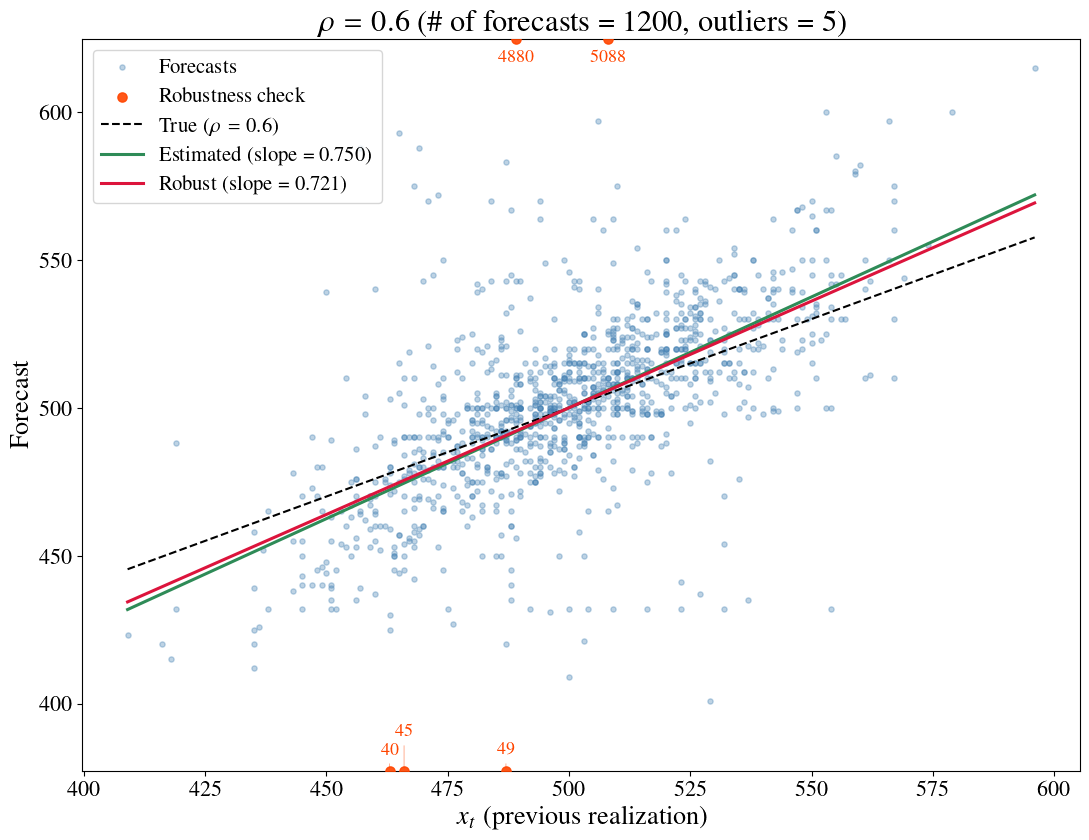

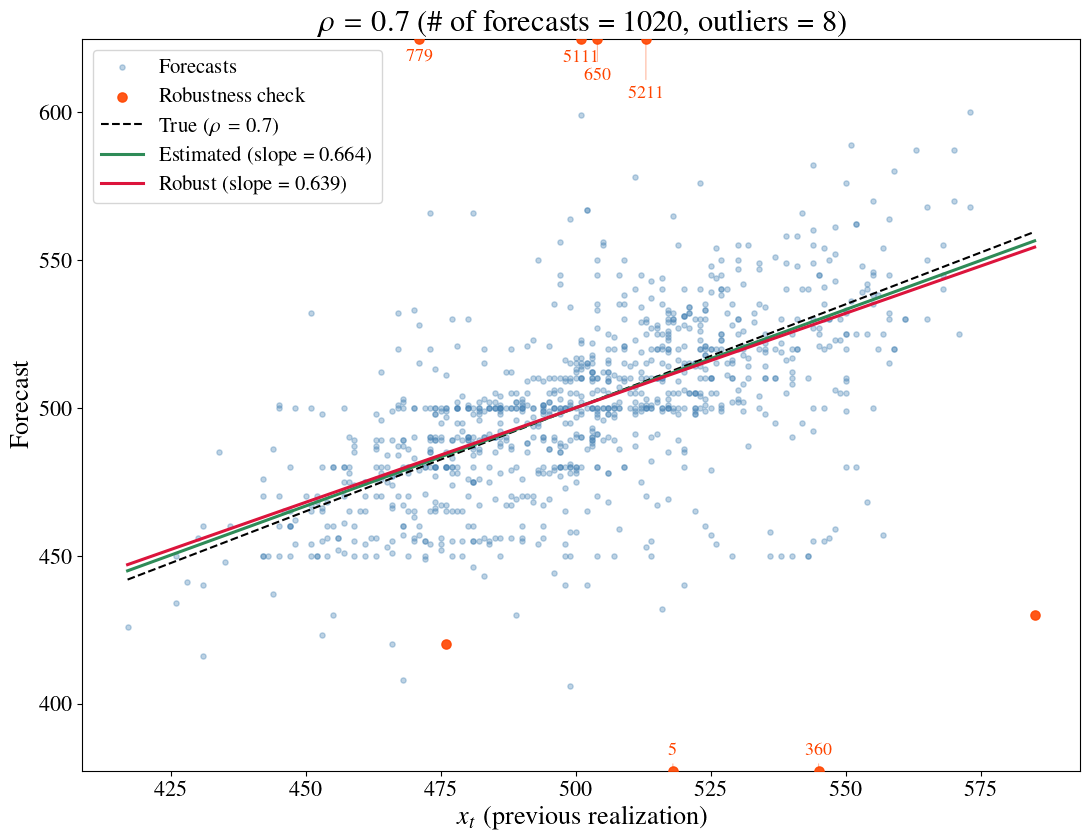

In [43]:
# A few forecasts are wild typos (e.g. 5211 instead of ~521) that would otherwise
# force the axis to span thousands of points and crush the real scatter into an
# unreadable sliver. Clip the view to the bulk of the data and mark anything
# outside it at the border with an arrow to its real value, so every point is
# still represented on the plot without destroying readability for the rest.
import matplotlib

_usetex_original = matplotlib.rcParams["text.usetex"]
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{newtxtext}\usepackage{newtxmath}"
matplotlib.rcParams["font.family"] = "serif"

VIEW_PAD = 60
view_lo = analysis_df_robust_input["x_t"].quantile(0.01) - VIEW_PAD
view_hi = analysis_df_robust_input["x_t"].quantile(0.99) + VIEW_PAD

OUTLIER_LABEL_FILENAMES = {
    0.6: "forecast_vs_realization_rho06.png",
    0.7: "forecast_vs_realization_rho07.png",
}


def stagger_offsets(xs, min_sep):
    """Vertical stagger level (0, 1, 2, ...) for labels whose x-positions are
    within min_sep of the previous one in sorted order, so pinned outliers
    that cluster together get pushed progressively further out instead of
    printing on top of each other."""
    order = np.argsort(xs)
    levels = np.zeros(len(xs), dtype=int)
    last_x = None
    stack = 0
    for idx in order:
        x = xs[idx]
        if last_x is not None and (x - last_x) < min_sep:
            stack += 1
        else:
            stack = 0
        levels[idx] = stack
        last_x = x
    return levels


for rho in [0.6, 0.7]:
    g = analysis_df_robust_input[
        analysis_df_robust_input["rho_group"] == rho
    ].dropna(subset=["x_t", "forecast_value"]).copy()

    normal_points = g[~g["is_outlier_forecast"]]
    outlier_points = g[g["is_outlier_forecast"]]

    fig, ax = plt.subplots(figsize=(11, 8.5))

    ax.scatter(
        normal_points["x_t"], normal_points["forecast_value"],
        s=14, alpha=0.35, color="steelblue", label="Forecasts"
    )

    # Outliers within the clipped view plot normally; those outside it are
    # pinned to the border with an arrow annotating their real value. Pinned
    # labels are staggered so nearby ones don't overlap.
    pinned = outlier_points.assign(
        y_clipped=lambda d: d["forecast_value"].clip(view_lo, view_hi)
    )
    pinned_lo = pinned[(pinned["forecast_value"] != pinned["y_clipped"]) & (pinned["y_clipped"] == view_lo)]
    pinned_hi = pinned[(pinned["forecast_value"] != pinned["y_clipped"]) & (pinned["y_clipped"] == view_hi)]
    min_sep = (view_hi - view_lo) * 0.04

    ax.scatter(
        outlier_points["x_t"],
        outlier_points["forecast_value"].clip(view_lo, view_hi),
        s=44, alpha=0.9, color="orangered", zorder=5,
        label="Robustness check",
    )

    for pinned_group, base_offset, direction in (
        (pinned_lo, 12, 1),
        (pinned_hi, -16, -1),
    ):
        if pinned_group.empty:
            continue
        xs = pinned_group["x_t"].to_numpy()
        levels = stagger_offsets(xs, min_sep)
        y_clip = view_lo if direction == 1 else view_hi
        for (_, row), level in zip(pinned_group.iterrows(), levels):
            ax.annotate(
                f"{row['forecast_value']:.0f}",
                xy=(row["x_t"], y_clip),
                xytext=(0, base_offset + direction * level * 13),
                textcoords="offset points",
                ha="center",
                fontsize=13,
                color="orangered",
                arrowprops=dict(arrowstyle="-", color="orangered", alpha=0.5, lw=0.6),
            )

    x_range = np.linspace(g["x_t"].min(), g["x_t"].max(), 100)

    # True: the nominal rho for this condition.
    true_y = AR_MEAN + rho * (x_range - AR_MEAN)
    ax.plot(x_range, true_y, linestyle="--", color="black", linewidth=1.5, label=f"True ($\\rho = {rho}$)")

    # Estimated: OLS over every point shown, outliers included.
    est_slope = estimate_slope_from_centered_ols(g, y_col="forecast_value", x_col="x_t", mean_value=AR_MEAN)
    ax.plot(
        x_range, AR_MEAN + est_slope * (x_range - AR_MEAN),
        color="seagreen", linewidth=2.2, label=f"Estimated (slope = {est_slope:.3f})"
    )

    # Robust estimated: OLS with flagged outliers excluded.
    robust_slope = estimate_slope_from_centered_ols(normal_points, y_col="forecast_value", x_col="x_t", mean_value=AR_MEAN)
    ax.plot(
        x_range, AR_MEAN + robust_slope * (x_range - AR_MEAN),
        color="crimson", linewidth=2.2, label=f"Robust (slope = {robust_slope:.3f})"
    )

    ax.set_ylim(view_lo, view_hi)
    ax.set_title(
        f"$\\rho = {rho}$ (\\# of forecasts = {len(g)}, outliers = {len(outlier_points)})",
        fontsize=22,
    )
    ax.set_xlabel(r"$x_t$ (previous realization)", fontsize=19)
    ax.set_ylabel(r"Forecast", fontsize=19)
    ax.tick_params(labelsize=16)
    ax.legend(fontsize=15, loc="upper left")

    plt.tight_layout()
    plt.savefig(OUT_DIR / OUTLIER_LABEL_FILENAMES[rho], dpi=150, bbox_inches="tight")
    plt.show()

matplotlib.rcParams["text.usetex"] = _usetex_original

## Reinstatement bias by within-train position (p_t)

`gamma_0`/`gamma_1` summarize the x_match effect with a single intercept-and-linear-decay model (`x_match_c` and `p_t * x_match_c`). That's a strong functional-form assumption -- if the real shape is, say, a cliff at p_t = 1 rather than a smooth decline, a linear fit could easily average out to a non-significant gamma_1 even if a real, sharp effect exists. This checks that assumption directly: at each within-train position, pool every trial across participants (within a rho condition) and estimate the `x_match_c` coefficient on its own, with no assumption about how it evolves across positions. The linear model's own fitted line (`gamma_0 + gamma_1 * p_t`, using the robust-sample, lag_spec=2 estimates) is overlaid for comparison.

Uses the robust sample (`reg_df_trial_robust`, outliers removed + MAE<=30 excluded) -- the same data `gamma_0`/`gamma_1` were estimated on.

In [44]:
MIN_OBS_PER_BIN = 20

profile_rows = []
for rho in [0.6, 0.7]:
    for p_t_value in sorted(reg_df_trial_robust["p_t"].dropna().unique()):
        g = reg_df_trial_robust[
            (reg_df_trial_robust["rho_group"] == rho) & (reg_df_trial_robust["p_t"] == p_t_value)
        ].dropna(subset=["forecast_c", "x_t_c", "x_t_minus_1_c", "x_match_c"])

        if len(g) < MIN_OBS_PER_BIN or g["x_match_c"].nunique() < 2:
            continue

        res = smf.ols("forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c", data=g).fit(
            cov_type="cluster", cov_kwds={"groups": g[participant_col]}
        )

        coef = res.params["x_match_c"]
        ci_lo, ci_hi = res.conf_int().loc["x_match_c"]

        profile_rows.append({
            "rho_group": rho,
            "p_t": int(p_t_value),
            "coef": coef,
            "ci_lo": ci_lo,
            "ci_hi": ci_hi,
            "n_obs": len(g),
            "n_participants": g[participant_col].nunique(),
        })

position_profile = pd.DataFrame(profile_rows)
position_profile

,rho_group,p_t,coef,ci_lo,ci_hi,n_obs,n_participants
0,0.6,0,0.060662,-0.099095,0.220419,220,17
1,0.6,1,0.152148,0.081906,0.222389,223,17
2,0.6,2,0.139567,0.000747,0.278386,231,17
3,0.6,3,-0.031444,-0.164115,0.101228,168,17
4,0.6,4,0.072923,-0.084717,0.230562,114,17
5,0.6,5,0.102463,-0.262532,0.467459,59,17
6,0.7,0,0.071580,-0.079512,0.222673,182,14
7,0.7,1,-0.002532,-0.089204,0.084140,182,14
8,0.7,2,0.075558,-0.080290,0.231406,185,14
9,0.7,3,0.051213,-0.069190,0.171617,140,14


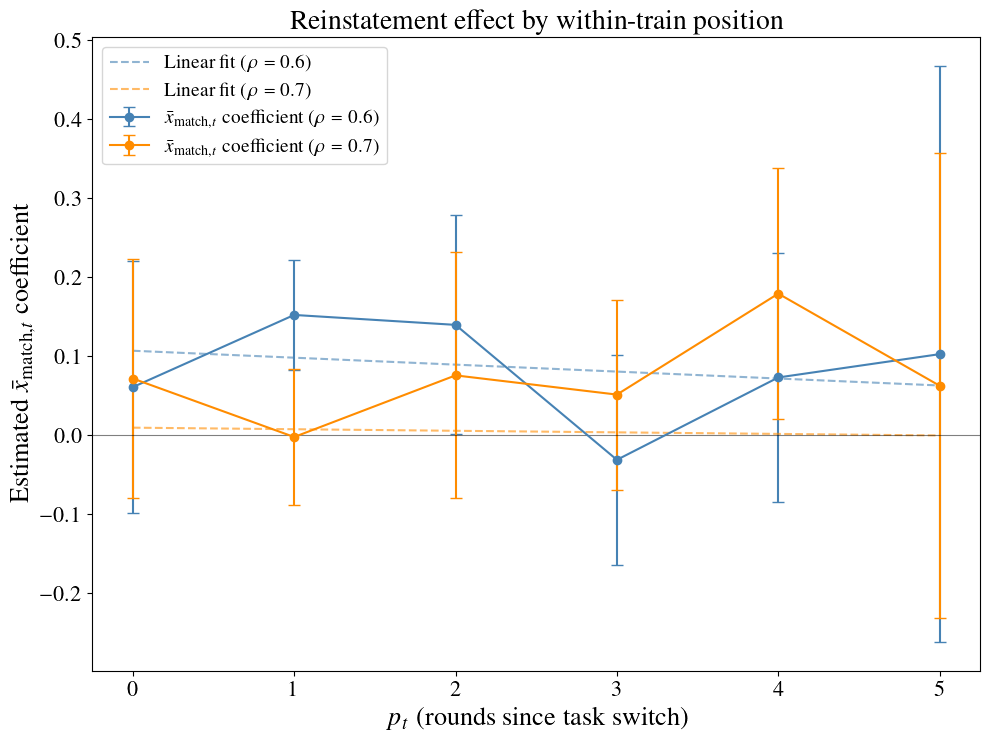

In [45]:
import matplotlib

_usetex_original = matplotlib.rcParams["text.usetex"]
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{newtxtext}\usepackage{newtxmath}"
matplotlib.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(figsize=(10, 7.5))

colors = {0.6: "steelblue", 0.7: "darkorange"}

for rho in [0.6, 0.7]:
    g = position_profile[position_profile["rho_group"] == rho].sort_values("p_t")
    if g.empty:
        continue

    yerr = np.vstack([g["coef"] - g["ci_lo"], g["ci_hi"] - g["coef"]])
    ax.errorbar(
        g["p_t"], g["coef"], yerr=yerr,
        marker="o", capsize=4, linewidth=1.5, color=colors[rho],
        label=fr"$\bar{{x}}_{{\mathrm{{match}},t}}$ coefficient ($\rho = {rho}$)"
    )

    # Overlay the linear model's own fit (gamma_0 + gamma_1 * p_t), lag_spec = 2,
    # from the same robust sample, for comparison against the unconstrained profile.
    row = interaction_gamma_tests_trial_robust[
        (interaction_gamma_tests_trial_robust["assigned_rho"].round(1) == rho)
        & (interaction_gamma_tests_trial_robust["lag_spec"] == 2)
    ]
    if not row.empty:
        gamma_0 = row.iloc[0]["mean_gamma_0"]
        gamma_1 = row.iloc[0]["mean_gamma_1"]
        p_t_range = np.linspace(g["p_t"].min(), g["p_t"].max(), 50)
        ax.plot(
            p_t_range, gamma_0 + gamma_1 * p_t_range,
            linestyle="--", linewidth=1.5, color=colors[rho], alpha=0.6,
            label=fr"Linear fit ($\rho = {rho}$)"
        )

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel(r"$p_t$ (rounds since task switch)", fontsize=19)
ax.set_ylabel(r"Estimated $\bar{x}_{\mathrm{match},t}$ coefficient", fontsize=19)
ax.set_title("Reinstatement effect by within-train position", fontsize=20)
ax.tick_params(labelsize=16)
ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig(OUT_DIR / "reinstatement_bias_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

matplotlib.rcParams["text.usetex"] = _usetex_original

## gamma_0 per train, binned (switch-point trials only)

Rather than one `gamma_0` estimate per *participant*, this takes every individual train's switch trial (`p_t = 0`) as its own observation -- one point per train, pooled across participants within a rho condition, from the outlier-excluded robust sample (`reg_df_trial_robust`, same cleaning as the robustness check and the position-profile plot). Each switch trial's forecast is first residualized against the recency controls (`x_t_c`, `x_t_minus_1_c`); by Frisch-Waugh-Lovell, the OLS slope of that residual on `x_match_c` equals `gamma_0` restricted to switch trials, since the interaction term `p_t * x_match_c` is exactly zero at `p_t = 0`. The raw per-train residuals are noisy (small `x_match_c` values dominate the scatter), so points are grouped into equal-count bins of `x_match_c` for readability; the black line is the `gamma_0` slope fit to the underlying (unbinned) per-train data, not to the bin averages.

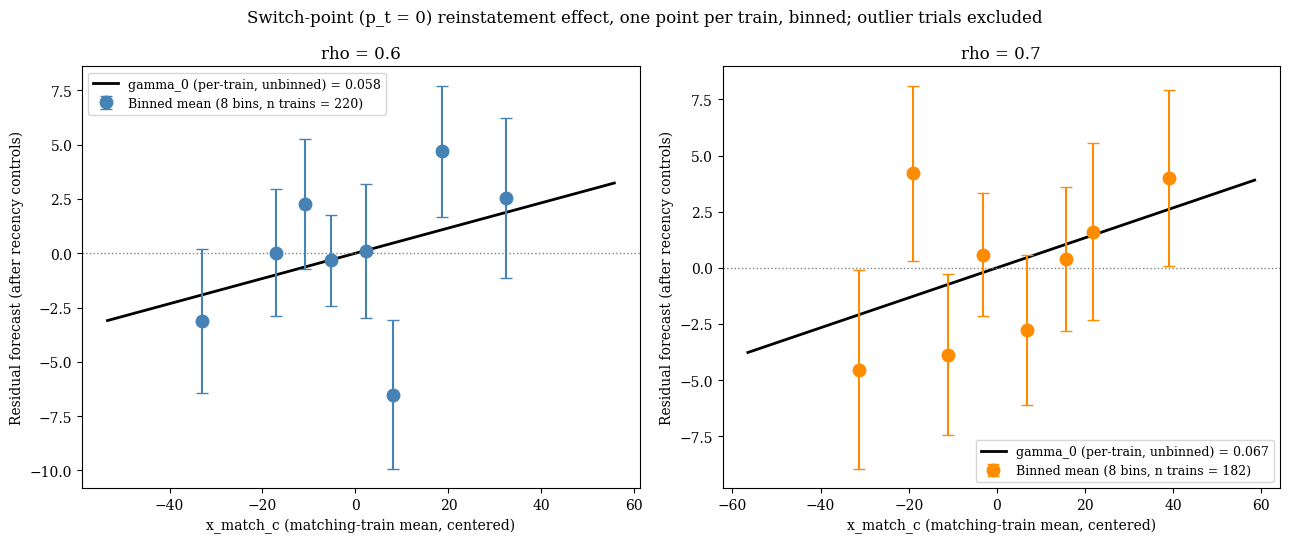

In [46]:
switch_trials = reg_df_trial_robust[
    reg_df_trial_robust["p_t"] == 0
].dropna(subset=["forecast_c", "x_t_c", "x_t_minus_1_c", "x_match_c"])

N_BINS = 8

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = {0.6: "steelblue", 0.7: "darkorange"}

for ax, rho in zip(axes, [0.6, 0.7]):
    g = switch_trials[switch_trials["rho_group"] == rho].copy()

    # Partial out recency (x_t_c, x_t_minus_1_c) so the remaining residual isolates
    # the x_match_c relationship: by Frisch-Waugh-Lovell, the OLS slope of this
    # residual on x_match_c equals gamma_0 from the full interaction model,
    # restricted to these same switch trials (p_t = 0, where the interaction term
    # is exactly zero).
    control_fit = smf.ols("forecast_c ~ x_t_c + x_t_minus_1_c", data=g).fit()
    g["residual"] = control_fit.resid

    n_bins = min(N_BINS, g["x_match_c"].nunique())
    g["bin"] = pd.qcut(g["x_match_c"], q=n_bins, duplicates="drop")
    binned = g.groupby("bin", observed=True).agg(
        x_match_c_mean=("x_match_c", "mean"),
        residual_mean=("residual", "mean"),
        residual_sem=("residual", "sem"),
        n=("residual", "size"),
    ).dropna()

    slope_fit = smf.ols("residual ~ x_match_c", data=g).fit()
    gamma0_slope = slope_fit.params["x_match_c"]

    ax.errorbar(
        binned["x_match_c_mean"], binned["residual_mean"], yerr=binned["residual_sem"],
        fmt="o", markersize=9, capsize=4, color=colors[rho], ecolor=colors[rho],
        linewidth=1.5, label=f"Binned mean ({len(binned)} bins, n trains = {len(g)})",
        zorder=3,
    )

    x_range = np.linspace(g["x_match_c"].min(), g["x_match_c"].max(), 100)
    ax.plot(
        x_range, gamma0_slope * x_range, color="black", linewidth=2,
        label=f"gamma_0 (per-train, unbinned) = {gamma0_slope:.3f}", zorder=2,
    )
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"rho = {rho}")
    ax.set_xlabel("x_match_c (matching-train mean, centered)")
    ax.set_ylabel("Residual forecast (after recency controls)")
    ax.legend(fontsize=9)

plt.suptitle("Switch-point (p_t = 0) reinstatement effect, one point per train, binned; outlier trials excluded")
plt.tight_layout()
plt.savefig(OUT_DIR / "gamma0_binned_by_train.png", dpi=150)
plt.show()

## Per-participant MAE distribution, before vs. after outlier-trial removal

Histograms of per-participant mean absolute forecast error (MAE), before
(`analysis_df_robust_input`, the as-is sample) and after (`analysis_df_no_outlier_trials`,
outlier trials removed only -- no participant-level MAE filter) outlier-trial removal. A
dashed reference line is drawn at MAE = 35.

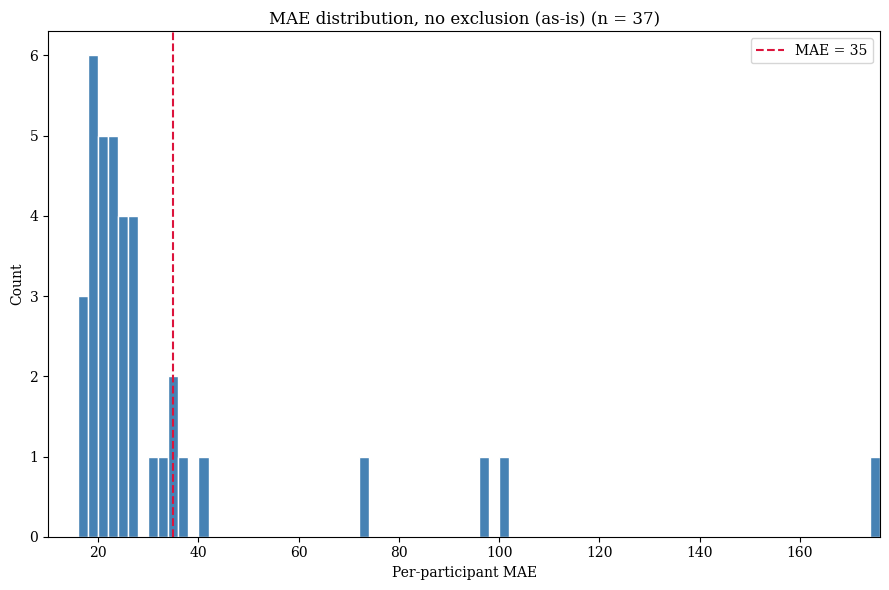

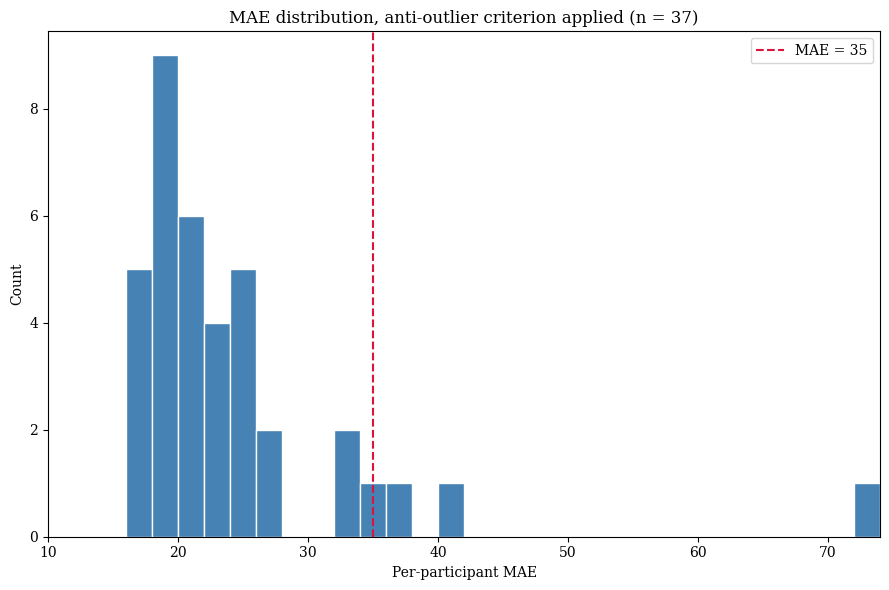

In [47]:
MAE_BIN_WIDTH = 2
MAE_X_MIN = 10
MAE_REFERENCE_LINE = 35

def per_participant_mae(data):
    return (
        data
        .dropna(subset=[participant_col, "forecast_error"])
        .groupby(participant_col)["forecast_error"]
        .apply(lambda s: s.abs().mean())
    )

mae_before = per_participant_mae(analysis_df_robust_input)
mae_after = per_participant_mae(analysis_df_no_outlier_trials)

def plot_mae_hist(mae_values, title, filename):
    upper = max(45, int(np.ceil(mae_values.max() / MAE_BIN_WIDTH)) * MAE_BIN_WIDTH)
    bins = np.arange(MAE_X_MIN, upper + MAE_BIN_WIDTH, MAE_BIN_WIDTH)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.hist(mae_values, bins=bins, color="steelblue", edgecolor="white")
    ax.axvline(MAE_REFERENCE_LINE, color="crimson", linestyle="--", linewidth=1.5,
               label=f"MAE = {MAE_REFERENCE_LINE}")
    ax.set_xlim(MAE_X_MIN, upper)
    ax.set_xlabel("Per-participant MAE")
    ax.set_ylabel("Count")
    ax.set_title(f"{title} (n = {len(mae_values)})")
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=150)
    plt.show()

plot_mae_hist(mae_before, "MAE distribution, no exclusion (as-is)", "mae_hist_no_exclusion.png")
plot_mae_hist(mae_after, "MAE distribution, anti-outlier criterion applied", "mae_hist_no_outliers.png")

## A data-driven alternative to the fixed MAE cutoff: per-participant modified z-score

The `MEAN_ABS_ERROR_MAX = 30` participant-level exclusion is a fixed, hand-picked number.
As an alternative, apply the same robust outlier-detection logic already used to flag
individual bad *trials* (median + MAD-based modified z-score, Iglewicz & Hoya) one level up,
to the distribution of per-participant MAE itself. This self-calibrates to whatever the
pilot sample actually looks like, rather than asserting a round number a priori.

Only the *high* side is flagged here (unlike the trial-level check, which is two-sided):
an anomalously *low* MAE is a good participant, not a data-quality problem, so there is no
symmetric concern to guard against.

Sample median MAE: 21.52, MAD: 3.00
MAD-implied cutoff (z > 3.5): MAE > 37.08
Fixed cutoff currently used in the paper: MAE > 30

Flagged by MAD-based rule:   ['<redacted>b80c5bf6', '<redacted>a05faf27']
Flagged by fixed MAE > 30: ['<redacted>b80c5bf6', '<redacted>a05faf27', '<redacted>a203af95', '<redacted>6bb0c00d', '<redacted>c16b635a', '<redacted>20a00304']

Participants where the two rules disagree (4):
                                        mae     mae_z  flagged_mad  \
db_uniqueid                                                          
<redacted>a203af95  33.067797  2.597079        False   
<redacted>20a00304  33.466667  2.686758        False   
<redacted>c16b635a  35.416667  3.125183        False   
<redacted>6bb0c00d  37.050000  3.492411        False   

                                  flagged_fixed_30  
db_uniqueid                                         
<redacted>a203af95              True  
<redacted>20a00304              True  
<redacted>c16b635a              True  


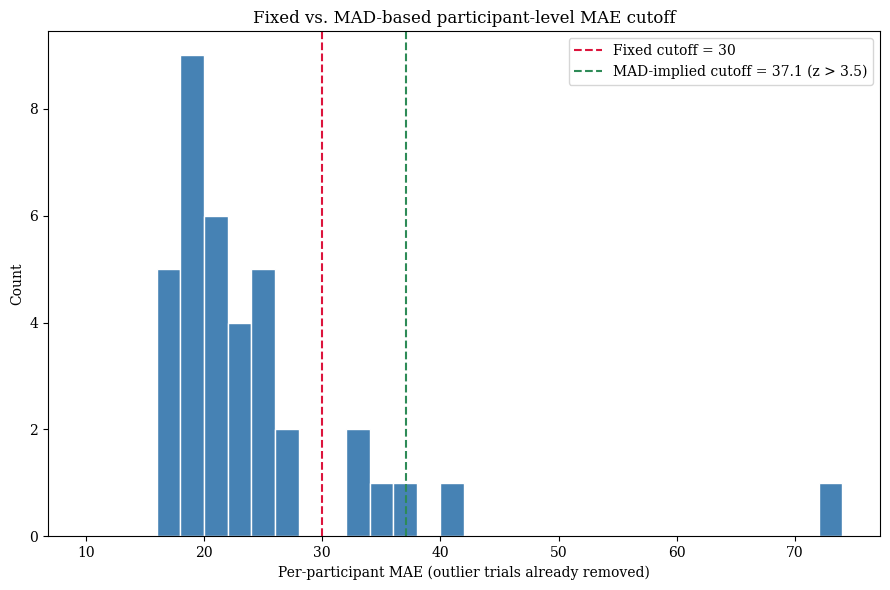

In [48]:
PARTICIPANT_MAE_Z_THRESHOLD = 3.5

mae_by_participant = (
    analysis_df_no_outlier_trials
    .dropna(subset=[participant_col, "forecast_error"])
    .groupby(participant_col)["forecast_error"]
    .apply(lambda s: s.abs().mean())
    .rename("mae")
    .to_frame()
)

_median = mae_by_participant["mae"].median()
_mad = (mae_by_participant["mae"] - _median).abs().median()
mae_by_participant["mae_z"] = 0.6745 * (mae_by_participant["mae"] - _median) / _mad
mae_by_participant["flagged_mad"] = mae_by_participant["mae_z"] > PARTICIPANT_MAE_Z_THRESHOLD
mae_by_participant["flagged_fixed_30"] = mae_by_participant["mae"] > MEAN_ABS_ERROR_MAX

# The MAE value at which the z-score would cross the threshold -- the
# "equivalent cutoff" implied by the data-driven rule, for comparison to 30.
implied_cutoff = _median + (PARTICIPANT_MAE_Z_THRESHOLD / 0.6745) * _mad

print(f"Sample median MAE: {_median:.2f}, MAD: {_mad:.2f}")
print(f"MAD-implied cutoff (z > {PARTICIPANT_MAE_Z_THRESHOLD}): MAE > {implied_cutoff:.2f}")
print(f"Fixed cutoff currently used in the paper: MAE > {MEAN_ABS_ERROR_MAX}")
print()
print(f"Flagged by MAD-based rule:   {sorted(mae_by_participant.index[mae_by_participant['flagged_mad']].tolist())}")
print(f"Flagged by fixed MAE > {MEAN_ABS_ERROR_MAX}: {sorted(mae_by_participant.index[mae_by_participant['flagged_fixed_30']].tolist())}")
print()
disagreements = mae_by_participant[mae_by_participant["flagged_mad"] != mae_by_participant["flagged_fixed_30"]]
print(f"Participants where the two rules disagree ({len(disagreements)}):")
print(disagreements[["mae", "mae_z", "flagged_mad", "flagged_fixed_30"]].sort_values("mae"))

fig, ax = plt.subplots(figsize=(9, 6))
bins = np.arange(10, int(np.ceil(mae_by_participant["mae"].max() / 2)) * 2 + 2, 2)
ax.hist(mae_by_participant["mae"], bins=bins, color="steelblue", edgecolor="white")
ax.axvline(MEAN_ABS_ERROR_MAX, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Fixed cutoff = {MEAN_ABS_ERROR_MAX}")
ax.axvline(implied_cutoff, color="seagreen", linestyle="--", linewidth=1.5,
           label=f"MAD-implied cutoff = {implied_cutoff:.1f} (z > {PARTICIPANT_MAE_Z_THRESHOLD})")
ax.set_xlabel("Per-participant MAE (outlier trials already removed)")
ax.set_ylabel("Count")
ax.set_title("Fixed vs. MAD-based participant-level MAE cutoff")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "mae_cutoff_fixed_vs_mad.png", dpi=150)
plt.show()

## Spec 4: no outliers, MAE <= 37.1 (MAD-derived cutoff)

Same as Spec 3 ("no outliers, MAE <= 30") except the participant-level accuracy filter uses
the MAD-based cutoff (37.1) derived above instead of the fixed 30, computed on the same
outlier-trial-removed sample (`analysis_df_no_outlier_trials`). This re-runs the full
pipeline -- baseline overreaction, post-switch gamma, reinstatement gamma_0/gamma_1, and the
persistence-condition comparison -- exactly as for Spec 3, just with the different accuracy
threshold.

In [49]:
MEAN_ABS_ERROR_MAX_V2 = 37.1

excluded_inaccurate_participants_trial_v2 = set(
    mae_by_participant.index[mae_by_participant["mae"] > MEAN_ABS_ERROR_MAX_V2]
)

print(f"Participants excluded for MAE (non-outlier trials) > {MEAN_ABS_ERROR_MAX_V2}: "
      f"{len(excluded_inaccurate_participants_trial_v2)}")

analysis_df_trial_robust_v2 = analysis_df_no_outlier_trials[
    ~analysis_df_no_outlier_trials[participant_col].isin(excluded_inaccurate_participants_trial_v2)
].copy()

print(f"Participants remaining in Spec 4: {analysis_df_trial_robust_v2[participant_col].nunique()}")

participant_persistence_trial_robust_v2 = compute_participant_persistence(
    analysis_df_trial_robust_v2,
    participant_col,
    require_exact_trial_count=False,
)
persistence_tests_trial_robust_v2 = test_baseline_overreaction(participant_persistence_trial_robust_v2)

reg_df_trial_robust_v2 = prepare_regression_df(analysis_df_trial_robust_v2)

simple_gamma_postswitch_2_trial_robust_v2 = participant_level_simple_gamma_postswitch(
    reg_df_trial_robust_v2, lag_spec=2, post_switch_positions=POST_SWITCH_POSITIONS
)
simple_gamma_postswitch_3_trial_robust_v2 = participant_level_simple_gamma_postswitch(
    reg_df_trial_robust_v2, lag_spec=3, post_switch_positions=POST_SWITCH_POSITIONS
)
simple_gammas_postswitch_trial_robust_v2 = pd.concat(
    [simple_gamma_postswitch_2_trial_robust_v2, simple_gamma_postswitch_3_trial_robust_v2],
    ignore_index=True
)
simple_gamma_postswitch_tests_trial_robust_v2 = test_postswitch_gamma_greater_than_zero(
    simple_gammas_postswitch_trial_robust_v2
)
gamma_condition_postswitch_tests_trial_robust_v2 = test_gamma_condition_comparison(
    simple_gammas_postswitch_trial_robust_v2
)

interaction_gamma_2_trial_robust_v2 = participant_level_interaction_gammas(
    reg_df_trial_robust_v2, lag_spec=2, include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)
interaction_gamma_3_trial_robust_v2 = participant_level_interaction_gammas(
    reg_df_trial_robust_v2, lag_spec=3, include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)
interaction_gammas_trial_robust_v2 = pd.concat(
    [interaction_gamma_2_trial_robust_v2, interaction_gamma_3_trial_robust_v2],
    ignore_index=True
)
interaction_gamma_tests_trial_robust_v2 = test_interaction_gammas(interaction_gammas_trial_robust_v2)

print("Spec 4 built.")

Participants excluded for MAE (non-outlier trials) > 37.1: 2
Participants remaining in Spec 4: 35


Spec 4 built.


## Four-specification summary (lag_spec = 2 and lag_spec = 3)

Same as the three-specification summary above, with a 4th column added: Spec 4, "no
outliers, MAE <= 37.1" (the MAD-derived cutoff), alongside the original Spec 3, "no
outliers, MAE <= 30" (fixed cutoff), for direct comparison.

In [50]:
def summary_row_4(metric, rho, spec1, spec2, spec3, spec4, value_col, p_col, fmt="{:.3f}"):
    def fmt_cell(df):
        row = df[df["assigned_rho"].round(1) == rho]
        if row.empty:
            return "--"
        r = row.iloc[0]
        stars = add_stars(r[p_col])
        return f"{fmt.format(r[value_col])} (p={r[p_col]:.4f}{stars})"

    return {
        "metric": metric,
        "rho": rho,
        "1. As-is": fmt_cell(spec1),
        "2. No outliers": fmt_cell(spec2),
        "3. No outliers, MAE<=30": fmt_cell(spec3),
        "4. No outliers, MAE<=37.1": fmt_cell(spec4),
    }


def n_row_4(spec1, spec2, spec3, spec4):
    def n_for(df, rho):
        row = df[df["assigned_rho"].round(1) == rho]
        return int(row.iloc[0]["n_participants"]) if not row.empty else 0

    return {
        "metric": "n_participants",
        "rho": "0.6 / 0.7",
        "1. As-is": f'{n_for(spec1, 0.6)} / {n_for(spec1, 0.7)}',
        "2. No outliers": f'{n_for(spec2, 0.6)} / {n_for(spec2, 0.7)}',
        "3. No outliers, MAE<=30": f'{n_for(spec3, 0.6)} / {n_for(spec3, 0.7)}',
        "4. No outliers, MAE<=37.1": f'{n_for(spec4, 0.6)} / {n_for(spec4, 0.7)}',
    }


def build_4spec_summary(lag_filter):
    rows = [
        n_row_4(persistence_tests, persistence_tests_no_outliers, persistence_tests_trial_robust, persistence_tests_trial_robust_v2),
    ]

    for rho in [0.6, 0.7]:
        rows.append(summary_row_4(
            "baseline overreaction: mean rho_excess",
            rho,
            persistence_tests, persistence_tests_no_outliers, persistence_tests_trial_robust, persistence_tests_trial_robust_v2,
            "mean_rho_excess", "p_value_implied_rho_greater_than_true_rho",
        ))

    for rho in [0.6, 0.7]:
        rows.append(summary_row_4(
            "post-switch gamma (x_match effect)",
            rho,
            lag_filter(simple_gamma_postswitch_tests), lag_filter(simple_gamma_postswitch_tests_no_outliers),
            lag_filter(simple_gamma_postswitch_tests_trial_robust), lag_filter(simple_gamma_postswitch_tests_trial_robust_v2),
            "mean_gamma", "p_value_gamma_greater_than_0",
        ))

    for rho in [0.6, 0.7]:
        rows.append(summary_row_4(
            "reinstatement decay: gamma_0",
            rho,
            lag_filter(interaction_gamma_tests), lag_filter(interaction_gamma_tests_no_outliers),
            lag_filter(interaction_gamma_tests_trial_robust), lag_filter(interaction_gamma_tests_trial_robust_v2),
            "mean_gamma_0", "p_value_gamma_0_greater_than_0",
        ))

    for rho in [0.6, 0.7]:
        rows.append(summary_row_4(
            "reinstatement decay: gamma_1 (decay of gamma_0 over p_t)",
            rho,
            lag_filter(interaction_gamma_tests), lag_filter(interaction_gamma_tests_no_outliers),
            lag_filter(interaction_gamma_tests_trial_robust), lag_filter(interaction_gamma_tests_trial_robust_v2),
            "mean_gamma_1", "p_value_gamma_1_less_than_0",
        ))

    def diff_cell(df):
        r = lag_filter(df).iloc[0]
        return f'{r["difference_07_minus_06"]:.3f} (p={r["p_value_rho_07_greater_than_rho_06"]:.4f}{add_stars(r["p_value_rho_07_greater_than_rho_06"])})'

    rows.append({
        "metric": "gamma comparison: rho 0.7 - rho 0.6",
        "rho": "--",
        "1. As-is": diff_cell(gamma_condition_postswitch_tests),
        "2. No outliers": diff_cell(gamma_condition_postswitch_tests_no_outliers),
        "3. No outliers, MAE<=30": diff_cell(gamma_condition_postswitch_tests_trial_robust),
        "4. No outliers, MAE<=37.1": diff_cell(gamma_condition_postswitch_tests_trial_robust_v2),
    })

    return pd.DataFrame(rows)


summary_table_4spec = build_4spec_summary(lag2)
summary_table_4spec_lag3 = build_4spec_summary(lag3)

display(Markdown("## Four-specification summary (lag_spec = 2)"))
display(summary_table_4spec)

display(Markdown("## Four-specification summary (lag_spec = 3)"))
display(summary_table_4spec_lag3)

## Four-specification summary (lag_spec = 2)

,metric,rho,1. As-is,2. No outliers,"3. No outliers, MAE<=30","4. No outliers, MAE<=37.1"
0,n_participants,0.6 / 0.7,20 / 17,20 / 17,17 / 14,19 / 16
1,baseline overreaction: mean rho_excess,0.6,0.116 (p=0.1247),0.099 (p=0.0783*),0.199 (p=0.0003***),0.123 (p=0.0401**)
2,baseline overreaction: mean rho_excess,0.7,-0.016 (p=0.5504),-0.087 (p=0.9585),-0.039 (p=0.8526),-0.063 (p=0.9178)
3,post-switch gamma (x_match effect),0.6,0.153 (p=0.0812*),0.085 (p=0.1664),0.106 (p=0.0033***),0.152 (p=0.0080***)
4,post-switch gamma (x_match effect),0.7,0.691 (p=0.1605),0.080 (p=0.1078),-0.007 (p=0.5662),0.070 (p=0.1501)
5,reinstatement decay: gamma_0,0.6,0.132 (p=0.1719),0.046 (p=0.3486),0.107 (p=0.0259**),0.149 (p=0.0121**)
6,reinstatement decay: gamma_0,0.7,0.569 (p=0.1601),0.090 (p=0.0830*),0.009 (p=0.4309),0.075 (p=0.1303)
7,reinstatement decay: gamma_1 (decay of gamma_0...,0.6,0.330 (p=0.9170),-0.006 (p=0.3960),-0.009 (p=0.3452),-0.018 (p=0.2148)
8,reinstatement decay: gamma_1 (decay of gamma_0...,0.7,-0.049 (p=0.2468),-0.008 (p=0.3425),-0.002 (p=0.4638),-0.003 (p=0.4307)
9,gamma comparison: rho 0.7 - rho 0.6,--,0.538 (p=0.2208),-0.005 (p=0.5188),-0.113 (p=0.9764),-0.082 (p=0.8230)


## Four-specification summary (lag_spec = 3)

,metric,rho,1. As-is,2. No outliers,"3. No outliers, MAE<=30","4. No outliers, MAE<=37.1"
0,n_participants,0.6 / 0.7,20 / 17,20 / 17,17 / 14,19 / 16
1,baseline overreaction: mean rho_excess,0.6,0.116 (p=0.1247),0.099 (p=0.0783*),0.199 (p=0.0003***),0.123 (p=0.0401**)
2,baseline overreaction: mean rho_excess,0.7,-0.016 (p=0.5504),-0.087 (p=0.9585),-0.039 (p=0.8526),-0.063 (p=0.9178)
3,post-switch gamma (x_match effect),0.6,0.180 (p=0.0606*),0.089 (p=0.1319),0.115 (p=0.0023***),0.151 (p=0.0035***)
4,post-switch gamma (x_match effect),0.7,0.707 (p=0.1580),0.076 (p=0.1086),-0.006 (p=0.5636),0.065 (p=0.1546)
5,reinstatement decay: gamma_0,0.6,0.151 (p=0.1445),0.054 (p=0.3237),0.108 (p=0.0231**),0.153 (p=0.0113**)
6,reinstatement decay: gamma_0,0.7,0.631 (p=0.1613),0.086 (p=0.0802*),0.009 (p=0.4321),0.068 (p=0.1338)
7,reinstatement decay: gamma_1 (decay of gamma_0...,0.6,0.325 (p=0.9147),-0.011 (p=0.3165),-0.008 (p=0.3514),-0.018 (p=0.2094)
8,reinstatement decay: gamma_1 (decay of gamma_0...,0.7,-0.082 (p=0.2172),-0.004 (p=0.4081),-0.000 (p=0.4936),0.001 (p=0.5155)
9,gamma comparison: rho 0.7 - rho 0.6,--,0.526 (p=0.2287),-0.013 (p=0.5532),-0.121 (p=0.9860),-0.086 (p=0.8550)


## Non-parametric companions to the t-tests (as-is sample)

The main analyses use one-sample $t$-tests (baseline overreaction, post-switch $\gamma$,
reinstatement $\gamma_0$/$\gamma_1$) and a two-sample Welch $t$-test (persistence
interaction) on participant-level estimates. With only 14-20 participants per cell, a
handful of noisy individual-level estimates could in principle drive a $p$-value on their
own. As a same-sample robustness check (distinct from the outlier/MAE sample cleaning in
the Robustness Check section), each test here is paired with a distribution-free
alternative computed on the identical participant-level estimates: a Wilcoxon signed-rank
test in place of each one-sample $t$-test, and a permutation test (10,000 resamples) in
place of the Welch test. Agreement between the parametric and non-parametric result
indicates the $t$-test's $p$-value is not an artifact of a few extreme individual
estimates.

In [51]:
from scipy.stats import wilcoxon, permutation_test

def wilcoxon_one_sample(values, alternative):
    values = pd.Series(values).dropna()
    values = values[values != 0]
    if len(values) < 2:
        return np.nan, np.nan
    res = wilcoxon(values, alternative=alternative)
    return res.statistic, res.pvalue


def test_baseline_overreaction_wilcoxon(participant_persistence_df):
    rows = []
    for rho_value, g in participant_persistence_df.groupby("assigned_rho"):
        stat, p = wilcoxon_one_sample(g["rho_excess"], alternative="greater")
        rows.append({"assigned_rho": rho_value, "n_participants": g["rho_excess"].dropna().shape[0],
                      "wilcoxon_stat": stat, "p_value_wilcoxon": p})
    return pd.DataFrame(rows)


def test_postswitch_gamma_wilcoxon(simple_gammas_postswitch):
    rows = []
    for (rho_value, lag_spec), g in simple_gammas_postswitch.groupby(["assigned_rho", "lag_spec"]):
        stat, p = wilcoxon_one_sample(g["gamma"], alternative="greater")
        rows.append({"assigned_rho": rho_value, "lag_spec": lag_spec,
                      "n_participants": g["gamma"].dropna().shape[0],
                      "wilcoxon_stat": stat, "p_value_wilcoxon": p})
    return pd.DataFrame(rows)


def test_interaction_gammas_wilcoxon(interaction_gammas):
    rows = []
    for (rho_value, lag_spec), g in interaction_gammas.groupby(["assigned_rho", "lag_spec"]):
        stat0, p0 = wilcoxon_one_sample(g["gamma_0"], alternative="greater")
        stat1, p1 = wilcoxon_one_sample(g["gamma_1"], alternative="less")
        rows.append({
            "assigned_rho": rho_value, "lag_spec": lag_spec,
            "wilcoxon_stat_gamma_0": stat0, "p_value_wilcoxon_gamma_0": p0,
            "wilcoxon_stat_gamma_1": stat1, "p_value_wilcoxon_gamma_1": p1,
        })
    return pd.DataFrame(rows)


def test_gamma_condition_comparison_permutation(simple_gammas_postswitch, n_resamples=10000, random_state=0):
    def stat_fn(x, y):
        return np.mean(x) - np.mean(y)

    rows = []
    for lag_spec, g in simple_gammas_postswitch.groupby("lag_spec"):
        gamma_06 = g[g["assigned_rho"].round(1) == 0.6]["gamma"].dropna().to_numpy()
        gamma_07 = g[g["assigned_rho"].round(1) == 0.7]["gamma"].dropna().to_numpy()

        res = permutation_test(
            (gamma_07, gamma_06), statistic=stat_fn, permutation_type="independent",
            alternative="greater", n_resamples=n_resamples, random_state=random_state,
        )
        rows.append({
            "lag_spec": lag_spec, "n_rho_06": len(gamma_06), "n_rho_07": len(gamma_07),
            "observed_difference": res.statistic, "p_value_permutation": res.pvalue,
        })
    return pd.DataFrame(rows)


baseline_wilcoxon = test_baseline_overreaction_wilcoxon(participant_persistence)
postswitch_wilcoxon = test_postswitch_gamma_wilcoxon(simple_gammas_postswitch)
interaction_wilcoxon = test_interaction_gammas_wilcoxon(interaction_gammas)
persistence_interaction_permutation = test_gamma_condition_comparison_permutation(simple_gammas_postswitch)

print("Baseline overreaction: t-test vs Wilcoxon")
print(persistence_tests[["assigned_rho", "mean_rho_excess", "p_value_implied_rho_greater_than_true_rho"]]
      .merge(baseline_wilcoxon[["assigned_rho", "p_value_wilcoxon"]], on="assigned_rho")
      .rename(columns={"p_value_implied_rho_greater_than_true_rho": "p_value_ttest"})
      .to_string(index=False))
print()

print("Post-switch gamma: t-test vs Wilcoxon")
print(simple_gamma_postswitch_tests[["assigned_rho", "lag_spec", "mean_gamma", "p_value_gamma_greater_than_0"]]
      .merge(postswitch_wilcoxon[["assigned_rho", "lag_spec", "p_value_wilcoxon"]], on=["assigned_rho", "lag_spec"])
      .rename(columns={"p_value_gamma_greater_than_0": "p_value_ttest"})
      .sort_values(["lag_spec", "assigned_rho"]).to_string(index=False))
print()

print("Reinstatement gamma_0 / gamma_1: t-test vs Wilcoxon")
print(interaction_gamma_tests[["assigned_rho", "lag_spec", "mean_gamma_0", "p_value_gamma_0_greater_than_0",
                                "mean_gamma_1", "p_value_gamma_1_less_than_0"]]
      .merge(interaction_wilcoxon, on=["assigned_rho", "lag_spec"])
      .rename(columns={"p_value_gamma_0_greater_than_0": "p_ttest_gamma_0",
                        "p_value_gamma_1_less_than_0": "p_ttest_gamma_1"})
      .sort_values(["lag_spec", "assigned_rho"])
      [["assigned_rho", "lag_spec", "mean_gamma_0", "p_ttest_gamma_0", "p_value_wilcoxon_gamma_0",
        "mean_gamma_1", "p_ttest_gamma_1", "p_value_wilcoxon_gamma_1"]]
      .to_string(index=False))
print()

print("Persistence interaction: Welch t-test vs permutation test")
print(gamma_condition_postswitch_tests[["lag_spec", "difference_07_minus_06", "p_value_rho_07_greater_than_rho_06"]]
      .merge(persistence_interaction_permutation[["lag_spec", "p_value_permutation"]], on="lag_spec")
      .rename(columns={"p_value_rho_07_greater_than_rho_06": "p_value_welch"})
      .to_string(index=False))

Baseline overreaction: t-test vs Wilcoxon
 assigned_rho  mean_rho_excess  p_value_ttest  p_value_wilcoxon
          0.6         0.115653       0.124674          0.108084
          0.7        -0.016361       0.550429          0.974731

Post-switch gamma: t-test vs Wilcoxon
 assigned_rho  lag_spec  mean_gamma  p_value_ttest  p_value_wilcoxon
          0.6         2    0.152901       0.081173          0.002790
          0.7         2    0.691350       0.160523          0.176437
          0.6         3    0.180490       0.060615          0.001827
          0.7         3    0.706683       0.158009          0.188911

Reinstatement gamma_0 / gamma_1: t-test vs Wilcoxon
 assigned_rho  lag_spec  mean_gamma_0  p_ttest_gamma_0  p_value_wilcoxon_gamma_0  mean_gamma_1  p_ttest_gamma_1  p_value_wilcoxon_gamma_1
          0.6         2      0.131984         0.171933                  0.101225      0.329667         0.916995                  0.844103
          0.7         2      0.569287         0.16009

## Non-parametric companions, extended to the robustness-cleaned samples

Same idea, applied to the two cleaned specifications used in the Robustness Check
(Table~\ref{tab:robustness}/\ref{tab:robustness_lag3}): \textit{no outliers} (outlier
trials removed) and \textit{no outliers, MAE $\le 30$} (additionally excluding
low-accuracy participants). This checks whether the robustness-check conclusions
themselves depend on the parametric $t$-test, or hold up under a distribution-free
alternative on the same cleaned samples.

In [52]:
def build_comparison(persistence_tests_df, simple_gamma_tests_df, interaction_gamma_tests_df,
                      gamma_condition_tests_df, participant_persistence_df, simple_gammas_df,
                      interaction_gammas_df, spec_name):
    baseline_np = test_baseline_overreaction_wilcoxon(participant_persistence_df)
    postswitch_np = test_postswitch_gamma_wilcoxon(simple_gammas_df)
    interaction_np = test_interaction_gammas_wilcoxon(interaction_gammas_df)
    persistence_np = test_gamma_condition_comparison_permutation(simple_gammas_df)

    print(f"=== {spec_name} ===")

    print("Baseline overreaction: t-test vs Wilcoxon")
    print(persistence_tests_df[["assigned_rho", "mean_rho_excess", "p_value_implied_rho_greater_than_true_rho"]]
          .merge(baseline_np[["assigned_rho", "p_value_wilcoxon"]], on="assigned_rho")
          .rename(columns={"p_value_implied_rho_greater_than_true_rho": "p_value_ttest"})
          .to_string(index=False))
    print()

    print("Post-switch gamma: t-test vs Wilcoxon")
    print(simple_gamma_tests_df[["assigned_rho", "lag_spec", "mean_gamma", "p_value_gamma_greater_than_0"]]
          .merge(postswitch_np[["assigned_rho", "lag_spec", "p_value_wilcoxon"]], on=["assigned_rho", "lag_spec"])
          .rename(columns={"p_value_gamma_greater_than_0": "p_value_ttest"})
          .sort_values(["lag_spec", "assigned_rho"]).to_string(index=False))
    print()

    print("Reinstatement gamma_0 / gamma_1: t-test vs Wilcoxon")
    print(interaction_gamma_tests_df[["assigned_rho", "lag_spec", "mean_gamma_0", "p_value_gamma_0_greater_than_0",
                                       "mean_gamma_1", "p_value_gamma_1_less_than_0"]]
          .merge(interaction_np, on=["assigned_rho", "lag_spec"])
          .rename(columns={"p_value_gamma_0_greater_than_0": "p_ttest_gamma_0",
                            "p_value_gamma_1_less_than_0": "p_ttest_gamma_1"})
          .sort_values(["lag_spec", "assigned_rho"])
          [["assigned_rho", "lag_spec", "mean_gamma_0", "p_ttest_gamma_0", "p_value_wilcoxon_gamma_0",
            "mean_gamma_1", "p_ttest_gamma_1", "p_value_wilcoxon_gamma_1"]]
          .to_string(index=False))
    print()

    print("Persistence interaction: Welch t-test vs permutation test")
    print(gamma_condition_tests_df[["lag_spec", "difference_07_minus_06", "p_value_rho_07_greater_than_rho_06"]]
          .merge(persistence_np[["lag_spec", "p_value_permutation"]], on="lag_spec")
          .rename(columns={"p_value_rho_07_greater_than_rho_06": "p_value_welch"})
          .to_string(index=False))
    print()


build_comparison(
    persistence_tests_no_outliers, simple_gamma_postswitch_tests_no_outliers,
    interaction_gamma_tests_no_outliers, gamma_condition_postswitch_tests_no_outliers,
    participant_persistence_no_outliers, simple_gammas_postswitch_no_outliers,
    interaction_gammas_no_outliers, "No outliers"
)

build_comparison(
    persistence_tests_trial_robust, simple_gamma_postswitch_tests_trial_robust,
    interaction_gamma_tests_trial_robust, gamma_condition_postswitch_tests_trial_robust,
    participant_persistence_trial_robust, simple_gammas_postswitch_trial_robust,
    interaction_gammas_trial_robust, "No outliers, MAE <= 30"
)

=== No outliers ===
Baseline overreaction: t-test vs Wilcoxon
 assigned_rho  mean_rho_excess  p_value_ttest  p_value_wilcoxon
          0.6         0.099425       0.078341          0.066363
          0.7        -0.087343       0.958483          0.955673

Post-switch gamma: t-test vs Wilcoxon
 assigned_rho  lag_spec  mean_gamma  p_value_ttest  p_value_wilcoxon
          0.6         2    0.085128       0.166419          0.006040
          0.7         2    0.080108       0.107771          0.188911
          0.6         3    0.089293       0.131861          0.006808
          0.7         3    0.076153       0.108622          0.201881

Reinstatement gamma_0 / gamma_1: t-test vs Wilcoxon
 assigned_rho  lag_spec  mean_gamma_0  p_ttest_gamma_0  p_value_wilcoxon_gamma_0  mean_gamma_1  p_ttest_gamma_1  p_value_wilcoxon_gamma_1
          0.6         2      0.046308         0.348607                  0.122744     -0.006292         0.395979                  0.662889
          0.7         2      0.08

=== No outliers, MAE <= 30 ===
Baseline overreaction: t-test vs Wilcoxon
 assigned_rho  mean_rho_excess  p_value_ttest  p_value_wilcoxon
          0.6         0.199228       0.000254          0.000534
          0.7        -0.038565       0.852578          0.903137

Post-switch gamma: t-test vs Wilcoxon
 assigned_rho  lag_spec  mean_gamma  p_value_ttest  p_value_wilcoxon
          0.6         2    0.106128       0.003254          0.001923
          0.7         2   -0.007238       0.566174          0.596130
          0.6         3    0.114724       0.002251          0.001923
          0.7         3   -0.006365       0.563623          0.642578

Reinstatement gamma_0 / gamma_1: t-test vs Wilcoxon
 assigned_rho  lag_spec  mean_gamma_0  p_ttest_gamma_0  p_value_wilcoxon_gamma_0  mean_gamma_1  p_ttest_gamma_1  p_value_wilcoxon_gamma_1
          0.6         2      0.106780         0.025874                  0.142082     -0.008805         0.345191                  0.644051
          0.7         

## Distribution of participant-level post-switch gamma (as-is sample, lag_spec = 2)

The Wilcoxon vs. $t$-test divergence for post-switch $\gamma$ at $\rho = 0.6$ ($t$-test
$p=.081$, Wilcoxon $p=.003$) should show up as visible non-normality in the underlying
37 participant-level estimates -- specifically, a right skew or a few extreme values
dragging the mean/SE around while barely moving the median/ranks.

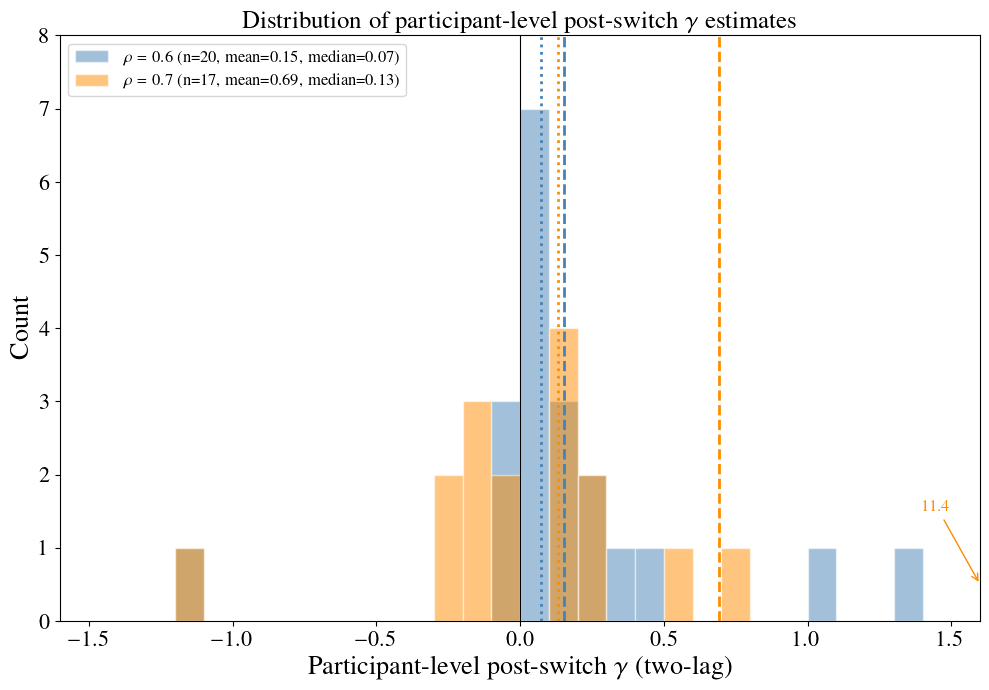

In [53]:
import matplotlib

_usetex_original = matplotlib.rcParams["text.usetex"]
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{newtxtext}\usepackage{newtxmath}"
matplotlib.rcParams["font.family"] = "serif"

g_lag2 = simple_gammas_postswitch[simple_gammas_postswitch["lag_spec"] == 2]

fig, ax = plt.subplots(figsize=(10, 7))
colors = {0.6: "steelblue", 0.7: "darkorange"}

VIEW_LO, VIEW_HI = -1.6, 1.6
bin_width = 0.1
bins = np.arange(VIEW_LO, VIEW_HI + bin_width, bin_width)

for rho in [0.6, 0.7]:
    vals = g_lag2[g_lag2["assigned_rho"].round(1) == rho]["gamma"].dropna()
    mean = vals.mean()
    median = vals.median()

    in_view = vals[(vals >= VIEW_LO) & (vals <= VIEW_HI)]
    out_of_view = vals[(vals < VIEW_LO) | (vals > VIEW_HI)]

    ax.hist(in_view, bins=bins, color=colors[rho], alpha=0.5, edgecolor="white",
            label=fr"$\rho = {rho}$ (n={len(vals)}, mean={mean:.2f}, median={median:.2f})")
    ax.axvline(median, color=colors[rho], linestyle=":", linewidth=2)
    # Mean is annotated with an arrow instead of a line when it falls outside the
    # clipped view, since a small number of extreme individual estimates can pull
    # the mean (but not the median) far off the readable range.
    if VIEW_LO <= mean <= VIEW_HI:
        ax.axvline(mean, color=colors[rho], linestyle="--", linewidth=2)
    else:
        edge = VIEW_HI if mean > VIEW_HI else VIEW_LO
        ax.annotate(
            f"mean = {mean:.2f}", xy=(edge, 6.5), xytext=(edge - (0.5 if mean > VIEW_HI else -0.5), 7.2),
            color=colors[rho], fontsize=12, ha="center",
            arrowprops=dict(arrowstyle="->", color=colors[rho]),
        )

    for v in out_of_view:
        edge = VIEW_HI if v > VIEW_HI else VIEW_LO
        ax.annotate(
            f"{v:.1f}", xy=(edge, 0.5), xytext=(edge - (0.15 if v > VIEW_HI else -0.15), 1.5),
            color=colors[rho], fontsize=12, ha="center",
            arrowprops=dict(arrowstyle="->", color=colors[rho]),
        )

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(VIEW_LO, VIEW_HI)
ax.set_ylim(0, 8)
ax.set_xlabel(r"Participant-level post-switch $\gamma$ (two-lag)", fontsize=19)
ax.set_ylabel(r"Count", fontsize=19)
ax.set_title("Distribution of participant-level post-switch $\gamma$ estimates", fontsize=18)
ax.tick_params(labelsize=16)
ax.legend(fontsize=12, loc="upper left")

plt.tight_layout()
plt.savefig(OUT_DIR / "postswitch_gamma_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

matplotlib.rcParams["text.usetex"] = _usetex_original

In [54]:
g_lag2 = simple_gammas_postswitch[simple_gammas_postswitch["lag_spec"] == 2]
outlier_row = g_lag2[(g_lag2["assigned_rho"].round(1) == 0.7) & (g_lag2["gamma"] > 5)]
print(outlier_row)
print()

pid = outlier_row["participant"].iloc[0]
print("Participant:", pid)
print()

sub = reg_df[
    (reg_df[participant_col] == pid) & (reg_df["p_t"].isin(POST_SWITCH_POSITIONS))
].dropna(subset=["forecast_c", "x_t_c", "x_t_minus_1_c", "x_match_c"])

print(f"n post-switch trials used in this participant's gamma regression: {len(sub)}")
print(f"x_match_c: mean={sub['x_match_c'].mean():.2f}, std={sub['x_match_c'].std():.2f}, "
      f"nunique={sub['x_match_c'].nunique()}")
print()
print(sub[["round_index", "task_type", "train_id", "p_t", "forecast_c", "x_t_c",
           "x_t_minus_1_c", "x_match_c"]].to_string(index=False))

                        participant  assigned_rho  lag_spec  \
8  <redacted>407ed1fe           0.7         2   

  post_switch_positions      gamma   gamma_se  n_obs  r_squared  \
8                [0, 1]  11.386789  10.960348     24   0.083961   

                                          formula  
8  forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c  

Participant: <redacted>407ed1fe

n post-switch trials used in this participant's gamma regression: 24
x_match_c: mean=0.45, std=18.80, nunique=12

 round_index task_type  train_id  p_t  forecast_c  x_t_c  x_t_minus_1_c  x_match_c
          21      size         4    0        10.0   15.0           31.0  32.000000
          22      size         4    1        17.0   32.0           15.0  32.000000
          26   animacy         5    0         9.0   -1.0           19.0  20.500000
          27   animacy         5    1      4711.0   13.0           -1.0  20.500000
          32      size         6    0       -10.0  -20.0          -33.0  11.200000
  

In [55]:
pid = "<redacted>407ed1fe"
check = analysis_df_robust_input[
    (analysis_df_robust_input[participant_col] == pid) & (analysis_df_robust_input["round_index"] == 27)
][[participant_col, "round_index", "forecast_value", "x_next_true", "forecast_error",
   "forecast_error_z", "is_outlier_forecast"]]
print(check.to_string(index=False))

print()
gamma_no_outliers_row = simple_gammas_postswitch_no_outliers[
    (simple_gammas_postswitch_no_outliers["participant"] == pid)
    & (simple_gammas_postswitch_no_outliers["lag_spec"] == 2)
]
print("Same participant's post-switch gamma after outlier-trial removal:")
print(gamma_no_outliers_row.to_string(index=False))

                     db_uniqueid  round_index  forecast_value  x_next_true  forecast_error  forecast_error_z  is_outlier_forecast
<redacted>407ed1fe           27          5211.0          477          4734.0        199.609844                 True

Same participant's post-switch gamma after outlier-trial removal:
                     participant  assigned_rho  lag_spec post_switch_positions    gamma  gamma_se  n_obs  r_squared                                        formula
<redacted>407ed1fe           0.7         2                [0, 1] 0.060883  0.173063     23   0.577309 forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c


## Mixed-effects reformulation (reviewer suggestion)

Replaces the two-stage "estimate per participant, then t-test on the estimates" pipeline
with a single mixed-effects model per analysis: $\gamma$ (and $\gamma_0$, $\gamma_1$, and
the persistence interaction) become fixed effects estimated jointly across all
participants and trials, with participant-level random effects (intercept + slope on
$\bar{x}_{\mathrm{match},t}$) absorbing the between-participant heterogeneity in how much
data (and how noisily) each person's own effect would otherwise be estimated. Inference on
each fixed effect uses the model's built-in Wald ($z$) test; one-sided $p$-values are
computed from the normal CDF to match the directional hypotheses tested elsewhere.

In [56]:
import statsmodels.formula.api as smf
import warnings

def one_sided_p(z, alternative):
    if alternative == "greater":
        return stats.norm.sf(z)
    else:
        return stats.norm.cdf(z)


def fit_mixed(formula, data, group_col, re_formula, label, fallback_to_intercept_only=True):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = smf.mixedlm(formula, data=data, groups=data[group_col], re_formula=re_formula)
        result = model.fit(reml=True, method="lbfgs", maxiter=200)

    if not result.converged and fallback_to_intercept_only:
        print(f"{label}: random-slope model did not converge; falling back to random-intercept-only")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = smf.mixedlm(formula, data=data, groups=data[group_col])
            result = model.fit(reml=True, method="lbfgs", maxiter=200)

    print(f"{label}  (n_trials={len(data)}, n_participants={data[group_col].nunique()}, "
          f"re_formula={'random intercept + slope' if result.model.k_re > 1 else 'random intercept only'}, "
          f"converged={result.converged})")
    return result


def report_fixed_effect(result, term, alternative, label):
    coef = result.fe_params[term]
    se = result.bse_fe[term]
    z = coef / se
    p = one_sided_p(z, alternative)
    print(f"  {label}: {term} = {coef:.4f} (SE={se:.4f}, z={z:.3f}, one-sided p={p:.4f})")
    return coef, se, z, p


POST_SWITCH_NEEDED = ["forecast_c", "x_t_c", "x_t_minus_1_c", "x_match_c", "rho_group"]
postswitch_data = reg_df[reg_df["p_t"].isin(POST_SWITCH_POSITIONS)].dropna(subset=POST_SWITCH_NEEDED).copy()
postswitch_data[participant_col] = postswitch_data[participant_col].astype(str)

print("=" * 70)
print("POST-SWITCH BIAS: mixed-effects version of Equation 1, by rho")
print("=" * 70)
postswitch_mixed_results = {}
for rho in [0.6, 0.7]:
    sub = postswitch_data[postswitch_data["rho_group"] == rho]
    res = fit_mixed(
        "forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c",
        sub, participant_col, "~x_match_c", f"rho = {rho}"
    )
    report_fixed_effect(res, "x_match_c", "greater", "gamma")
    postswitch_mixed_results[rho] = res
print()

print("=" * 70)
print("POST-SWITCH BIAS: joint model with rho as a fixed-effect moderator")
print("(the x_match_c:rho_indicator coefficient IS the persistence interaction)")
print("=" * 70)
combined_data = postswitch_data.copy()
combined_data["rho_indicator"] = (combined_data["rho_group"] == 0.7).astype(float)
res_combined = fit_mixed(
    "forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c * rho_indicator",
    combined_data, participant_col, "~x_match_c", "Combined (both rho)"
)
report_fixed_effect(res_combined, "x_match_c", "greater", "gamma (rho=0.6 baseline)")
report_fixed_effect(res_combined, "x_match_c:rho_indicator", "greater", "Delta gamma (persistence interaction)")
print()

print("=" * 70)
print("REINSTATEMENT DECAY: mixed-effects version of Equation 2, by rho")
print("=" * 70)
DECAY_NEEDED = ["forecast_c", "x_t_c", "x_t_minus_1_c", "x_match_c", "p_t_x_match_c", "rho_group"]
decay_data = reg_df.dropna(subset=DECAY_NEEDED).copy()
decay_data[participant_col] = decay_data[participant_col].astype(str)

decay_mixed_results = {}
for rho in [0.6, 0.7]:
    sub = decay_data[decay_data["rho_group"] == rho]
    res = fit_mixed(
        "forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c + p_t_x_match_c",
        sub, participant_col, "~x_match_c", f"rho = {rho}"
    )
    report_fixed_effect(res, "x_match_c", "greater", "gamma_0")
    report_fixed_effect(res, "p_t_x_match_c", "less", "gamma_1")
    decay_mixed_results[rho] = res

POST-SWITCH BIAS: mixed-effects version of Equation 1, by rho


rho = 0.6  (n_trials=524, n_participants=20, re_formula=random intercept + slope, converged=True)
  gamma: x_match_c = 0.0931 (SE=0.0837, z=1.113, one-sided p=0.1329)
rho = 0.7  (n_trials=446, n_participants=17, re_formula=random intercept + slope, converged=True)
  gamma: x_match_c = 0.6430 (SE=0.6449, z=0.997, one-sided p=0.1594)

POST-SWITCH BIAS: joint model with rho as a fixed-effect moderator
(the x_match_c:rho_indicator coefficient IS the persistence interaction)


Combined (both rho): random-slope model did not converge; falling back to random-intercept-only
Combined (both rho)  (n_trials=970, n_participants=37, re_formula=random intercept only, converged=True)
  gamma (rho=0.6 baseline): x_match_c = 0.0877 (SE=0.3448, z=0.254, one-sided p=0.3996)
  Delta gamma (persistence interaction): x_match_c:rho_indicator = 0.4660 (SE=0.4750, z=0.981, one-sided p=0.1633)

REINSTATEMENT DECAY: mixed-effects version of Equation 2, by rho
rho = 0.6: random-slope model did not converge; falling back to random-intercept-only
rho = 0.6  (n_trials=1200, n_participants=20, re_formula=random intercept only, converged=True)
  gamma_0: x_match_c = 0.1008 (SE=0.4524, z=0.223, one-sided p=0.4118)
  gamma_1: p_t_x_match_c = 0.3237 (SE=0.1958, z=1.653, one-sided p=0.9508)
rho = 0.7: random-slope model did not converge; falling back to random-intercept-only
rho = 0.7  (n_trials=1020, n_participants=17, re_formula=random intercept only, converged=True)
  gamma_0: x_match_c

## Mixed-effects, extended to the robustness-cleaned samples

Not yet run on the cleaned samples -- doing that now, using the same `fit_mixed` /
`report_fixed_effect` helpers defined above, applied to `reg_df_no_outliers` (outlier
trials removed) and `reg_df_trial_robust` (additionally excluding low-accuracy
participants), mirroring the two cleaning specifications in the Robustness Check.

In [57]:
def run_mixed_effects_suite(reg_df_subset, label):
    print("#" * 70)
    print(f"# {label}")
    print("#" * 70)

    ps_data = reg_df_subset[reg_df_subset["p_t"].isin(POST_SWITCH_POSITIONS)].dropna(subset=POST_SWITCH_NEEDED).copy()
    ps_data[participant_col] = ps_data[participant_col].astype(str)

    print("--- Post-switch bias, by rho ---")
    for rho in [0.6, 0.7]:
        sub = ps_data[ps_data["rho_group"] == rho]
        if sub[participant_col].nunique() < 5:
            print(f"rho = {rho}: too few participants ({sub[participant_col].nunique()}), skipping")
            continue
        res = fit_mixed("forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c", sub, participant_col,
                         "~x_match_c", f"rho = {rho}")
        report_fixed_effect(res, "x_match_c", "greater", "gamma")
    print()

    print("--- Persistence interaction (joint model) ---")
    combined = ps_data.copy()
    combined["rho_indicator"] = (combined["rho_group"] == 0.7).astype(float)
    res_combined = fit_mixed("forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c * rho_indicator",
                              combined, participant_col, "~x_match_c", "Combined (both rho)")
    report_fixed_effect(res_combined, "x_match_c", "greater", "gamma (rho=0.6 baseline)")
    report_fixed_effect(res_combined, "x_match_c:rho_indicator", "greater", "Delta gamma (persistence interaction)")
    print()

    print("--- Reinstatement decay, by rho ---")
    decay_data = reg_df_subset.dropna(subset=DECAY_NEEDED).copy()
    decay_data[participant_col] = decay_data[participant_col].astype(str)
    for rho in [0.6, 0.7]:
        sub = decay_data[decay_data["rho_group"] == rho]
        if sub[participant_col].nunique() < 5:
            print(f"rho = {rho}: too few participants ({sub[participant_col].nunique()}), skipping")
            continue
        res = fit_mixed("forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c + p_t_x_match_c", sub,
                         participant_col, "~x_match_c", f"rho = {rho}")
        report_fixed_effect(res, "x_match_c", "greater", "gamma_0")
        report_fixed_effect(res, "p_t_x_match_c", "less", "gamma_1")
    print()


run_mixed_effects_suite(reg_df_no_outliers, "No outliers (outlier trials removed)")
run_mixed_effects_suite(reg_df_trial_robust, "No outliers, MAE <= 30")

######################################################################
# No outliers (outlier trials removed)
######################################################################
--- Post-switch bias, by rho ---


rho = 0.6: random-slope model did not converge; falling back to random-intercept-only
rho = 0.6  (n_trials=523, n_participants=20, re_formula=random intercept only, converged=True)
  gamma: x_match_c = 0.0340 (SE=0.0640, z=0.532, one-sided p=0.2975)
rho = 0.7  (n_trials=441, n_participants=17, re_formula=random intercept + slope, converged=True)
  gamma: x_match_c = 0.0895 (SE=0.0617, z=1.449, one-sided p=0.0737)

--- Persistence interaction (joint model) ---


Combined (both rho): random-slope model did not converge; falling back to random-intercept-only
Combined (both rho)  (n_trials=964, n_participants=37, re_formula=random intercept only, converged=True)
  gamma (rho=0.6 baseline): x_match_c = 0.0336 (SE=0.0579, z=0.579, one-sided p=0.2813)
  Delta gamma (persistence interaction): x_match_c:rho_indicator = 0.0544 (SE=0.0797, z=0.682, one-sided p=0.2475)

--- Reinstatement decay, by rho ---


rho = 0.6: random-slope model did not converge; falling back to random-intercept-only
rho = 0.6  (n_trials=1195, n_participants=20, re_formula=random intercept only, converged=True)
  gamma_0: x_match_c = 0.0093 (SE=0.0717, z=0.130, one-sided p=0.4482)
  gamma_1: p_t_x_match_c = 0.0058 (SE=0.0310, z=0.187, one-sided p=0.5741)
rho = 0.7: random-slope model did not converge; falling back to random-intercept-only
rho = 0.7  (n_trials=1012, n_participants=17, re_formula=random intercept only, converged=True)
  gamma_0: x_match_c = 0.0849 (SE=0.0504, z=1.686, one-sided p=0.0459)
  gamma_1: p_t_x_match_c = 0.0085 (SE=0.0207, z=0.410, one-sided p=0.6593)

######################################################################
# No outliers, MAE <= 30
######################################################################
--- Post-switch bias, by rho ---


rho = 0.6: random-slope model did not converge; falling back to random-intercept-only
rho = 0.6  (n_trials=443, n_participants=17, re_formula=random intercept only, converged=True)
  gamma: x_match_c = 0.0961 (SE=0.0406, z=2.366, one-sided p=0.0090)


rho = 0.7: random-slope model did not converge; falling back to random-intercept-only
rho = 0.7  (n_trials=364, n_participants=14, re_formula=random intercept only, converged=True)
  gamma: x_match_c = 0.0089 (SE=0.0416, z=0.214, one-sided p=0.4153)

--- Persistence interaction (joint model) ---


Combined (both rho)  (n_trials=807, n_participants=31, re_formula=random intercept + slope, converged=True)
  gamma (rho=0.6 baseline): x_match_c = 0.1045 (SE=0.0445, z=2.349, one-sided p=0.0094)
  Delta gamma (persistence interaction): x_match_c:rho_indicator = -0.0901 (SE=0.0632, z=-1.425, one-sided p=0.9229)

--- Reinstatement decay, by rho ---


rho = 0.6: random-slope model did not converge; falling back to random-intercept-only
rho = 0.6  (n_trials=1015, n_participants=17, re_formula=random intercept only, converged=True)
  gamma_0: x_match_c = 0.1063 (SE=0.0451, z=2.355, one-sided p=0.0093)
  gamma_1: p_t_x_match_c = -0.0166 (SE=0.0194, z=-0.855, one-sided p=0.1962)
rho = 0.7: random-slope model did not converge; falling back to random-intercept-only
rho = 0.7  (n_trials=833, n_participants=14, re_formula=random intercept only, converged=True)
  gamma_0: x_match_c = 0.0044 (SE=0.0437, z=0.101, one-sided p=0.4599)
  gamma_1: p_t_x_match_c = 0.0186 (SE=0.0181, z=1.029, one-sided p=0.8482)



In [58]:
def two_sided_ci2(values, confidence=0.95):
    values = pd.Series(values).dropna()
    n = len(values)
    mean = values.mean()
    se = values.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - (1 - confidence) / 2, df=n - 1)
    return mean, mean - t_crit * se, mean + t_crit * se, n

def welch_ci2(x, y, confidence=0.95):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    nx, ny = len(x), len(y)
    varx, vary = x.var(ddof=1), y.var(ddof=1)
    diff = x.mean() - y.mean()
    se = np.sqrt(varx / nx + vary / ny)
    df = (varx / nx + vary / ny) ** 2 / (
        (varx / nx) ** 2 / (nx - 1) + (vary / ny) ** 2 / (ny - 1)
    )
    t_crit = stats.t.ppf(1 - (1 - confidence) / 2, df=df)
    return diff, diff - t_crit * se, diff + t_crit * se

specs = {
    "1_asis": {
        "persistence": participant_persistence,
        "postswitch2": simple_gamma_postswitch_2,
        "postswitch3": simple_gamma_postswitch_3,
        "interaction2": interaction_gamma_2,
        "interaction3": interaction_gamma_3,
    },
    "2_no_outliers": {
        "persistence": participant_persistence_no_outliers,
        "postswitch2": simple_gamma_postswitch_2_no_outliers,
        "postswitch3": simple_gamma_postswitch_3_no_outliers,
        "interaction2": interaction_gamma_2_no_outliers,
        "interaction3": interaction_gamma_3_no_outliers,
    },
    "3_robust": {
        "persistence": participant_persistence_trial_robust,
        "postswitch2": simple_gamma_postswitch_2_trial_robust,
        "postswitch3": simple_gamma_postswitch_3_trial_robust,
        "interaction2": interaction_gamma_2_trial_robust,
        "interaction3": interaction_gamma_3_trial_robust,
    },
}

for spec_name, d in specs.items():
    print("=" * 70)
    print(spec_name)
    print("=" * 70)

    print("-- baseline overreaction (rho_excess) --")
    for rho in [0.6, 0.7]:
        vals = d["persistence"][d["persistence"]["assigned_rho"].round(1) == rho]["rho_excess"]
        mean, lo, hi, n = two_sided_ci2(vals)
        print(f"  rho={rho}: mean={mean:.4f} CI=[{lo:.4f},{hi:.4f}] n={n}")

    for lagname, lagcol in [("postswitch2", "gamma"), ("postswitch3", "gamma")]:
        print(f"-- post-switch gamma, {lagname} --")
        for rho in [0.6, 0.7]:
            vals = d[lagname][d[lagname]["assigned_rho"].round(1) == rho][lagcol]
            mean, lo, hi, n = two_sided_ci2(vals)
            print(f"  rho={rho}: mean={mean:.4f} CI=[{lo:.4f},{hi:.4f}] n={n}")

    for lagname in ["interaction2", "interaction3"]:
        print(f"-- gamma_0 / gamma_1, {lagname} --")
        for rho in [0.6, 0.7]:
            vals0 = d[lagname][d[lagname]["assigned_rho"].round(1) == rho]["gamma_0"]
            vals1 = d[lagname][d[lagname]["assigned_rho"].round(1) == rho]["gamma_1"]
            m0, l0, h0, n0 = two_sided_ci2(vals0)
            m1, l1, h1, n1 = two_sided_ci2(vals1)
            print(f"  rho={rho}: gamma0 mean={m0:.4f} CI=[{l0:.4f},{h0:.4f}] n={n0} | "
                  f"gamma1 mean={m1:.4f} CI=[{l1:.4f},{h1:.4f}] n={n1}")

    for lagname in ["postswitch2", "postswitch3"]:
        print(f"-- persistence interaction (Welch), {lagname} --")
        g06 = d[lagname][d[lagname]["assigned_rho"].round(1) == 0.6]["gamma"]
        g07 = d[lagname][d[lagname]["assigned_rho"].round(1) == 0.7]["gamma"]
        diff, lo, hi = welch_ci2(g07, g06)
        print(f"  diff(0.7-0.6)={diff:.4f} CI=[{lo:.4f},{hi:.4f}]")
    print()

1_asis
-- baseline overreaction (rho_excess) --
  rho=0.6: mean=0.1157 CI=[-0.0880,0.3194] n=20
  rho=0.7: mean=-0.0164 CI=[-0.2857,0.2530] n=17
-- post-switch gamma, postswitch2 --
  rho=0.6: mean=0.1529 CI=[-0.0672,0.3730] n=20
  rho=0.7: mean=0.6913 CI=[-0.7398,2.1225] n=17
-- post-switch gamma, postswitch3 --
  rho=0.6: mean=0.1805 CI=[-0.0524,0.4134] n=20
  rho=0.7: mean=0.7067 CI=[-0.7406,2.1540] n=17
-- gamma_0 / gamma_1, interaction2 --
  rho=0.6: gamma0 mean=0.1320 CI=[-0.1526,0.4166] n=20 | gamma1 mean=0.3297 CI=[-0.1493,0.8087] n=20
  rho=0.7: gamma0 mean=0.5693 CI=[-0.6071,1.7456] n=17 | gamma1 mean=-0.0489 CI=[-0.1970,0.0991] n=17
-- gamma_0 / gamma_1, interaction3 --
  rho=0.6: gamma0 mean=0.1509 CI=[-0.1387,0.4404] n=20 | gamma1 mean=0.3252 CI=[-0.1528,0.8033] n=20
  rho=0.7: gamma0 mean=0.6309 CI=[-0.6793,1.9412] n=17 | gamma1 mean=-0.0816 CI=[-0.2974,0.1342] n=17
-- persistence interaction (Welch), postswitch2 --
  diff(0.7-0.6)=0.5384 CI=[-0.9046,1.9815]
-- persistenc

In [59]:
def collect_all_interaction_coefs(reg_df, lag_spec, include_pt_main_effect=False):
    if lag_spec == 2:
        needed = ["forecast_c", "x_t_c", "x_t_minus_1_c", "x_match_c", "p_t", "p_t_x_match_c"]
        predictors = ["x_t_c", "x_t_minus_1_c"]
    elif lag_spec == 3:
        needed = ["forecast_c", "x_t_c", "x_t_minus_1_c", "x_t_minus_2_c", "x_match_c", "p_t", "p_t_x_match_c"]
        predictors = ["x_t_c", "x_t_minus_1_c", "x_t_minus_2_c"]
    else:
        raise ValueError("lag_spec must be 2 or 3.")

    if include_pt_main_effect:
        predictors = predictors + ["p_t"]
    predictors = predictors + ["x_match_c", "p_t_x_match_c"]
    formula = "forecast_c ~ " + " + ".join(predictors)

    rows = []
    for participant_id, g in reg_df.dropna(subset=needed).groupby(participant_col):
        g = g.copy()
        if REQUIRE_COMPLETE_FORECASTS and len(g) < 40:
            continue
        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue
        rho_value = rho_values[0]
        if len(g) < len(predictors) + 3:
            continue
        if g["x_match_c"].nunique() < 2:
            continue
        if g["p_t_x_match_c"].nunique() < 2:
            continue
        try:
            res = smf.ols(formula, data=g).fit()
            row = {"participant": participant_id, "assigned_rho": rho_value, "lag_spec": lag_spec}
            for name in res.params.index:
                row[name] = res.params[name]
            rows.append(row)
        except Exception as e:
            print(f"Could not estimate full coefs for participant {participant_id}, lag_spec={lag_spec}: {e}")
    return pd.DataFrame(rows)


def summarize_all_coefs(coef_df, coef_names, spec_label):
    print("=" * 70)
    print(spec_label)
    print("=" * 70)
    for rho in [0.6, 0.7]:
        sub = coef_df[coef_df["assigned_rho"].round(1) == rho]
        print(f"-- rho = {rho} (n = {len(sub)}) --")
        for name in coef_names:
            vals = sub[name].dropna()
            mean, lo, hi, n = two_sided_ci2(vals)
            t_test = stats.ttest_1samp(vals, popmean=0, alternative="two-sided")
            print(f"  {name:16s}: mean={mean:.4f} CI=[{lo:.4f},{hi:.4f}] p={t_test.pvalue:.4f} n={n}")
    print()


coef_names_lag2 = ["Intercept", "x_t_c", "x_t_minus_1_c", "x_match_c", "p_t_x_match_c"]

all_coefs_asis_lag2 = collect_all_interaction_coefs(reg_df, lag_spec=2)
all_coefs_robust_lag2 = collect_all_interaction_coefs(reg_df_trial_robust, lag_spec=2)

summarize_all_coefs(all_coefs_asis_lag2, coef_names_lag2, "As-is (two-lag): all coefficients")
summarize_all_coefs(all_coefs_robust_lag2, coef_names_lag2, "Robust (two-lag): all coefficients")


As-is (two-lag): all coefficients
-- rho = 0.6 (n = 20) --
  Intercept       : mean=5.4569 CI=[-0.4743,11.3881] p=0.0692 n=20
  x_t_c           : mean=0.9747 CI=[0.3057,1.6437] p=0.0066 n=20
  x_t_minus_1_c   : mean=-0.2212 CI=[-0.9112,0.4688] p=0.5102 n=20
  x_match_c       : mean=0.1320 CI=[-0.1526,0.4166] p=0.3439 n=20
  p_t_x_match_c   : mean=0.3297 CI=[-0.1493,0.8087] p=0.1660 n=20
-- rho = 0.7 (n = 17) --
  Intercept       : mean=7.5237 CI=[-12.4187,27.4661] p=0.4355 n=17
  x_t_c           : mean=0.8192 CI=[0.3097,1.3287] p=0.0036 n=17
  x_t_minus_1_c   : mean=-0.1559 CI=[-0.4337,0.1218] p=0.2514 n=17
  x_match_c       : mean=0.5693 CI=[-0.6071,1.7456] p=0.3202 n=17
  p_t_x_match_c   : mean=-0.0489 CI=[-0.1970,0.0991] p=0.4936 n=17

Robust (two-lag): all coefficients
-- rho = 0.6 (n = 17) --
  Intercept       : mean=0.9828 CI=[-1.1774,3.1430] p=0.3492 n=17
  x_t_c           : mean=0.8268 CI=[0.6968,0.9567] p=0.0000 n=17
  x_t_minus_1_c   : mean=-0.0384 CI=[-0.1504,0.0735] p=0.477

In [60]:
def collect_all_postswitch_coefs(reg_df, lag_spec, post_switch_positions=[0, 1]):
    if lag_spec == 2:
        needed = ["forecast_c", "x_t_c", "x_t_minus_1_c", "x_match_c", "p_t"]
        formula = "forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c"
    elif lag_spec == 3:
        needed = ["forecast_c", "x_t_c", "x_t_minus_1_c", "x_t_minus_2_c", "x_match_c", "p_t"]
        formula = "forecast_c ~ x_t_c + x_t_minus_1_c + x_t_minus_2_c + x_match_c"
    else:
        raise ValueError("lag_spec must be 2 or 3.")

    rows = []
    temp = reg_df.copy()
    temp = temp[temp["p_t"].isin(post_switch_positions)].copy()
    temp = temp.dropna(subset=needed).copy()

    for participant_id, g in temp.groupby(participant_col):
        g = g.copy()
        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue
        rho_value = rho_values[0]
        if len(g) < 8:
            continue
        if g["x_match_c"].nunique() < 2:
            continue
        try:
            res = smf.ols(formula, data=g).fit()
            row = {"participant": participant_id, "assigned_rho": rho_value, "lag_spec": lag_spec}
            for name in res.params.index:
                row[name] = res.params[name]
            rows.append(row)
        except Exception as e:
            print(f"Could not estimate full coefs for participant {participant_id}, lag_spec={lag_spec}: {e}")
    return pd.DataFrame(rows)


coef_names_postswitch_lag2 = ["Intercept", "x_t_c", "x_t_minus_1_c", "x_match_c"]

all_coefs_postswitch_asis_lag2 = collect_all_postswitch_coefs(
    reg_df, lag_spec=2, post_switch_positions=POST_SWITCH_POSITIONS
)
all_coefs_postswitch_robust_lag2 = collect_all_postswitch_coefs(
    reg_df_trial_robust, lag_spec=2, post_switch_positions=POST_SWITCH_POSITIONS
)

summarize_all_coefs(all_coefs_postswitch_asis_lag2, coef_names_postswitch_lag2, "As-is (two-lag), post-switch only: all coefficients")
summarize_all_coefs(all_coefs_postswitch_robust_lag2, coef_names_postswitch_lag2, "Robust (two-lag), post-switch only: all coefficients")


As-is (two-lag), post-switch only: all coefficients
-- rho = 0.6 (n = 20) --
  Intercept       : mean=2.3783 CI=[-1.0689,5.8256] p=0.1650 n=20
  x_t_c           : mean=0.7722 CI=[0.5454,0.9989] p=0.0000 n=20
  x_t_minus_1_c   : mean=-0.1513 CI=[-0.3705,0.0680] p=0.1651 n=20
  x_match_c       : mean=0.1529 CI=[-0.0672,0.3730] p=0.1623 n=20
-- rho = 0.7 (n = 17) --
  Intercept       : mean=11.0137 CI=[-16.6349,38.6622] p=0.4109 n=17
  x_t_c           : mean=0.9753 CI=[0.0161,1.9346] p=0.0467 n=17
  x_t_minus_1_c   : mean=-0.3182 CI=[-1.0384,0.4021] p=0.3629 n=17
  x_match_c       : mean=0.6913 CI=[-0.7398,2.1225] p=0.3210 n=17

Robust (two-lag), post-switch only: all coefficients
-- rho = 0.6 (n = 17) --
  Intercept       : mean=1.5350 CI=[-1.1695,4.2396] p=0.2464 n=17
  x_t_c           : mean=0.8409 CI=[0.6831,0.9988] p=0.0000 n=17
  x_t_minus_1_c   : mean=-0.0821 CI=[-0.2096,0.0454] p=0.1910 n=17
  x_match_c       : mean=0.1061 CI=[0.0342,0.1781] p=0.0065 n=17
-- rho = 0.7 (n = 14) --
